<span style="color:steelblue; text-align: left">

## Predição de Churn de Clientes
</span>

- Cientista de Dados: Enio Rubens

<span style="color:steelblue; text-align: left">

## O que é Churn?
</span>


Churn refere-se à perda de clientes ao longo de um determinado período e representa uma métrica crítica para negócios baseados em assinaturas e serviços. Em termos práticos, um evento de churn ocorre quando um cliente para de adquirir um produto, cancela um serviço ou deixa de interagir com uma plataforma.

A definição de churn varia de acordo com o modelo de negócio. Em ambientes contratuais, o churn é observado diretamente por meio de cancelamentos de assinaturas. Em ambientes não contratuais, ele deve ser inferido a partir de padrões de inatividade dos clientes, exigindo um tratamento analítico mais aprofundado.

O churn também pode ser classificado como voluntário ou involuntário. O churn voluntário reflete uma decisão deliberada do cliente de encerrar o serviço, enquanto o churn involuntário ocorre devido a problemas operacionais, como falhas no pagamento ou informações de cobrança expiradas.

Compreender a dinâmica do churn é essencial para o crescimento sustentável, pois a perda não gerenciada de clientes pode erodir significativamente a receita e comprometer a lucratividade a longo prazo.

<span style="color:steelblue; text-align: left">

## Impacto do Churn na Receita Anual
</span>

Mesmo taxas de churn relativamente baixas podem produzir um impacto financeiro substancial devido ao seu efeito cumulativo ao longo do tempo. Por exemplo, uma empresa que gera \$50 milhões em receita recorrente anual (ARR) com uma taxa de churn mensal de 2% teria uma perda de aproximadamente \$12 milhões em receita ao longo de um ano.

Isso ilustra como o churn, mesmo em níveis aparentemente aceitáveis, pode afetar materialmente o desempenho do negócio se não for gerenciado ativamente.

<span style="color:steelblue; text-align: left">

## Problema de Negócio
</span>

O churn de clientes tem um impacto direto e mensurável na receita. Do ponto de vista estratégico, reter clientes existentes é geralmente mais econômico do que adquirir novos, tornando a redução do churn uma alavanca essencial para melhorar a lucratividade.

O objetivo deste projeto é identificar clientes com maior risco de churn e gerar insights que apoiem estratégias de retenção direcionadas.


<span style="color:steelblue; text-align: left">

## Importar módulos e definir parâmetros
</span>


In [1]:
import warnings
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator, NullFormatter, FuncFormatter
from IPython.display import Markdown, display
from tqdm import tqdm

from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from optpipe import (
    train_all_models,
    run_baseline_estimator,
    run_baseline_logistic_regression,
    Optimizer,
    CsvModelStore,
    MlflowModelStore,
    apply_threshold_decision,
    get_positive_scores,
    predict_with_threshold,
    compute_business_score,
    build_business_weight_config,
    get_classification_scoring,
)

import sys
sys.path.insert(0, 'D:/Cursos/DataCamp/Data Scientist with Python/Projects/ds_toolkit/multilang')
from multilang import LangMap
from churn_project.viz import set_lang

from churn_project.data import read_data, read_telecom_data, split_telecom_dataset, compute_class_ratio
from churn_project.viz import (
    set_corporate_theme,
    add_corporate_header,
    add_corporate_footer,
    format_corporate_axes,
    add_finance_header,
    plot_annual_churn_impact,
    plot_churn_distribution,
    plot_pairplot_corporate,
    plot_gender_distribution,
    plot_senior_distribution,
    plot_household_composition,
    plot_tenure_distribution,
    plot_contract_distribution,
    plot_tenure_by_contract,
    plot_services_distribution,
    plot_pearson_correlation,
    plot_phik_correlation,
    plot_phik_significance,
    plot_churn_vs_tenure,
    plot_churn_vs_contract,
    plot_churn_vs_monthly_charges,
    plot_target_distribution,
    plot_target_distribution_split,
    plot_importance,
    formatter,
)
from churn_project.features import (
    show_skewness,
    build_phik_significance_df,
    filter_relevant_relationships,
    prepare_feature_sets,
    encode_categorical_features,
    plot_feature_selection_heatmap,
    plot_chi_squared_feature_selection,
    plot_anova_feature_selection,
)
from churn_project.evaluation import (
    highlight_greaterthan,
    highlight_row,
    find_intersection_point,
    plot_metrics,
    save_threshold_metrics,
)

RANDOM_SEED = 738
np.random.seed(RANDOM_SEED)
__author__ = 'Enio Rubens'
text = ' Autor: ' + __author__

# lang no notebook: strings escritas em PT, passthrough sem chamadas de API
lang = LangMap(source='pt', target='pt')

# viz.py: traduz os defaults EN hardcoded das funções de plot → PT
set_lang(LangMap(source='en', target='pt'))

store = MlflowModelStore(experiment_name="Churn-v3 - EN - All-Models 1st-Run", # Churn-v3 - PT - All-Models 2nd-Run 
                        tracking_uri="http://127.0.0.1:5000")


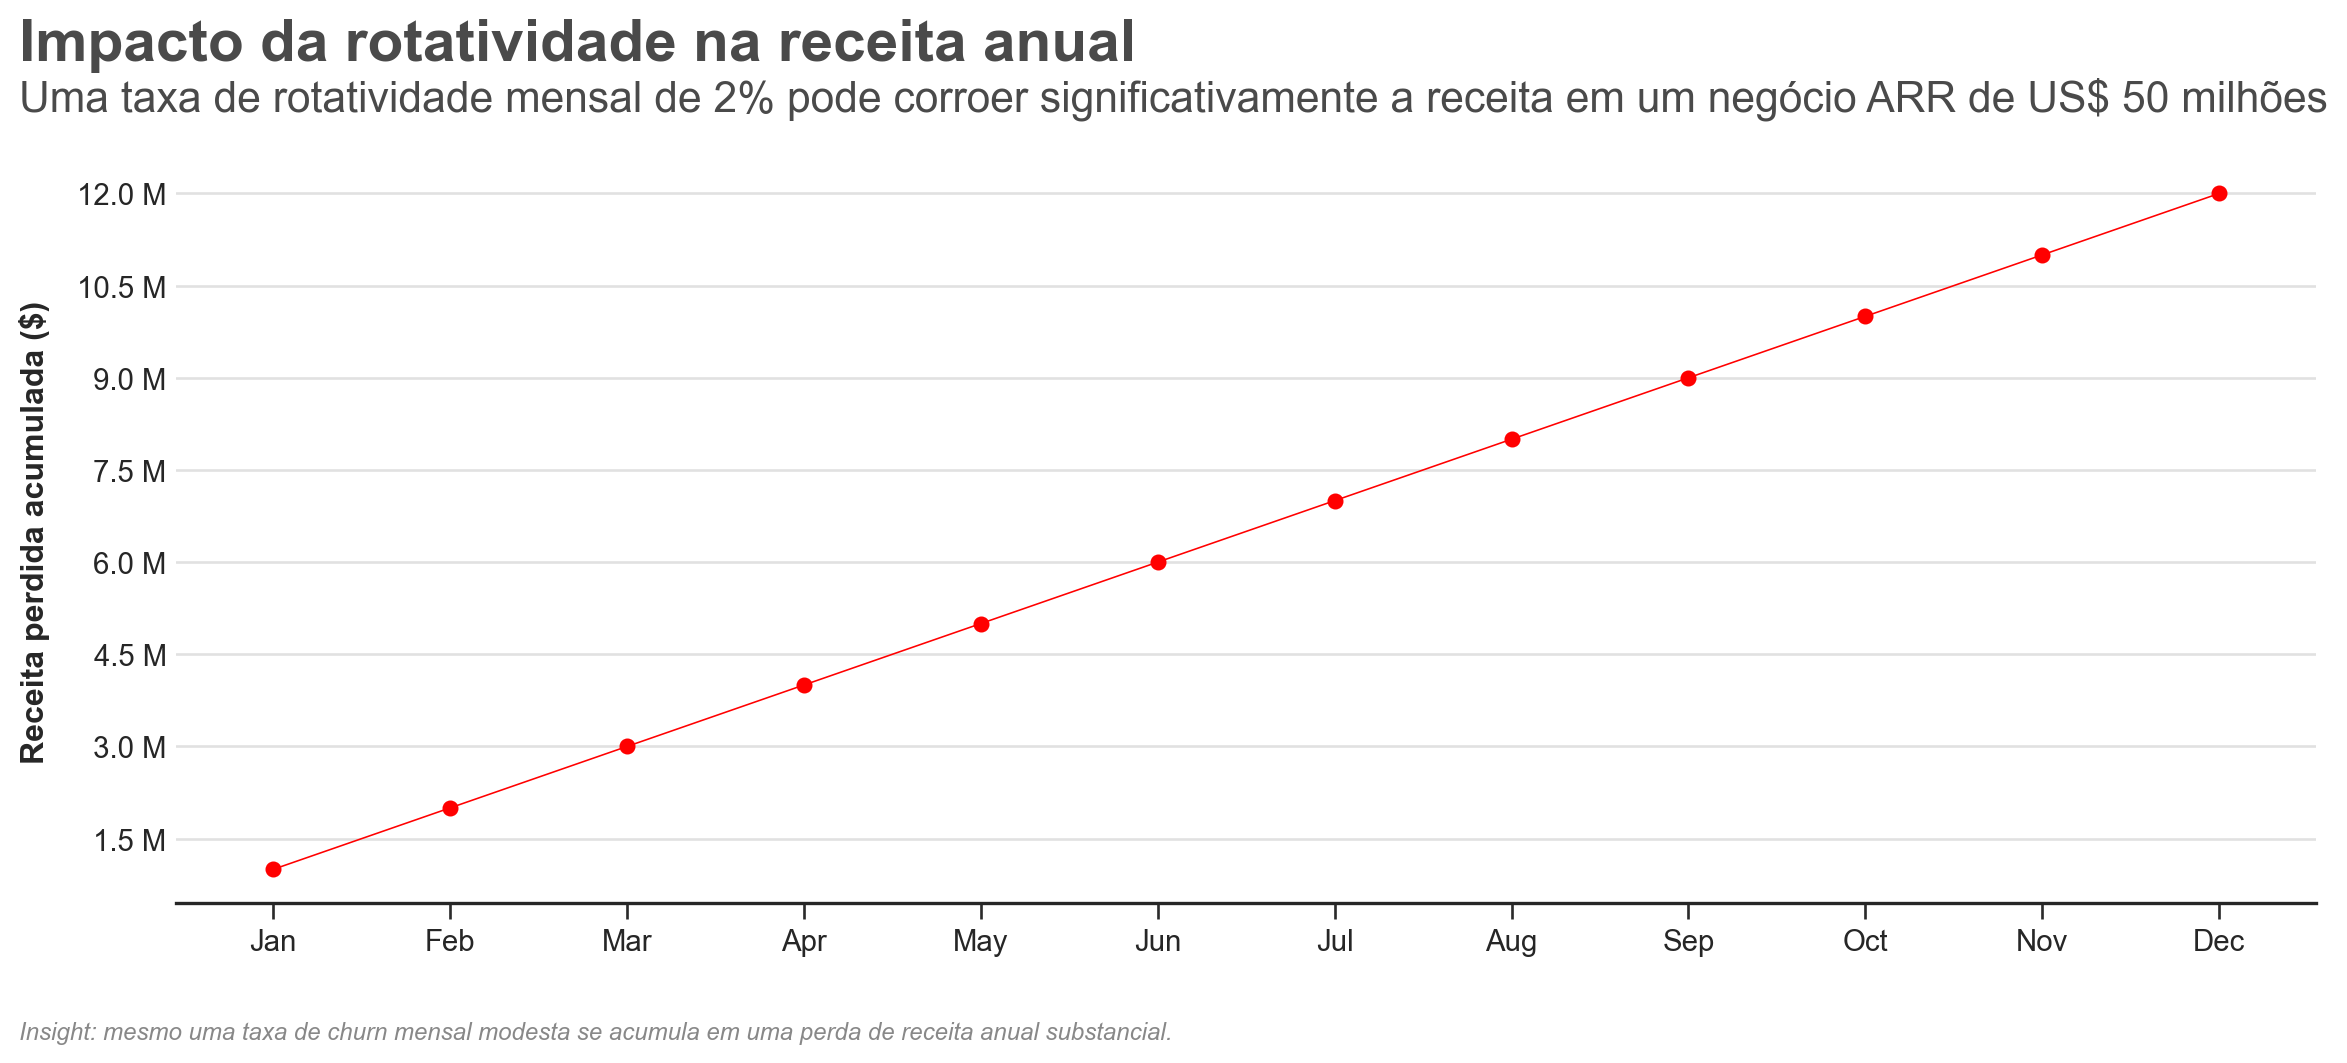

In [2]:
set_corporate_theme()

dict_in = lang({
    'footer_text': "Insight: mesmo uma taxa de churn mensal modesta se acumula em uma perda de receita anual substancial.",
})

plot_annual_churn_impact(
    annual_revenue=50_000_000,
    churn_rate=0.02,
    footer_text=dict_in['footer_text'],
    show_footer=True
)


<span style="color:steelblue; text-align: left">

## Dataset
</span>

Esta análise utiliza o [dataset Telecom Customer Churn](https://www.kaggle.com/datasets/puja19/telecom-customer-churn), que contém informações em nível de cliente sobre dados demográficos, serviços e status de churn.


In [3]:
telecom = read_data()

# Verificações básicas
print(f"Shape: {telecom.shape}")
display(telecom['Churn'].value_counts())


Shape: (7043, 21)


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [4]:
telecom.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<span style="color:steelblue; text-align: left">

### Explorando a Distribuição de Churn
</span>

Um primeiro passo importante é verificar se a variável alvo está desbalanceada, ou seja, se uma classe é substancialmente mais frequente que a outra. Neste dataset, aproximadamente 26,5% dos clientes realizaram churn, enquanto 73,5% não o fizeram.

Isso indica um desbalanceamento moderado de classes. A classe minoritária ainda está bem representada, portanto o dataset não está severamente desbalanceado. No entanto, o desbalanceamento de classes deve ser considerado durante a avaliação do modelo, especialmente na interpretação de métricas como acurácia, precisão, recall e F1-score.

Em etapas posteriores, estratégias de reamostragem podem ser testadas para avaliar se melhoram o desempenho preditivo para a classe de churn.


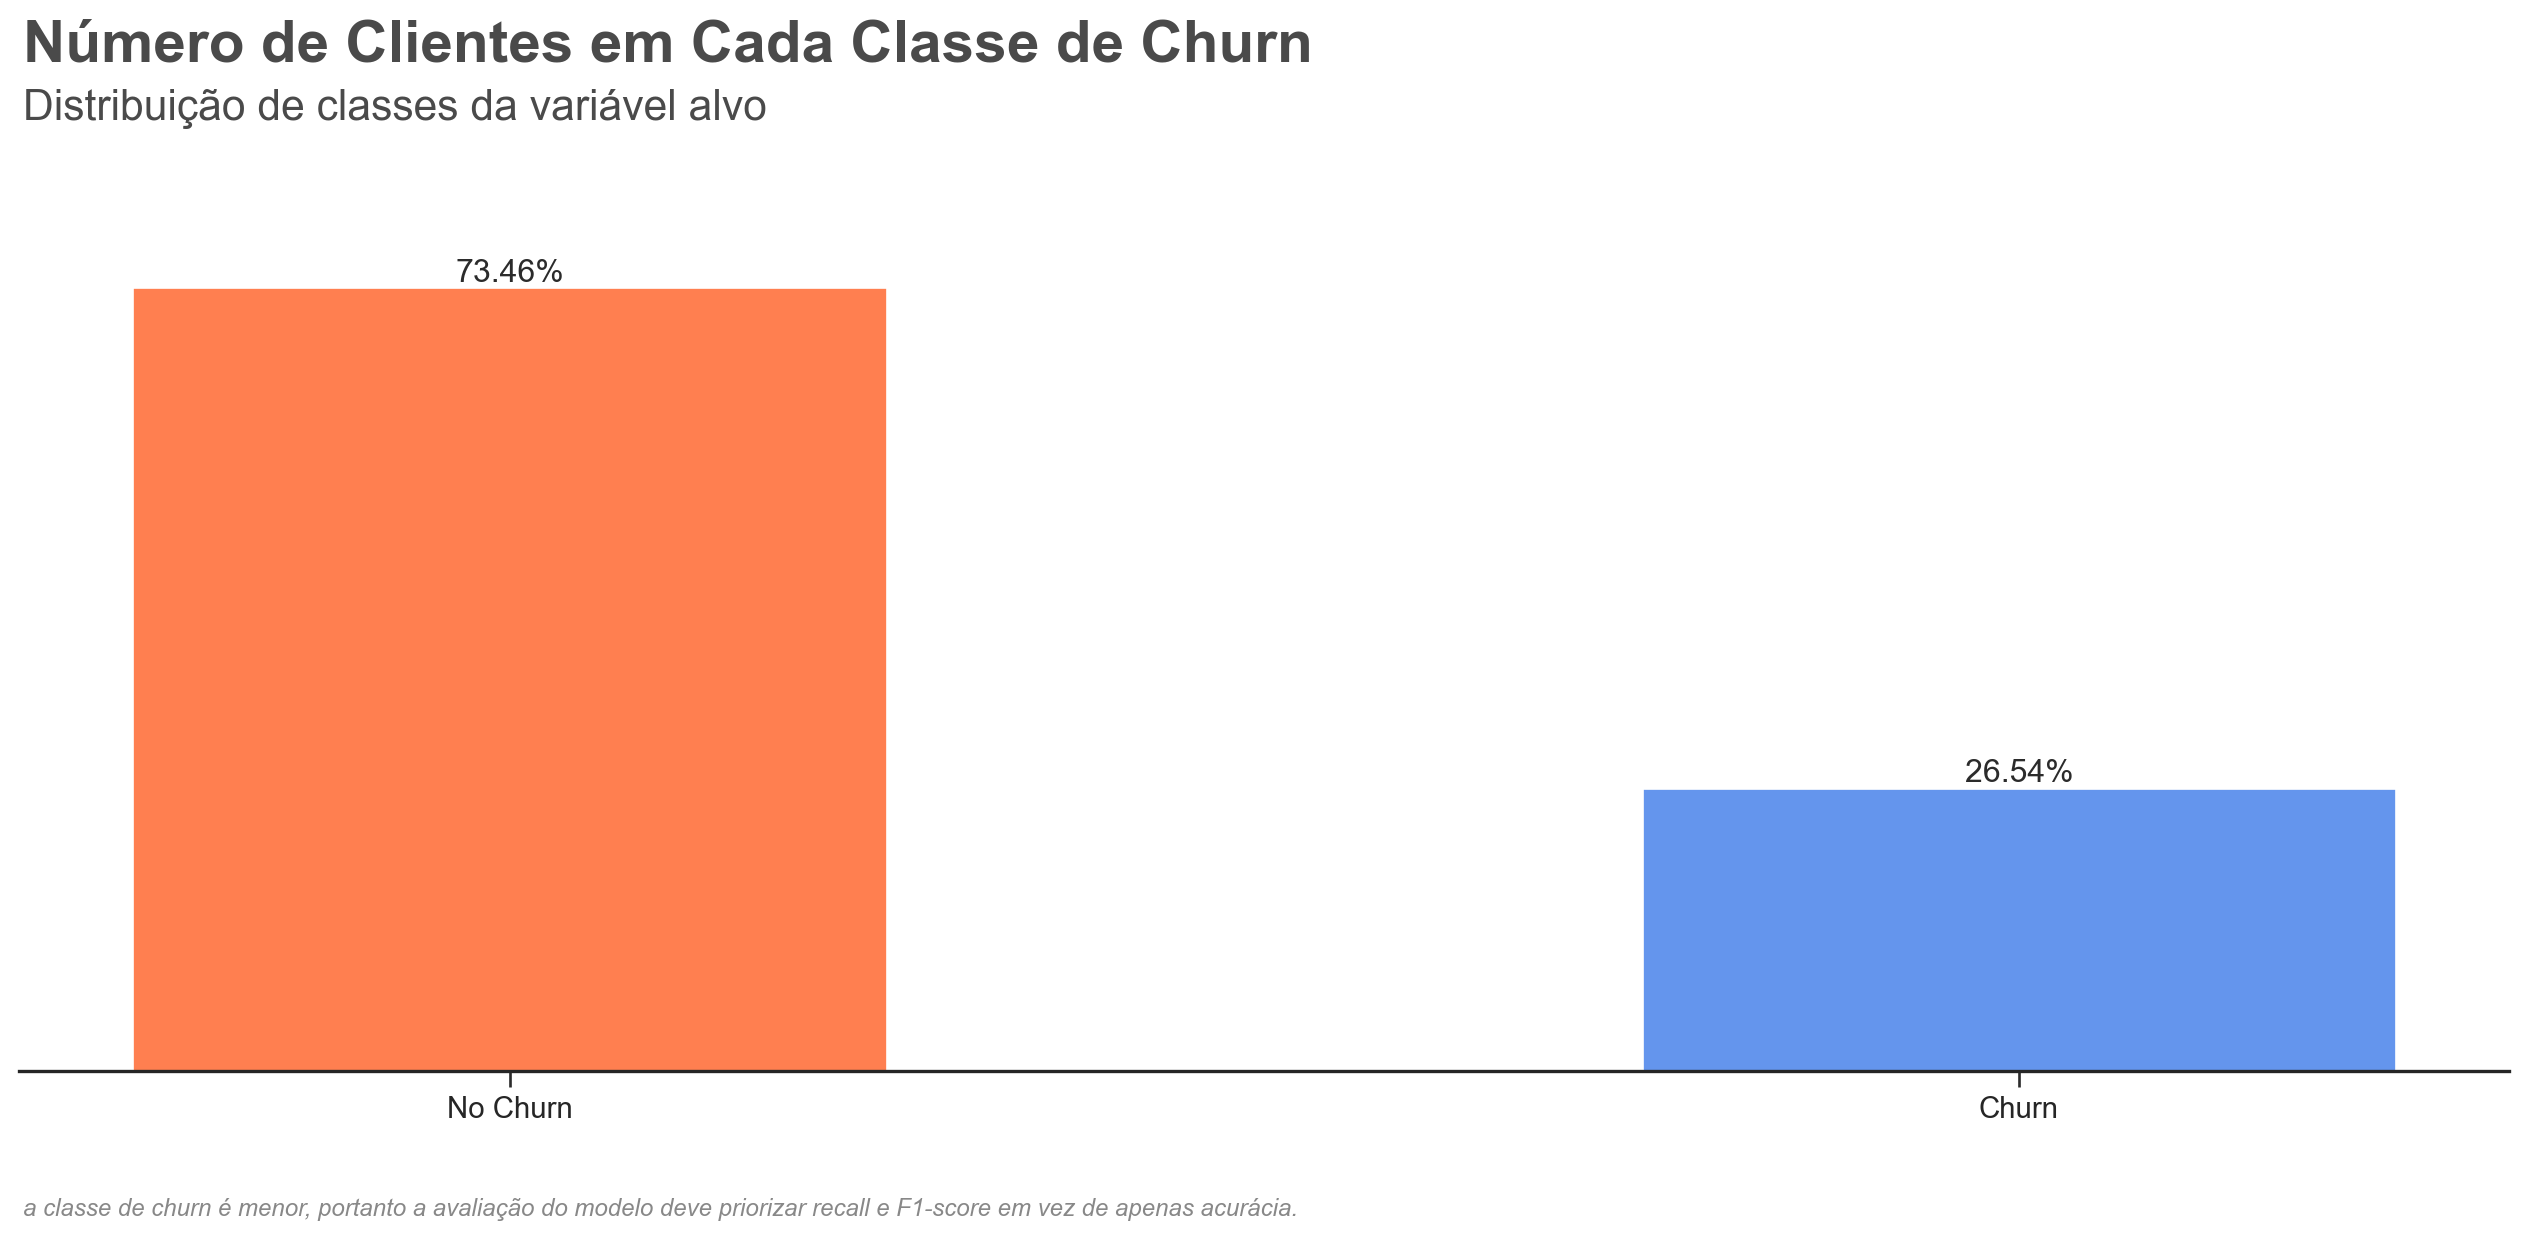

In [5]:
dict_in = lang({
    'title': "Número de Clientes em Cada Classe de Churn",
    'subtitle': "Distribuição de classes da variável alvo",
    'footer_text': "a classe de churn é menor, portanto a avaliação do modelo deve priorizar recall e F1-score em vez de apenas acurácia.",
})

plot_churn_distribution(
    telecom,
    churn_col='Churn',
    title=dict_in['title'],
    subtitle=dict_in['subtitle'],
    footer_text=dict_in['footer_text'],
    show_footer=True
)


<span style="color:steelblue; text-align: left">

### Significado das Features
</span>


In [6]:
telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


<span style="color:steelblue; text-align: left">

### Definição das Features
</span>

Esta visão estruturada auxilia na engenharia de features e na seleção de variáveis durante a modelagem.

O dataset contém informações em nível de cliente que podem ser agrupadas em quatro categorias principais:


**Variável Alvo**

- `Churn` — Indica se o cliente realizou churn (Sim / Não)


**Serviços Assinados**

- `PhoneService` — Cliente possui serviço telefônico (Sim / Não)
- `MultipleLines` — Múltiplas linhas telefônicas (Sim / Não / Sem serviço de telefone)
- `InternetService` — Tipo de serviço de internet (DSL / Fibra óptica / Não)
- `OnlineSecurity` — Add-on de segurança online (Sim / Não / Sem serviço de internet)
- `OnlineBackup` — Serviço de backup (Sim / Não / Sem serviço de internet)
- `DeviceProtection` — Plano de proteção de dispositivo (Sim / Não / Sem serviço de internet)
- `TechSupport` — Serviço de suporte técnico (Sim / Não / Sem serviço de internet)
- `StreamingTV` — Serviço de streaming de TV (Sim / Não / Sem serviço de internet)
- `StreamingMovies` — Serviço de streaming de filmes (Sim / Não / Sem serviço de internet)


**Informações da Conta**

- `tenure` — Número de meses que o cliente está ativo
- `Contract` — Tipo de contrato (Mensal / Um ano / Dois anos)
- `PaperlessBilling` — Fatura sem papel habilitada (Sim / Não)
- `PaymentMethod` — Método de pagamento utilizado pelo cliente
- `MonthlyCharges` — Valor da cobrança mensal
- `TotalCharges` — Total de cobranças acumuladas


**Perfil do Cliente**

- `customerID` — Identificador único do cliente
- `gender` — Gênero do cliente
- `SeniorCitizen` — Indicador de idoso (1 = Sim, 0 = Não)
- `Partner` — Possui parceiro(a) (Sim / Não)
- `Dependents` — Possui dependentes (Sim / Não)


**Convertendo TotalCharges para tipo de dado numérico**


In [7]:
# Converter para numérico
telecom['TotalCharges'] = pd.to_numeric(telecom['TotalCharges'], errors='coerce')

# Verificar valores ausentes
missing_total = telecom['TotalCharges'].isnull().sum()
telecom[telecom['TotalCharges'].isnull()][['tenure', 'MonthlyCharges']]
print(f"Valores ausentes em TotalCharges: {missing_total}")


Valores ausentes em TotalCharges: 11


Após converter `TotalCharges` para numérico, foram identificados 11 valores ausentes.

Esses valores ausentes estão associados a clientes com tenure muito baixo (tipicamente novos clientes sem cobranças acumuladas). Dada a pequena proporção de linhas afetadas, elas podem ser removidas com segurança sem impactar a análise.

Portanto, essas observações são excluídas do dataset.


In [8]:
# Remover valores ausentes
telecom = telecom.dropna(subset=['TotalCharges'])


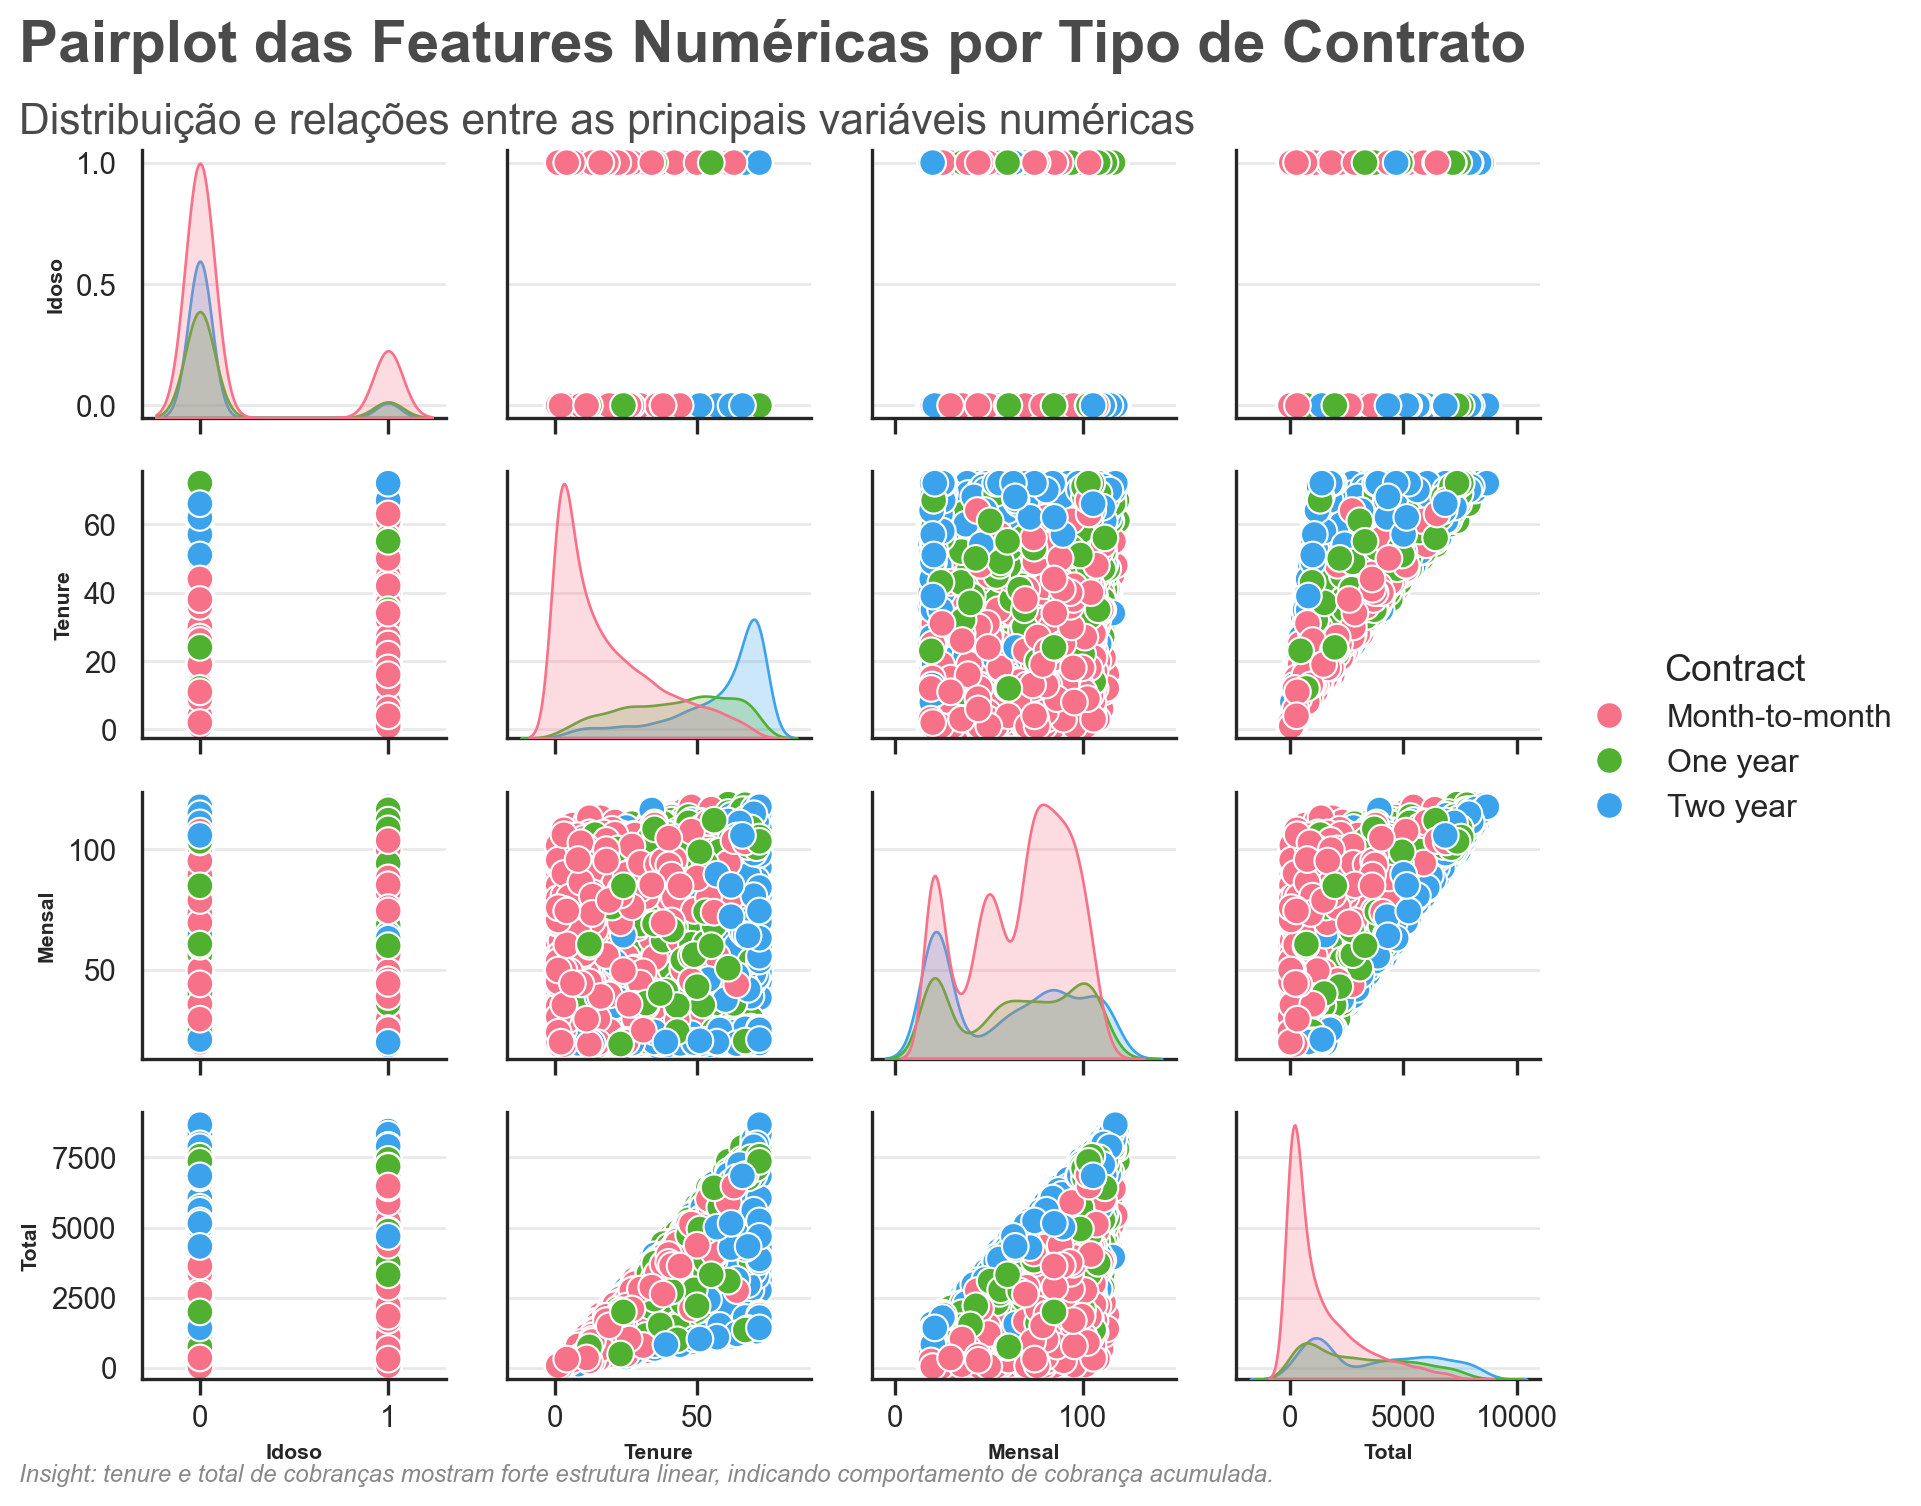

In [9]:
rename_dict = {
    'MonthlyCharges': 'Mensal',
    'TotalCharges': 'Total',
    'SeniorCitizen': 'Idoso',
    'tenure': 'Tenure'
}

dict_in = lang({
    'title': "Pairplot das Features Numéricas por Tipo de Contrato",
    'subtitle': "Distribuição e relações entre as principais variáveis numéricas",
    'footer_text': "Insight: tenure e total de cobranças mostram forte estrutura linear, indicando comportamento de cobrança acumulada.",
})

plot_pairplot_corporate(
    telecom,
    rename_dict=rename_dict,
    hue='Contract',
    title=dict_in['title'],
    subtitle=dict_in['subtitle'],
    show_footer=True,
    footer_text=dict_in['footer_text']
)


<span style="color:steelblue; text-align: left">

## Análise Exploratória de Dados (AED)
</span>

A análise começa com uma exploração inicial do dataset para identificar padrões, distribuições e possíveis relações entre variáveis.

O foco está em:
- Distribuições univariadas (comportamento individual de cada feature)
- Relações bivariadas (interação entre features)

<span style="color:steelblue; text-align: left">

### Características Numéricas
</span>

Histogramas são usados para avaliar a distribuição das variáveis numéricas, enquanto gráficos de dispersão ajudam a identificar relações e potenciais correlações entre elas.


O pairplot fornece uma visão combinada das distribuições univariadas e das relações entre pares das principais variáveis numéricas, segmentadas por tipo de contrato.

**Insights:**
- `Tenure` e `Total` mostram uma forte relação positiva, refletindo a natureza cumulativa da cobrança — vidas úteis mais longas dos clientes se traduzem diretamente em maiores cobranças totais.
- Clientes com contratos `Mensal` estão concentrados em valores mais baixos de `Tenure` e `Total`, indicando ciclos de vida mais curtos e maior exposição ao churn em comparação com contratos de longo prazo.
- As cobranças `Mensais` apresentam ampla dispersão entre os tipos de contrato, sugerindo poder discriminativo limitado quando usadas isoladamente.
- `Idoso` é uma feature binária (0/1). Apesar de plotada como numérica, sua interpretabilidade é categórica e deve ser tratada como tal na modelagem.

Após revisar o comportamento numérico, procedemos à distribuição das variáveis categóricas, começando pelo gênero.

<span style="color:steelblue; text-align: left">

###  Distribuição por Gênero
</span>


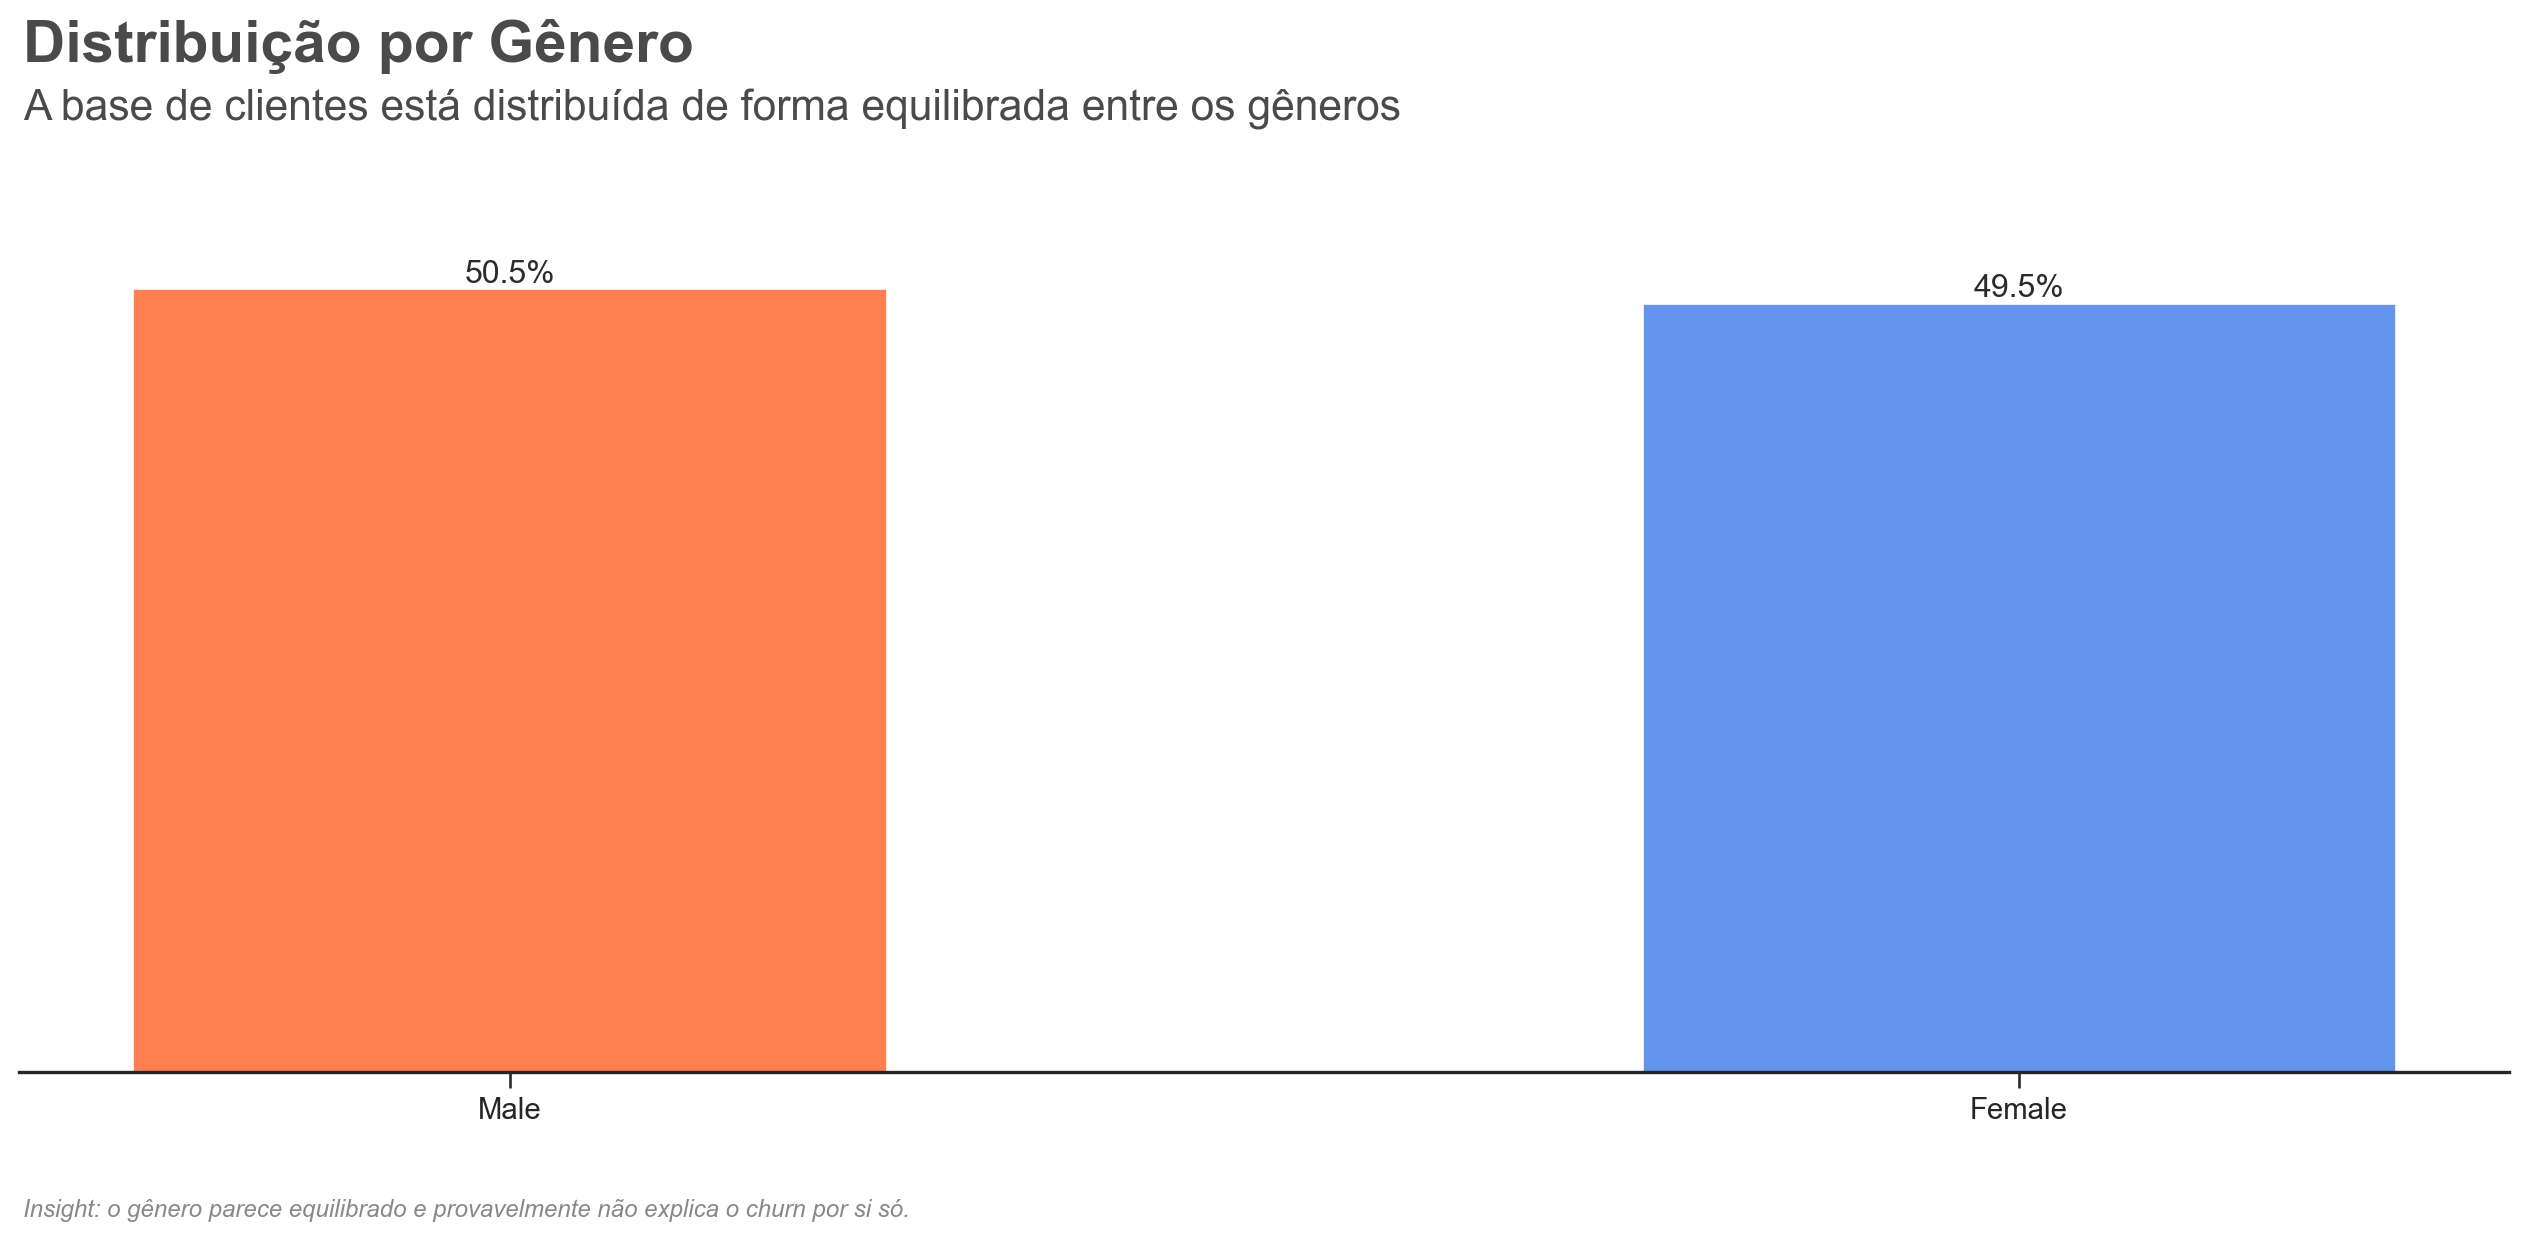

In [10]:
dict_in = lang({
    'title': "Distribuição por Gênero",
    'subtitle': "A base de clientes está distribuída de forma equilibrada entre os gêneros",
    'footer_text': "Insight: o gênero parece equilibrado e provavelmente não explica o churn por si só.",
})

plot_gender_distribution(
    telecom,
    gender_col='gender',
    title=dict_in['title'],
    subtitle=dict_in['subtitle'],
    footer_text=dict_in['footer_text'],
    show_footer=True
)


**Insights:**
- A base de clientes está quase igualmente dividida entre clientes masculinos e femininos, indicando nenhum desbalanceamento significativo de classe para esta feature.
- Isso sugere que o gênero, por si só, é improvável que seja um forte discriminador de churn.
- Maior poder explicativo é esperado de variáveis comportamentais, contratuais e relacionadas à cobrança.
- Como a distribuição está equilibrada, nenhum ajuste é necessário para esta feature do ponto de vista de representação de classe.

<span style="color:steelblue; text-align: left">

###  Distribuição de Idosos
</span>


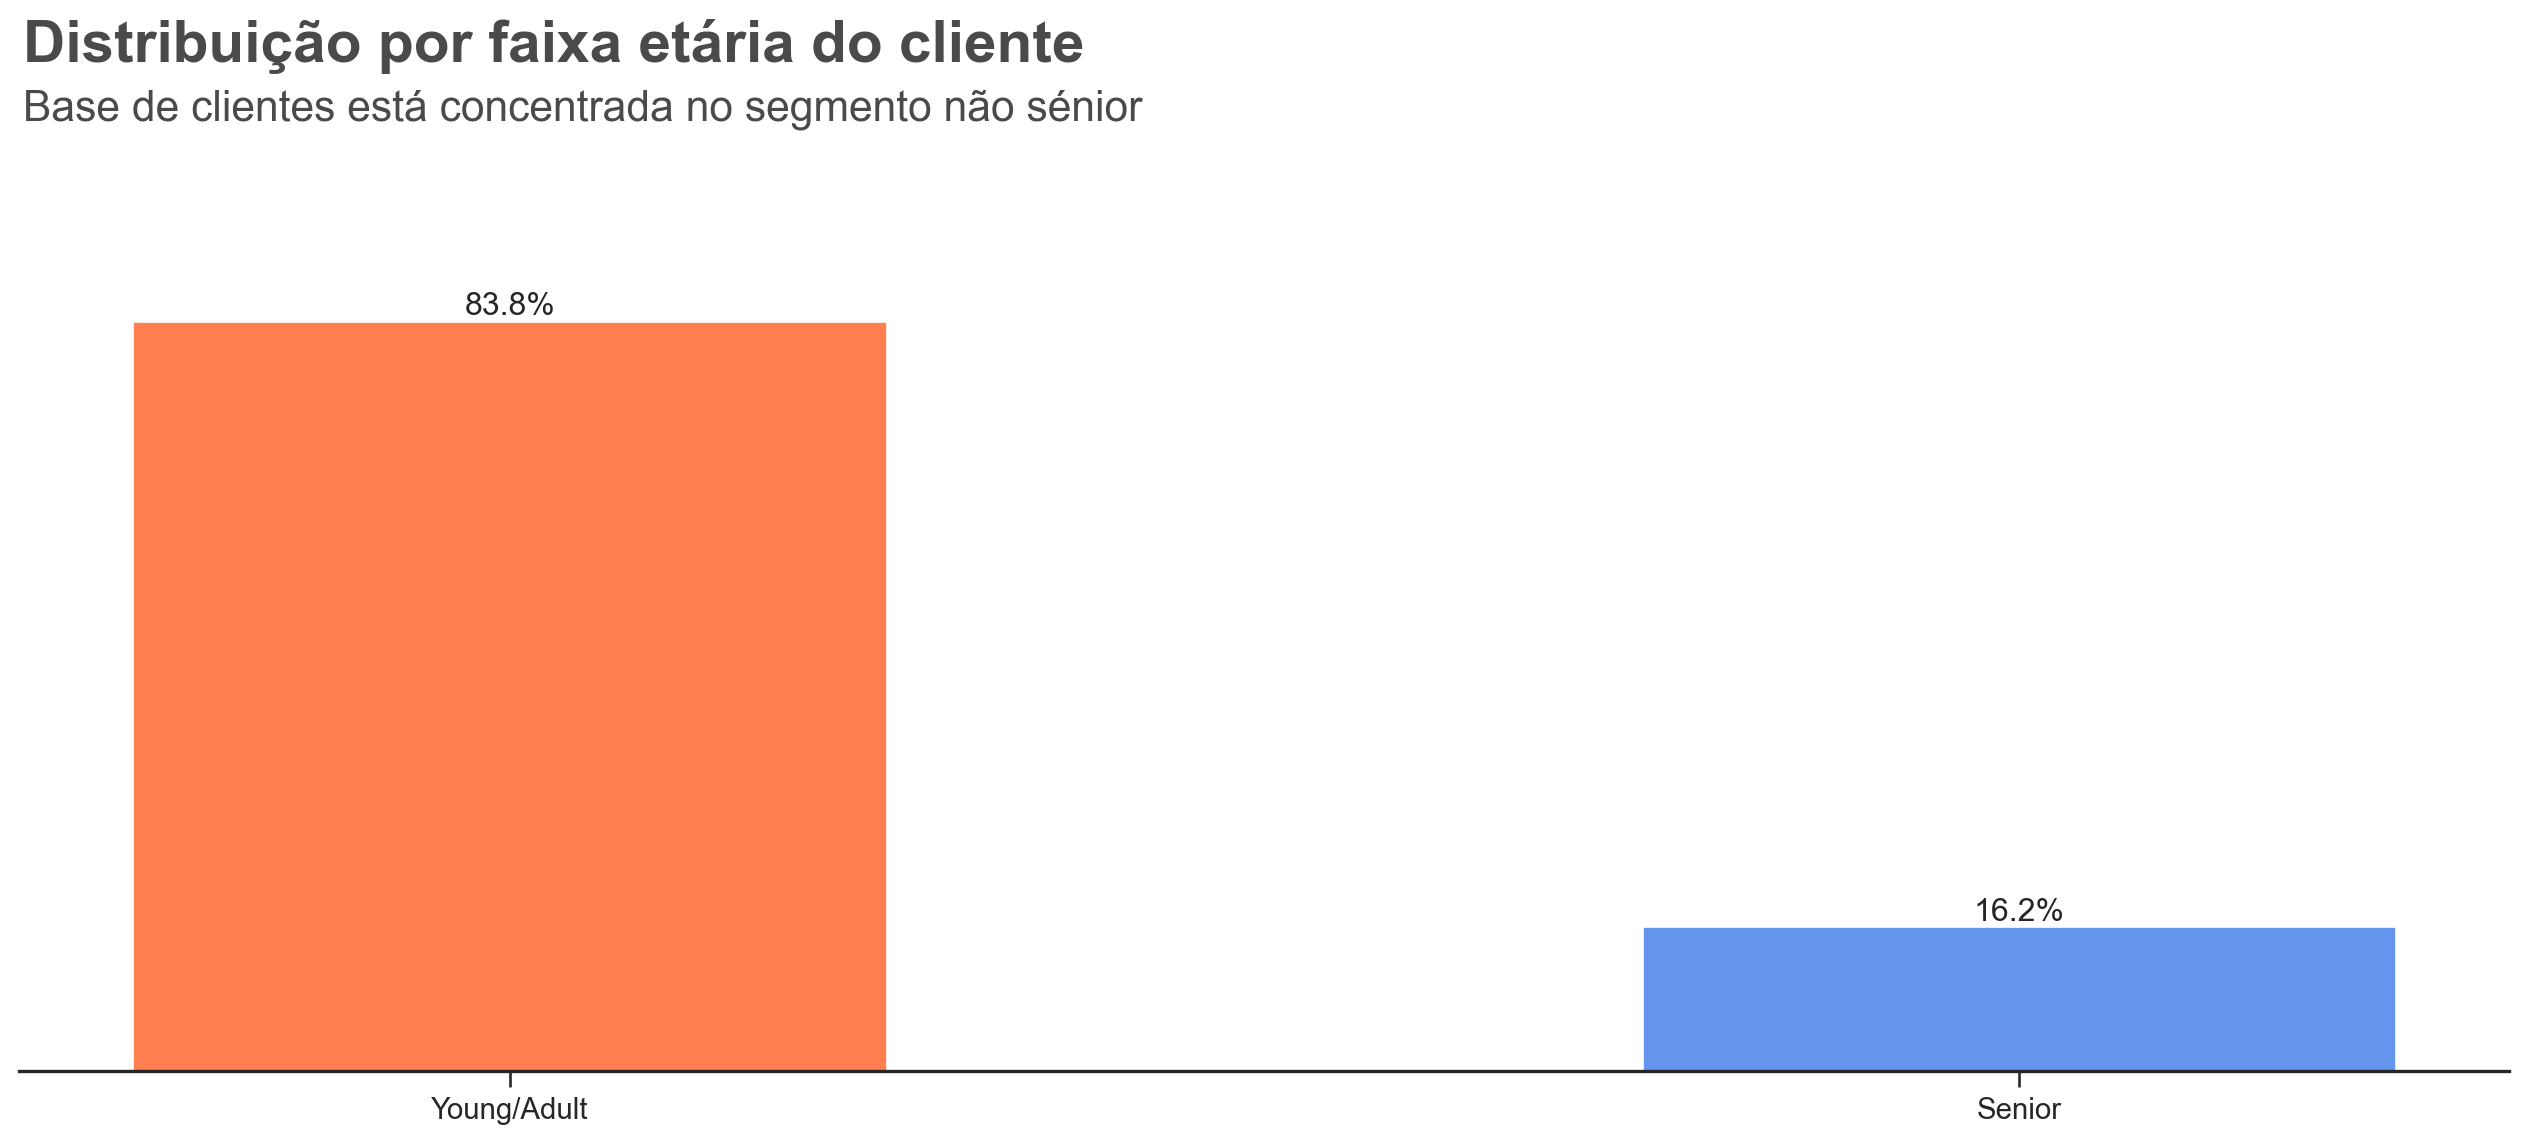

In [11]:
plot_senior_distribution(telecom)

**Insights:**
- Clientes idosos representam uma minoria (~16%) da base, com a maioria concentrada no segmento não idoso.
- Esse desbalanceamento sugere que os padrões envolvendo clientes idosos devem ser interpretados com cautela devido à menor representação amostral.
- Apesar da menor participação, esse segmento pode apresentar padrões comportamentais distintos e deve ser avaliado separadamente na análise de churn.

<span style="color:steelblue; text-align: left">

###  Distribuição por Parceiro e Dependentes
</span>


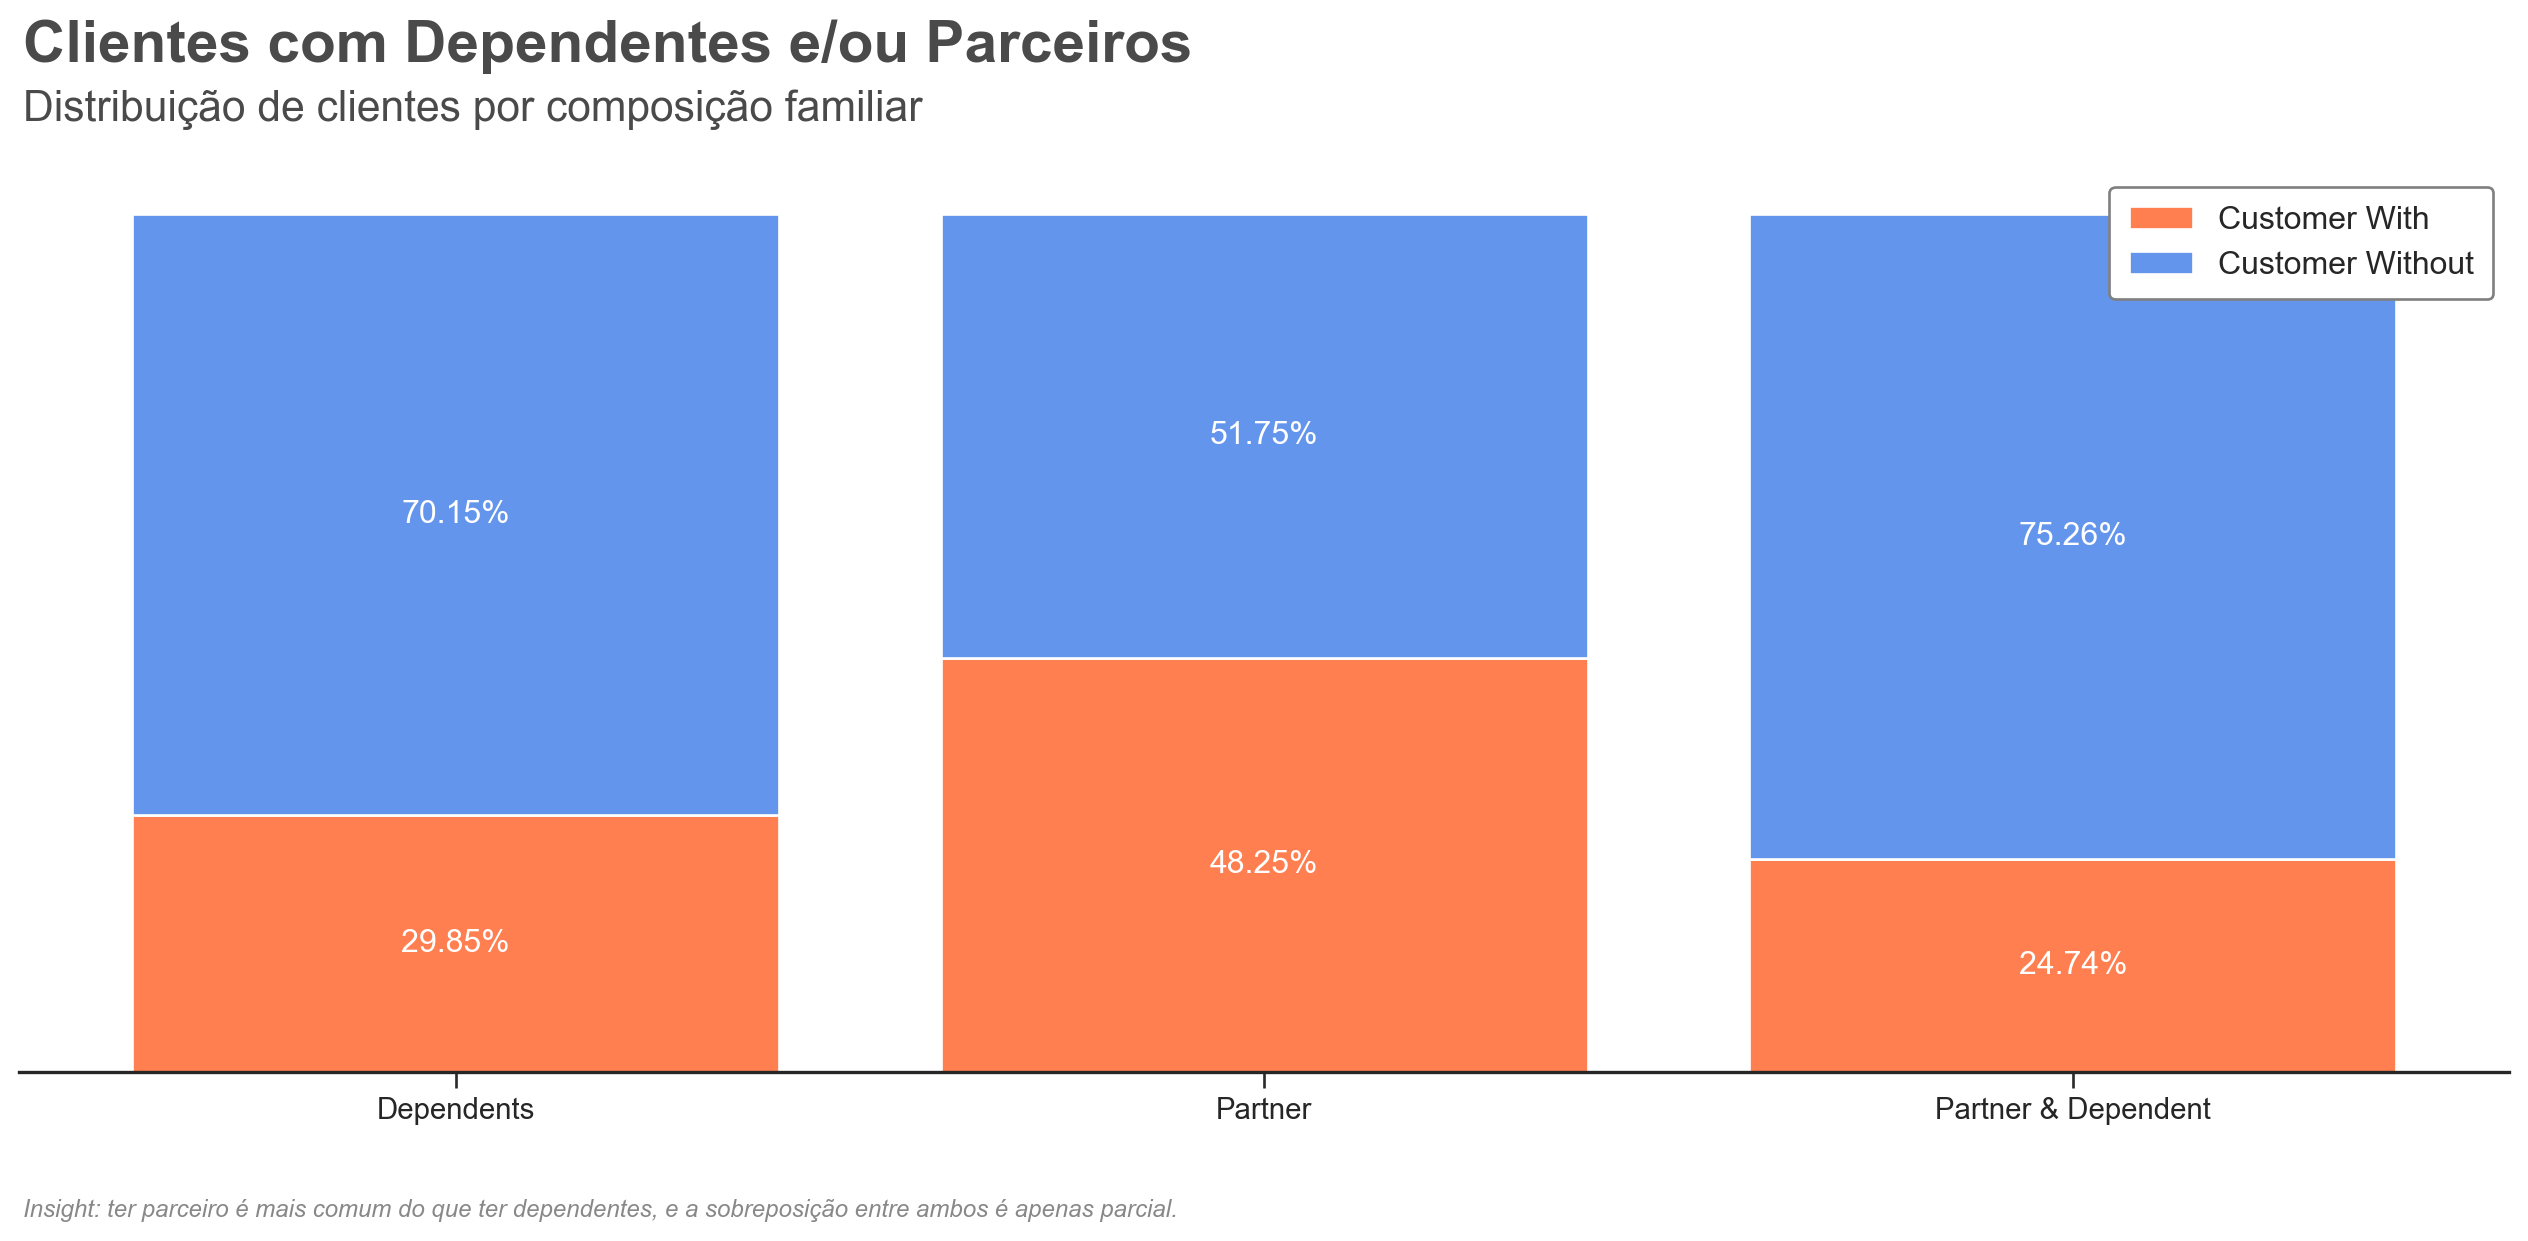

In [12]:
dict_in = lang({
    'title': "Clientes com Dependentes e/ou Parceiros",
    'subtitle': "Distribuição de clientes por composição familiar",
    'footer_text': "Insight: ter parceiro é mais comum do que ter dependentes, e a sobreposição entre ambos é apenas parcial.",
})

plot_household_composition(
    telecom,
    partner_col='Partner',
    dependents_col='Dependents',
    title=dict_in['title'],
    subtitle=dict_in['subtitle'],
    footer_text=dict_in['footer_text'],
    show_footer=True
)


**Insights:**
- A maioria dos clientes não possui simultaneamente parceiro e dependentes, sugerindo predominância de perfis domésticos mais independentes.
- Clientes com parceiros (~48%) são mais comuns do que clientes com dependentes (~30%), indicando que dependentes são uma condição mais restritiva nesta amostra.
- A sobreposição entre ter parceiro e ter dependentes é apenas parcial, mostrando que essas variáveis estão relacionadas, mas não são intercambiáveis.
- A composição familiar pode influenciar o comportamento do cliente e deve ser considerada na análise de churn subsequente.

<span style="color:steelblue; text-align: left">

###  Distribuição de Tenure
</span>

`tenure` representa o número de meses que cada cliente permaneceu com a empresa.


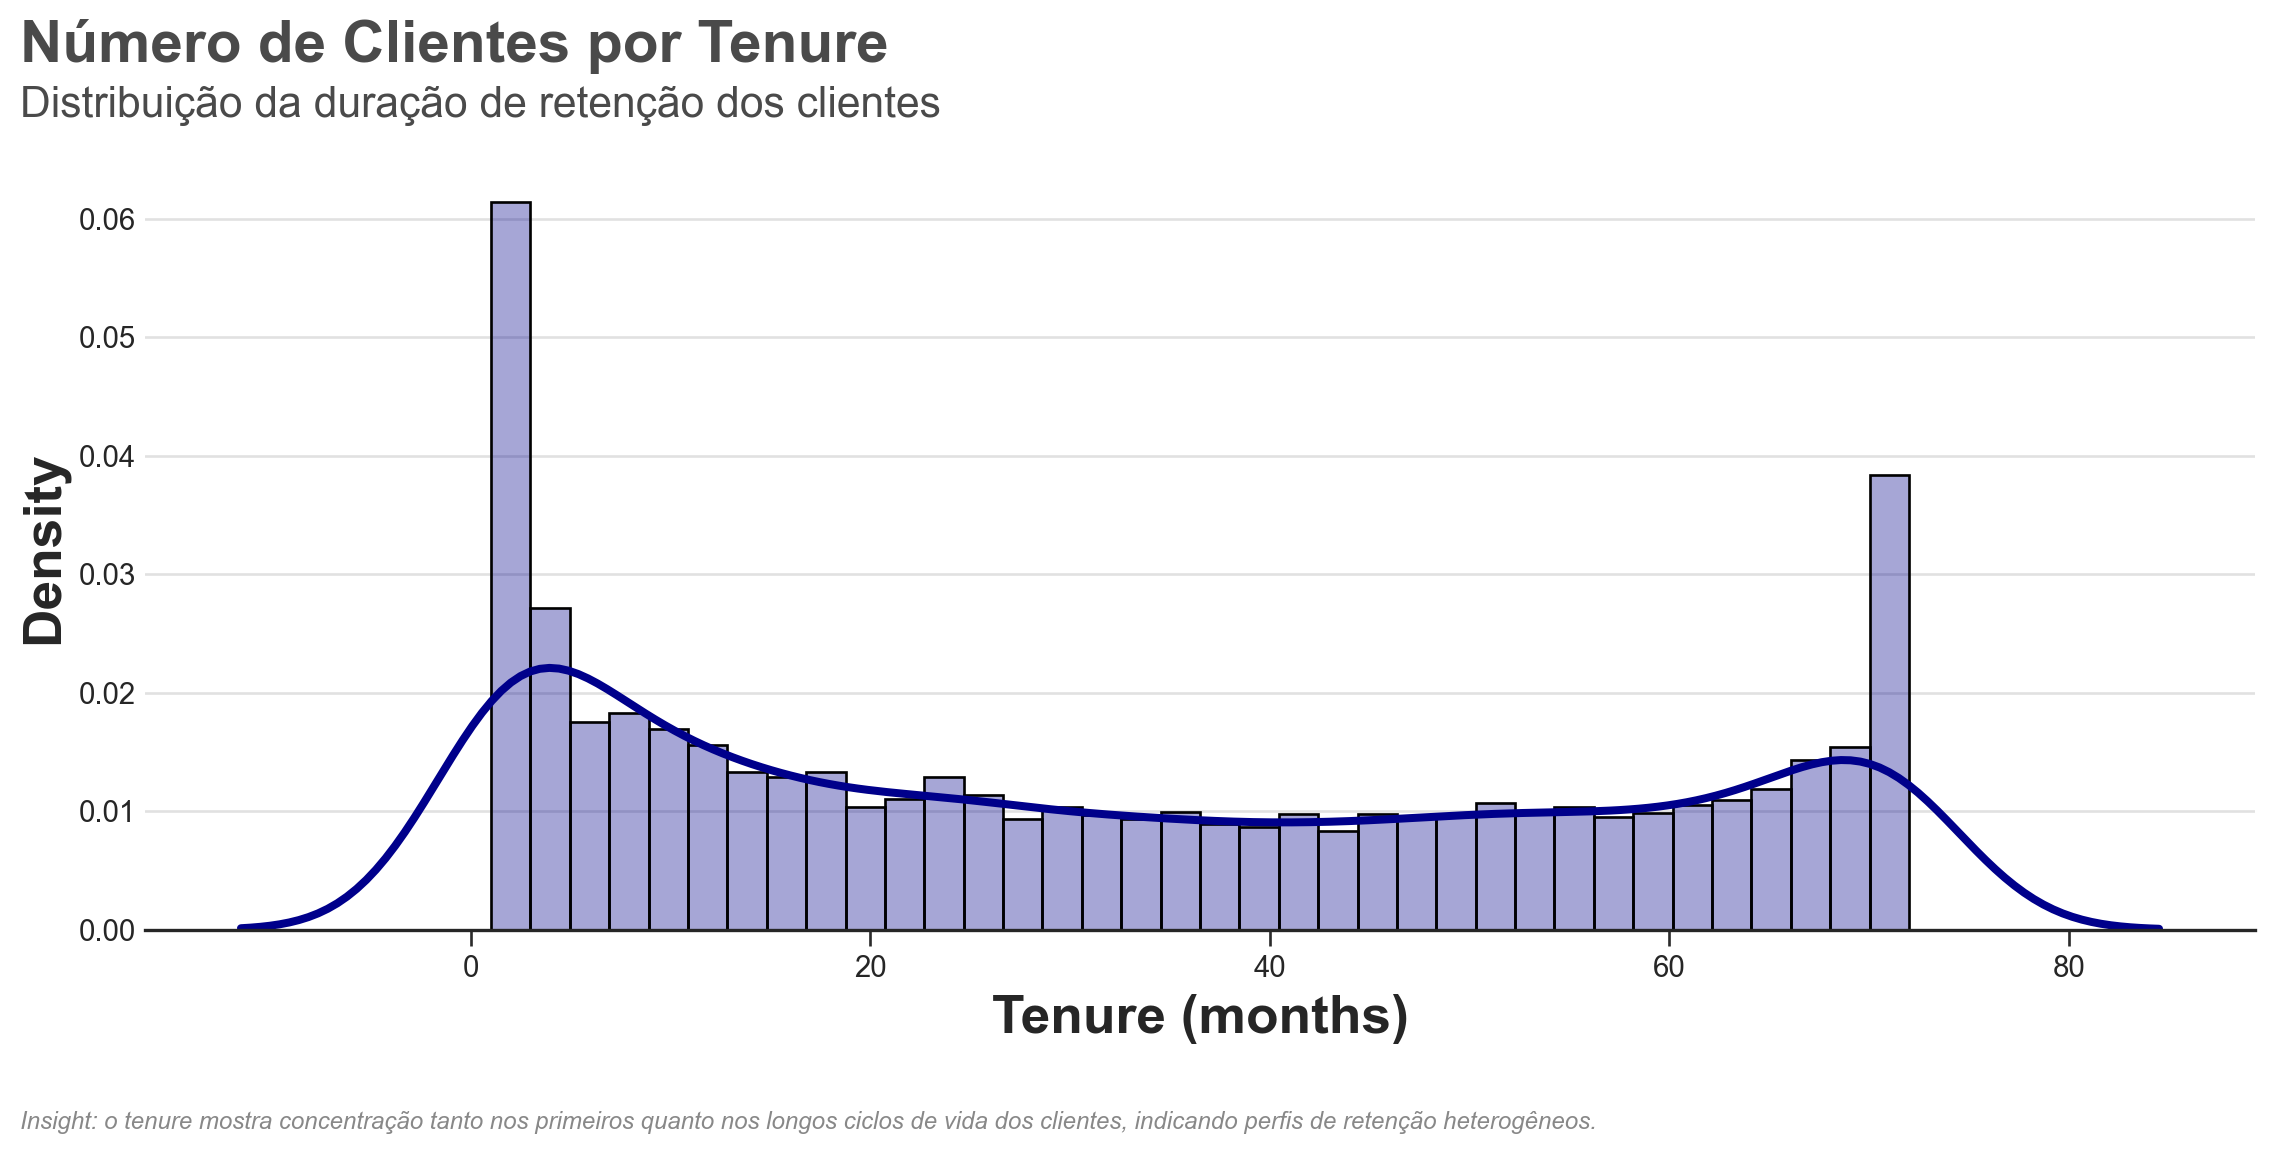

In [13]:
dict_in = lang({
    'title': "Número de Clientes por Tenure",
    'subtitle': "Distribuição da duração de retenção dos clientes",
    'footer_text': "Insight: o tenure mostra concentração tanto nos primeiros quanto nos longos ciclos de vida dos clientes, indicando perfis de retenção heterogêneos.",
})

plot_tenure_distribution(
    telecom,
    tenure_col='tenure',
    title=dict_in['title'],
    subtitle=dict_in['subtitle'],
    footer_text=dict_in['footer_text'],
    show_footer=True
)


**Insights:**
- A distribuição está concentrada nos primeiros meses do relacionamento.
- Uma segunda concentração aparece entre clientes com tenure longo.
- Isso sugere diferentes perfis de retenção, provavelmente associados ao tipo de contrato.

<span style="color:steelblue; text-align: left">

### Distribuição de Contratos
</span>

Para melhor interpretar a distribuição de tenure, é útil primeiro examinar como os clientes estão distribuídos pelos tipos de contrato.


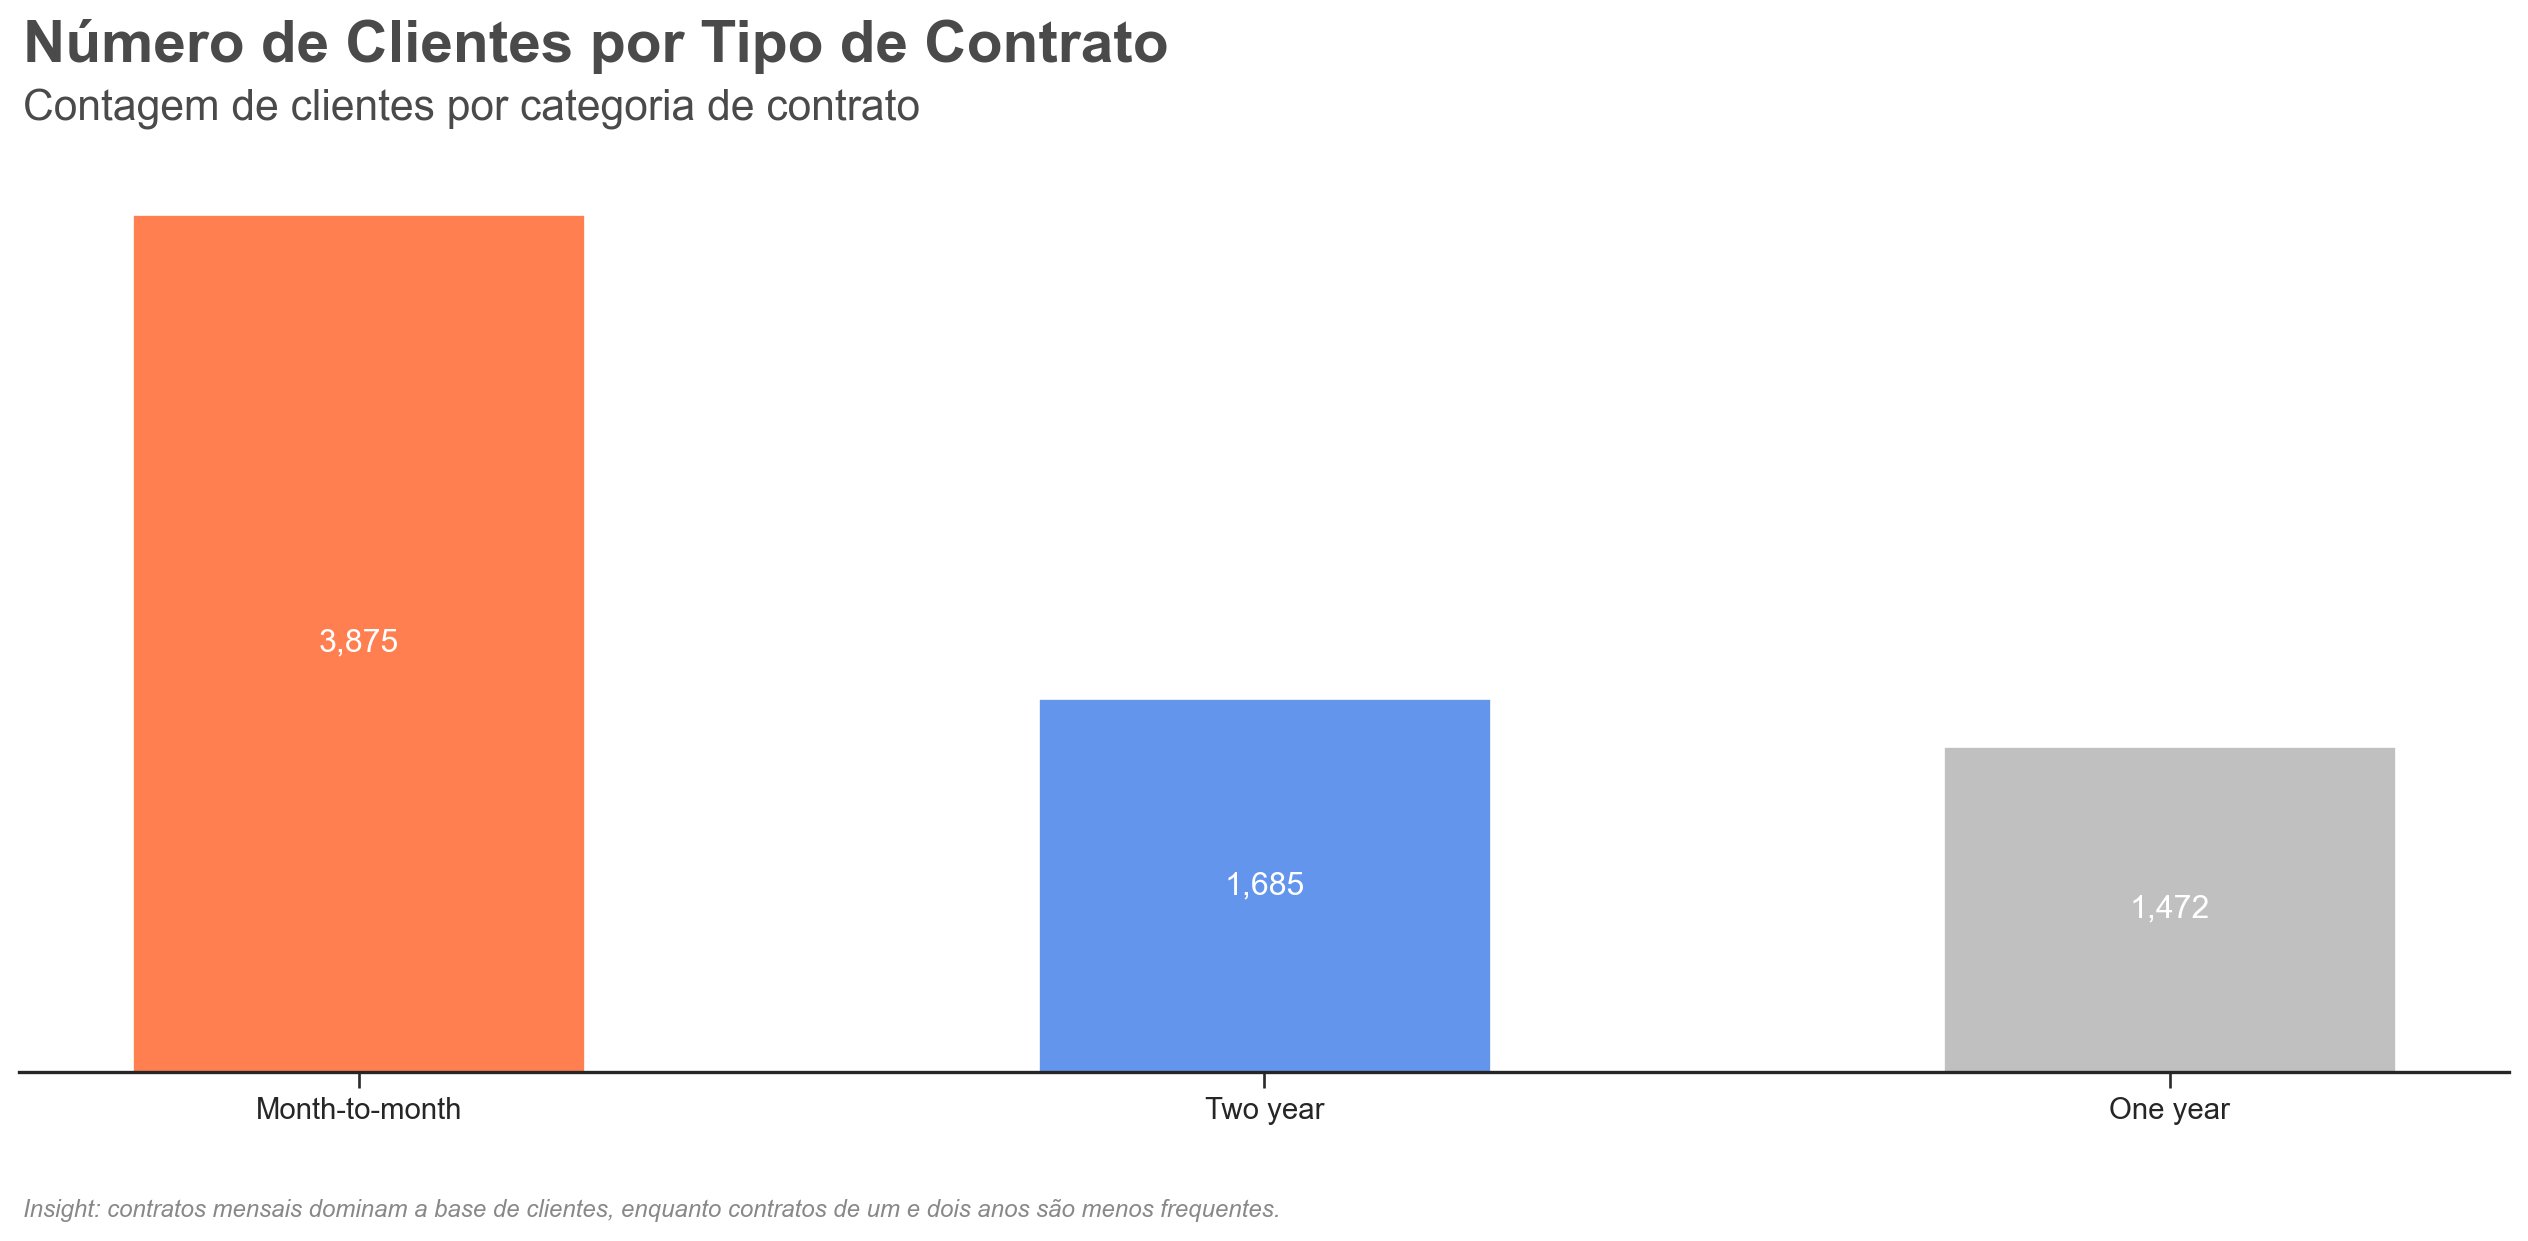

In [14]:
dict_in = lang({
    'title': "Número de Clientes por Tipo de Contrato",
    'subtitle': "Contagem de clientes por categoria de contrato",
    'footer_text': "Insight: contratos mensais dominam a base de clientes, enquanto contratos de um e dois anos são menos frequentes.",
})

plot_contract_distribution(
    telecom,
    contract_col='Contract',
    title=dict_in['title'],
    subtitle=dict_in['subtitle'],
    footer_text=dict_in['footer_text'],
    show_footer=True
)


**Insights:**
- A maioria dos clientes possui contratos mensais.
- Contratos de um e dois anos têm representação menor e relativamente similar.
- Essa concentração em contratos de curto prazo é relevante, pois o tipo de contrato provavelmente influencia o comportamento de retenção.

Abaixo, o tenure é examinado separadamente para cada tipo de contrato.


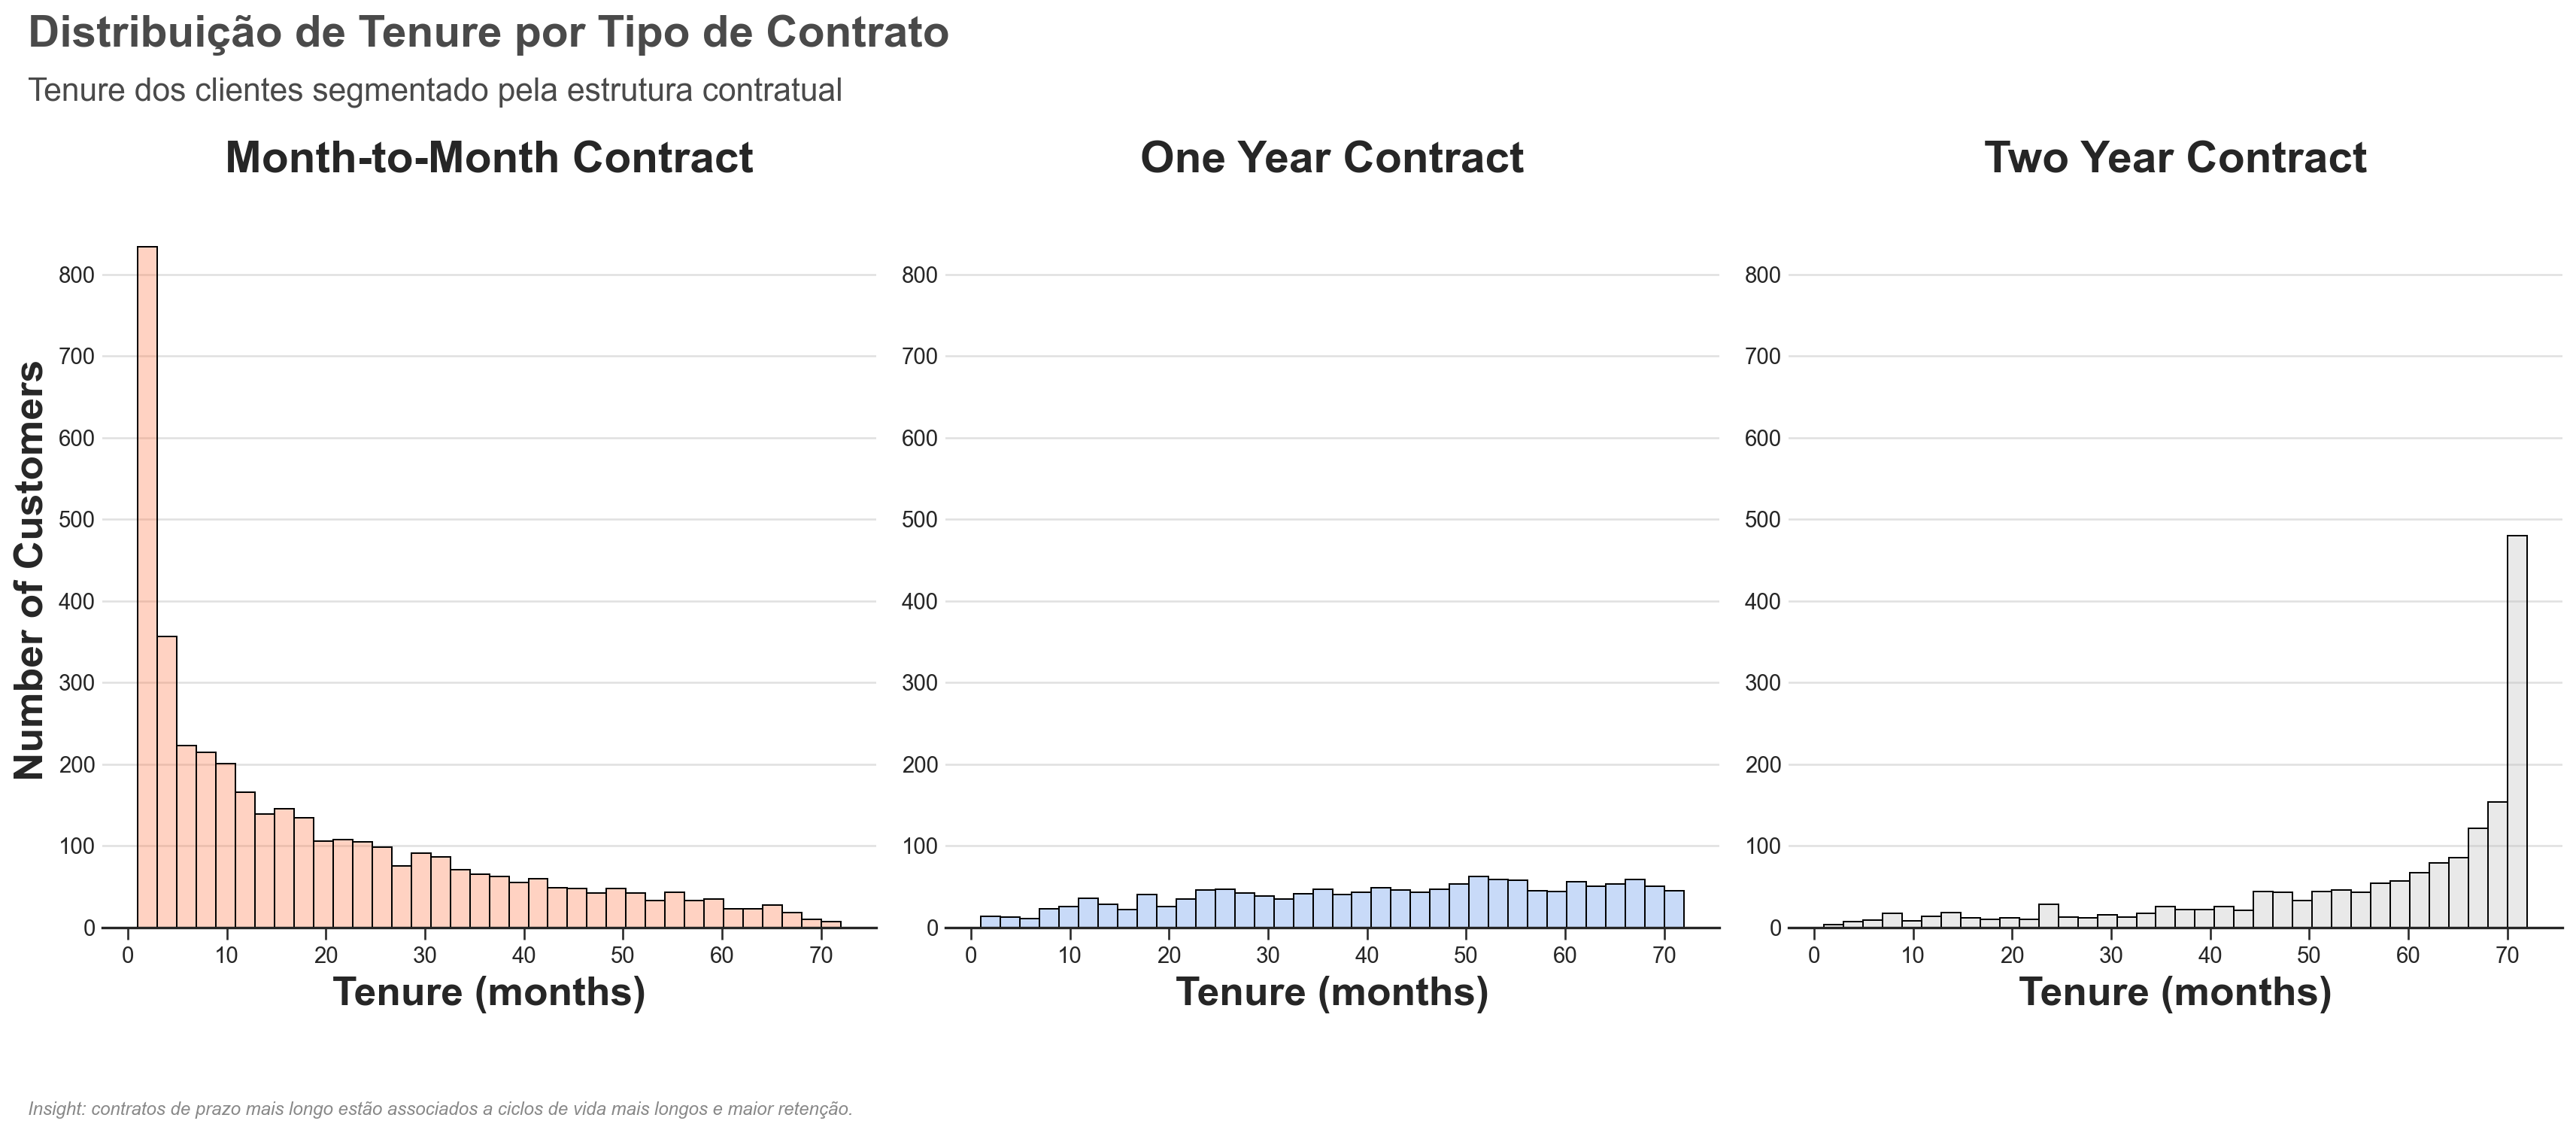

In [15]:
dict_in = lang({
    'title': "Distribuição de Tenure por Tipo de Contrato",
    'subtitle': "Tenure dos clientes segmentado pela estrutura contratual",
    'footer_text': "Insight: contratos de prazo mais longo estão associados a ciclos de vida mais longos e maior retenção.",
})

plot_tenure_by_contract(
    telecom,
    contract_col='Contract',
    tenure_col='tenure',
    title=dict_in['title'],
    subtitle=dict_in['subtitle'],
    footer_text=dict_in['footer_text'],
    show_footer=True
)


**Insights:**
- Contratos mensais estão fortemente concentrados em tenures curtos, indicando uma maior proporção de clientes recentemente adquiridos ou com menor retenção.
- Contratos de um ano mostram uma distribuição de tenure mais equilibrada, com clientes distribuídos em durações intermediárias e mais longas.
- Contratos de dois anos estão concentrados em valores altos de tenure, sugerindo maior retenção e ciclos de vida mais longos.
- Em geral, prazos contratuais mais longos estão associados a maior persistência do cliente, reforçando a importância da estrutura contratual no comportamento de churn.

<span style="color:steelblue; text-align: left">

### Distribuição de Serviços
</span>

O próximo passo é examinar a distribuição dos serviços assinados pelos clientes. Para simplificar a interpretação, as categorias `Sem serviço de internet` e `Sem serviço de telefone` são recodificadas como `Não`, de modo que os gráficos focam em se o serviço está efetivamente disponível ou não.


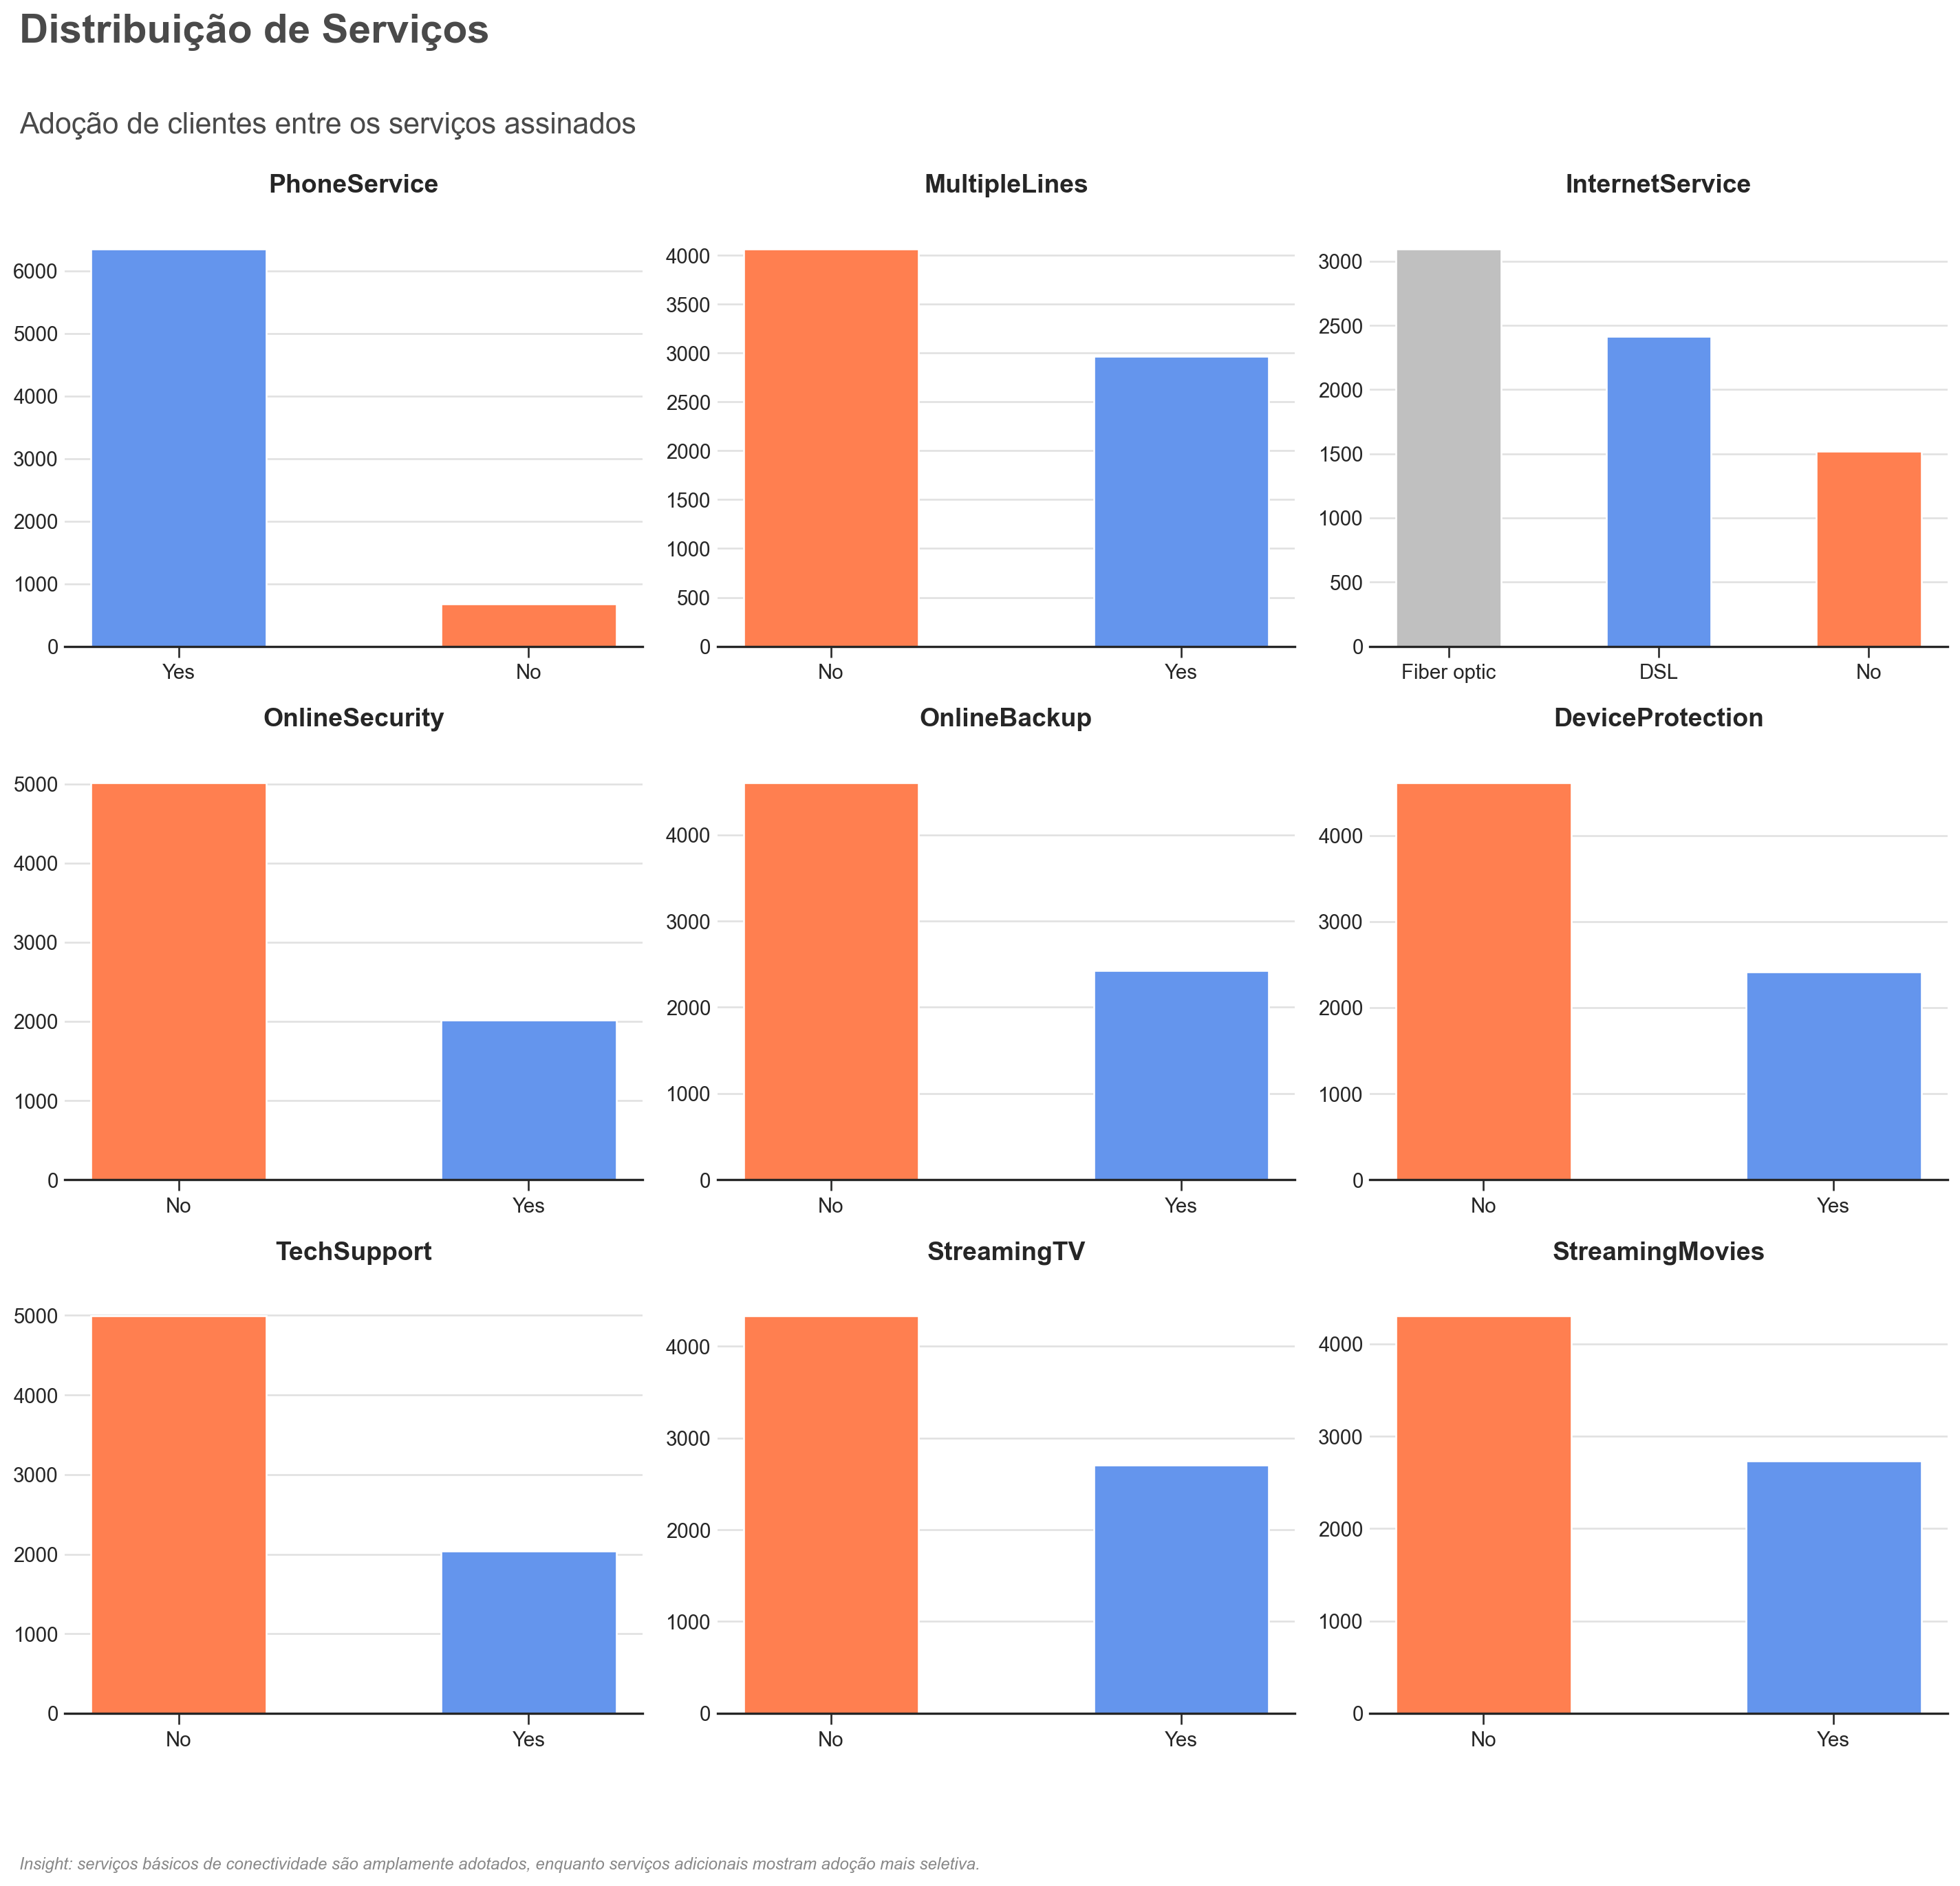

In [16]:
dict_in = lang({
    'title': "Distribuição de Serviços",
    'subtitle': "Adoção de clientes entre os serviços assinados",
    'footer_text': "Insight: serviços básicos de conectividade são amplamente adotados, enquanto serviços adicionais mostram adoção mais seletiva.",
})

plot_services_distribution(
    telecom,
    title=dict_in['title'],
    subtitle=dict_in['subtitle'],
    footer_text=dict_in['footer_text'],
    show_footer=True
)


**Insights:**
- Serviços de conectividade essenciais como `PhoneService`, `MultipleLines` e `InternetService` mostram ampla adoção na base de clientes.
- Serviços de valor agregado como `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV` e `StreamingMovies` são menos uniformemente adotados.
- Essa variação sugere que pacotes de serviços podem ajudar a distinguir perfis de clientes e devem ser examinados posteriormente em relação ao churn.


<span style="color:steelblue; text-align: left">

## Análise Multivariada
</span>

Esta seção examina relações entre variáveis a fim de identificar padrões de dependência, potencial multicolinearidade e associações relevantes para a modelagem de churn.

<span style="color:steelblue; text-align: left">

###  Correlação de Pearson
</span>

A correlação de Pearson é aplicada primeiro às variáveis numéricas para avaliar relações lineares entre elas.


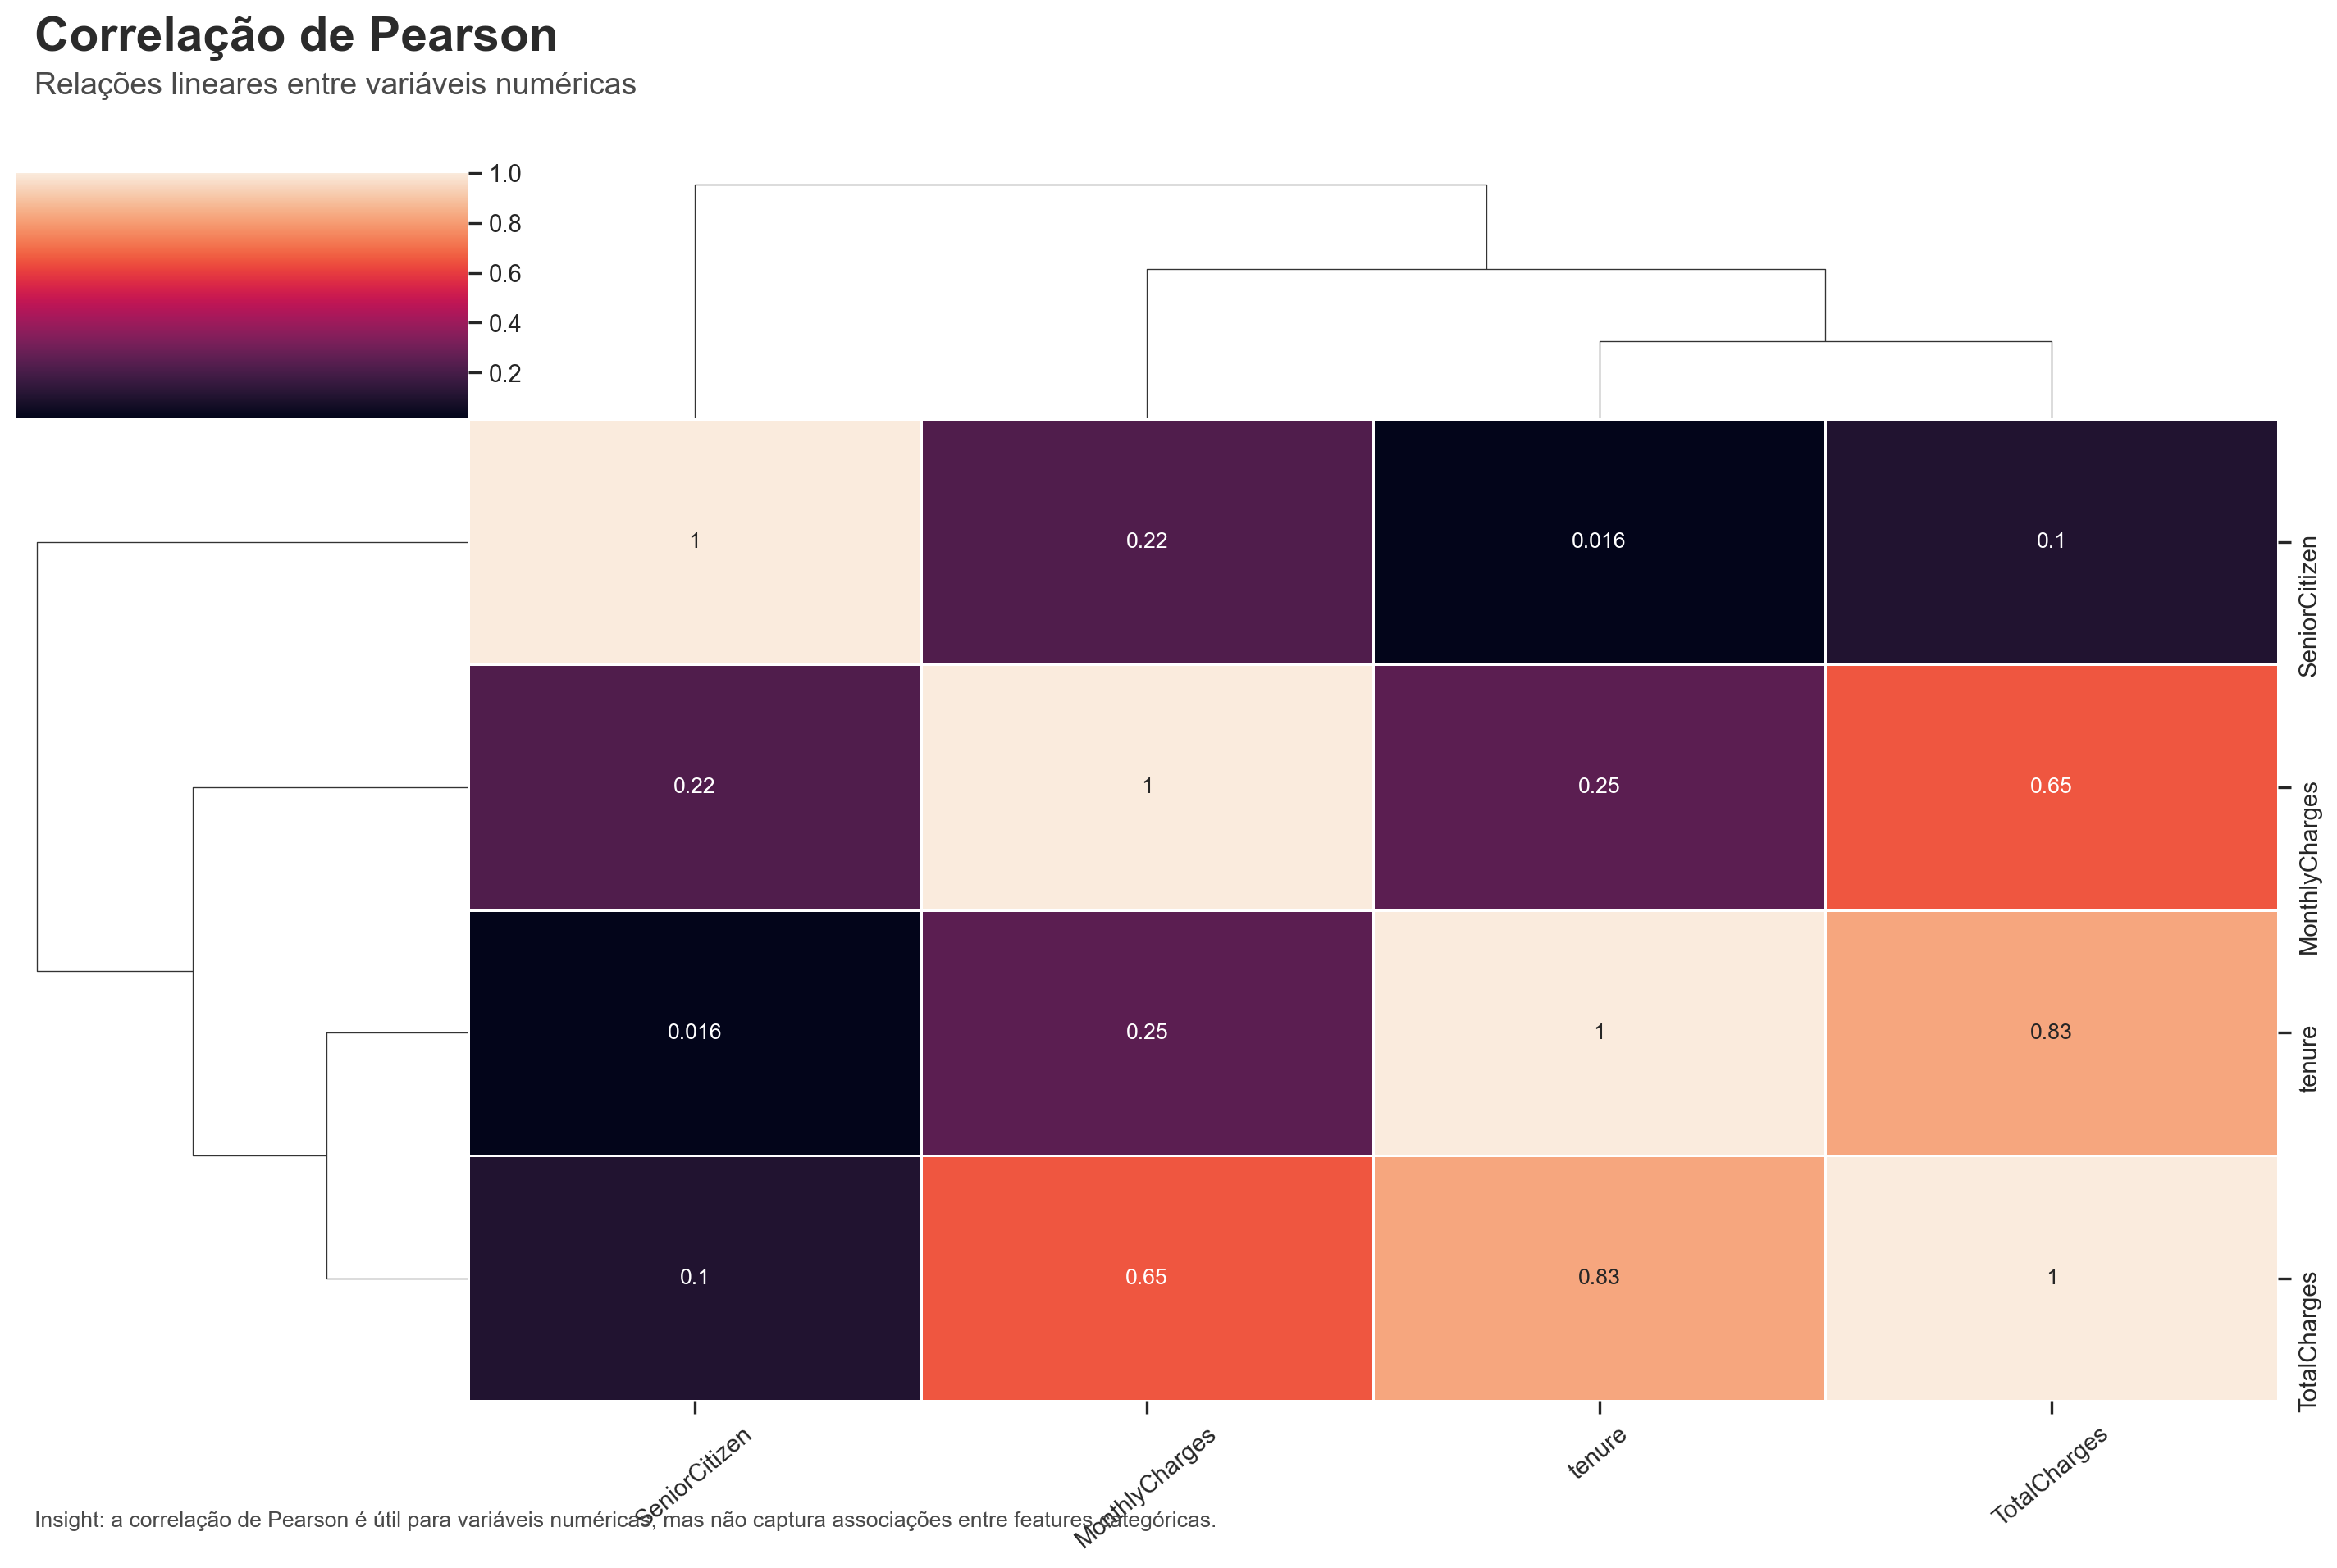

In [17]:
dict_in = lang({
    'title': "Correlação de Pearson",
    'subtitle': "Relações lineares entre variáveis numéricas",
    'footer_text': "Insight: a correlação de Pearson é útil para variáveis numéricas, mas não captura associações entre features categóricas.",
})

pearson_corr = plot_pearson_correlation(
    telecom,
    title=dict_in['title'],
    subtitle=dict_in['subtitle'],
    footer_text=dict_in['footer_text'],
    show_footer=True
)


**Insights:**
- A maioria das variáveis neste dataset são categóricas, portanto a correlação de Pearson fornece apenas uma visão parcial da estrutura de dependência.
- Entre as variáveis numéricas, `tenure` e `TotalCharges` mostram forte correlação positiva, o que é esperado dada a natureza cumulativa da cobrança total.
- `MonthlyCharges` também mostra associação relevante com `TotalCharges`, embora sua relação com outras variáveis seja menos informativa isoladamente.
- Como a correlação de Pearson está limitada a variáveis numéricas e relações lineares, ela não é suficiente para avaliar associações neste dataset de tipo misto.

<span style="color:steelblue; text-align: left">

### Multicolinearidade e Correlação PhiK
</span>

Como este dataset contém um grande número de variáveis categóricas, a correlação de Pearson isolada não é adequada para avaliar a estrutura completa de dependência. Para resolver essa limitação, a correlação PhiK é usada como alternativa mais adequada para dados de tipo misto.

O PhiK é útil neste contexto porque:
- trata variáveis categóricas, ordinais e de intervalo de forma consistente;
- captura relações não lineares;
- é adequado para datasets de tipo misto como este dataset de churn de telecomunicações.


interval columns not set, guessing: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


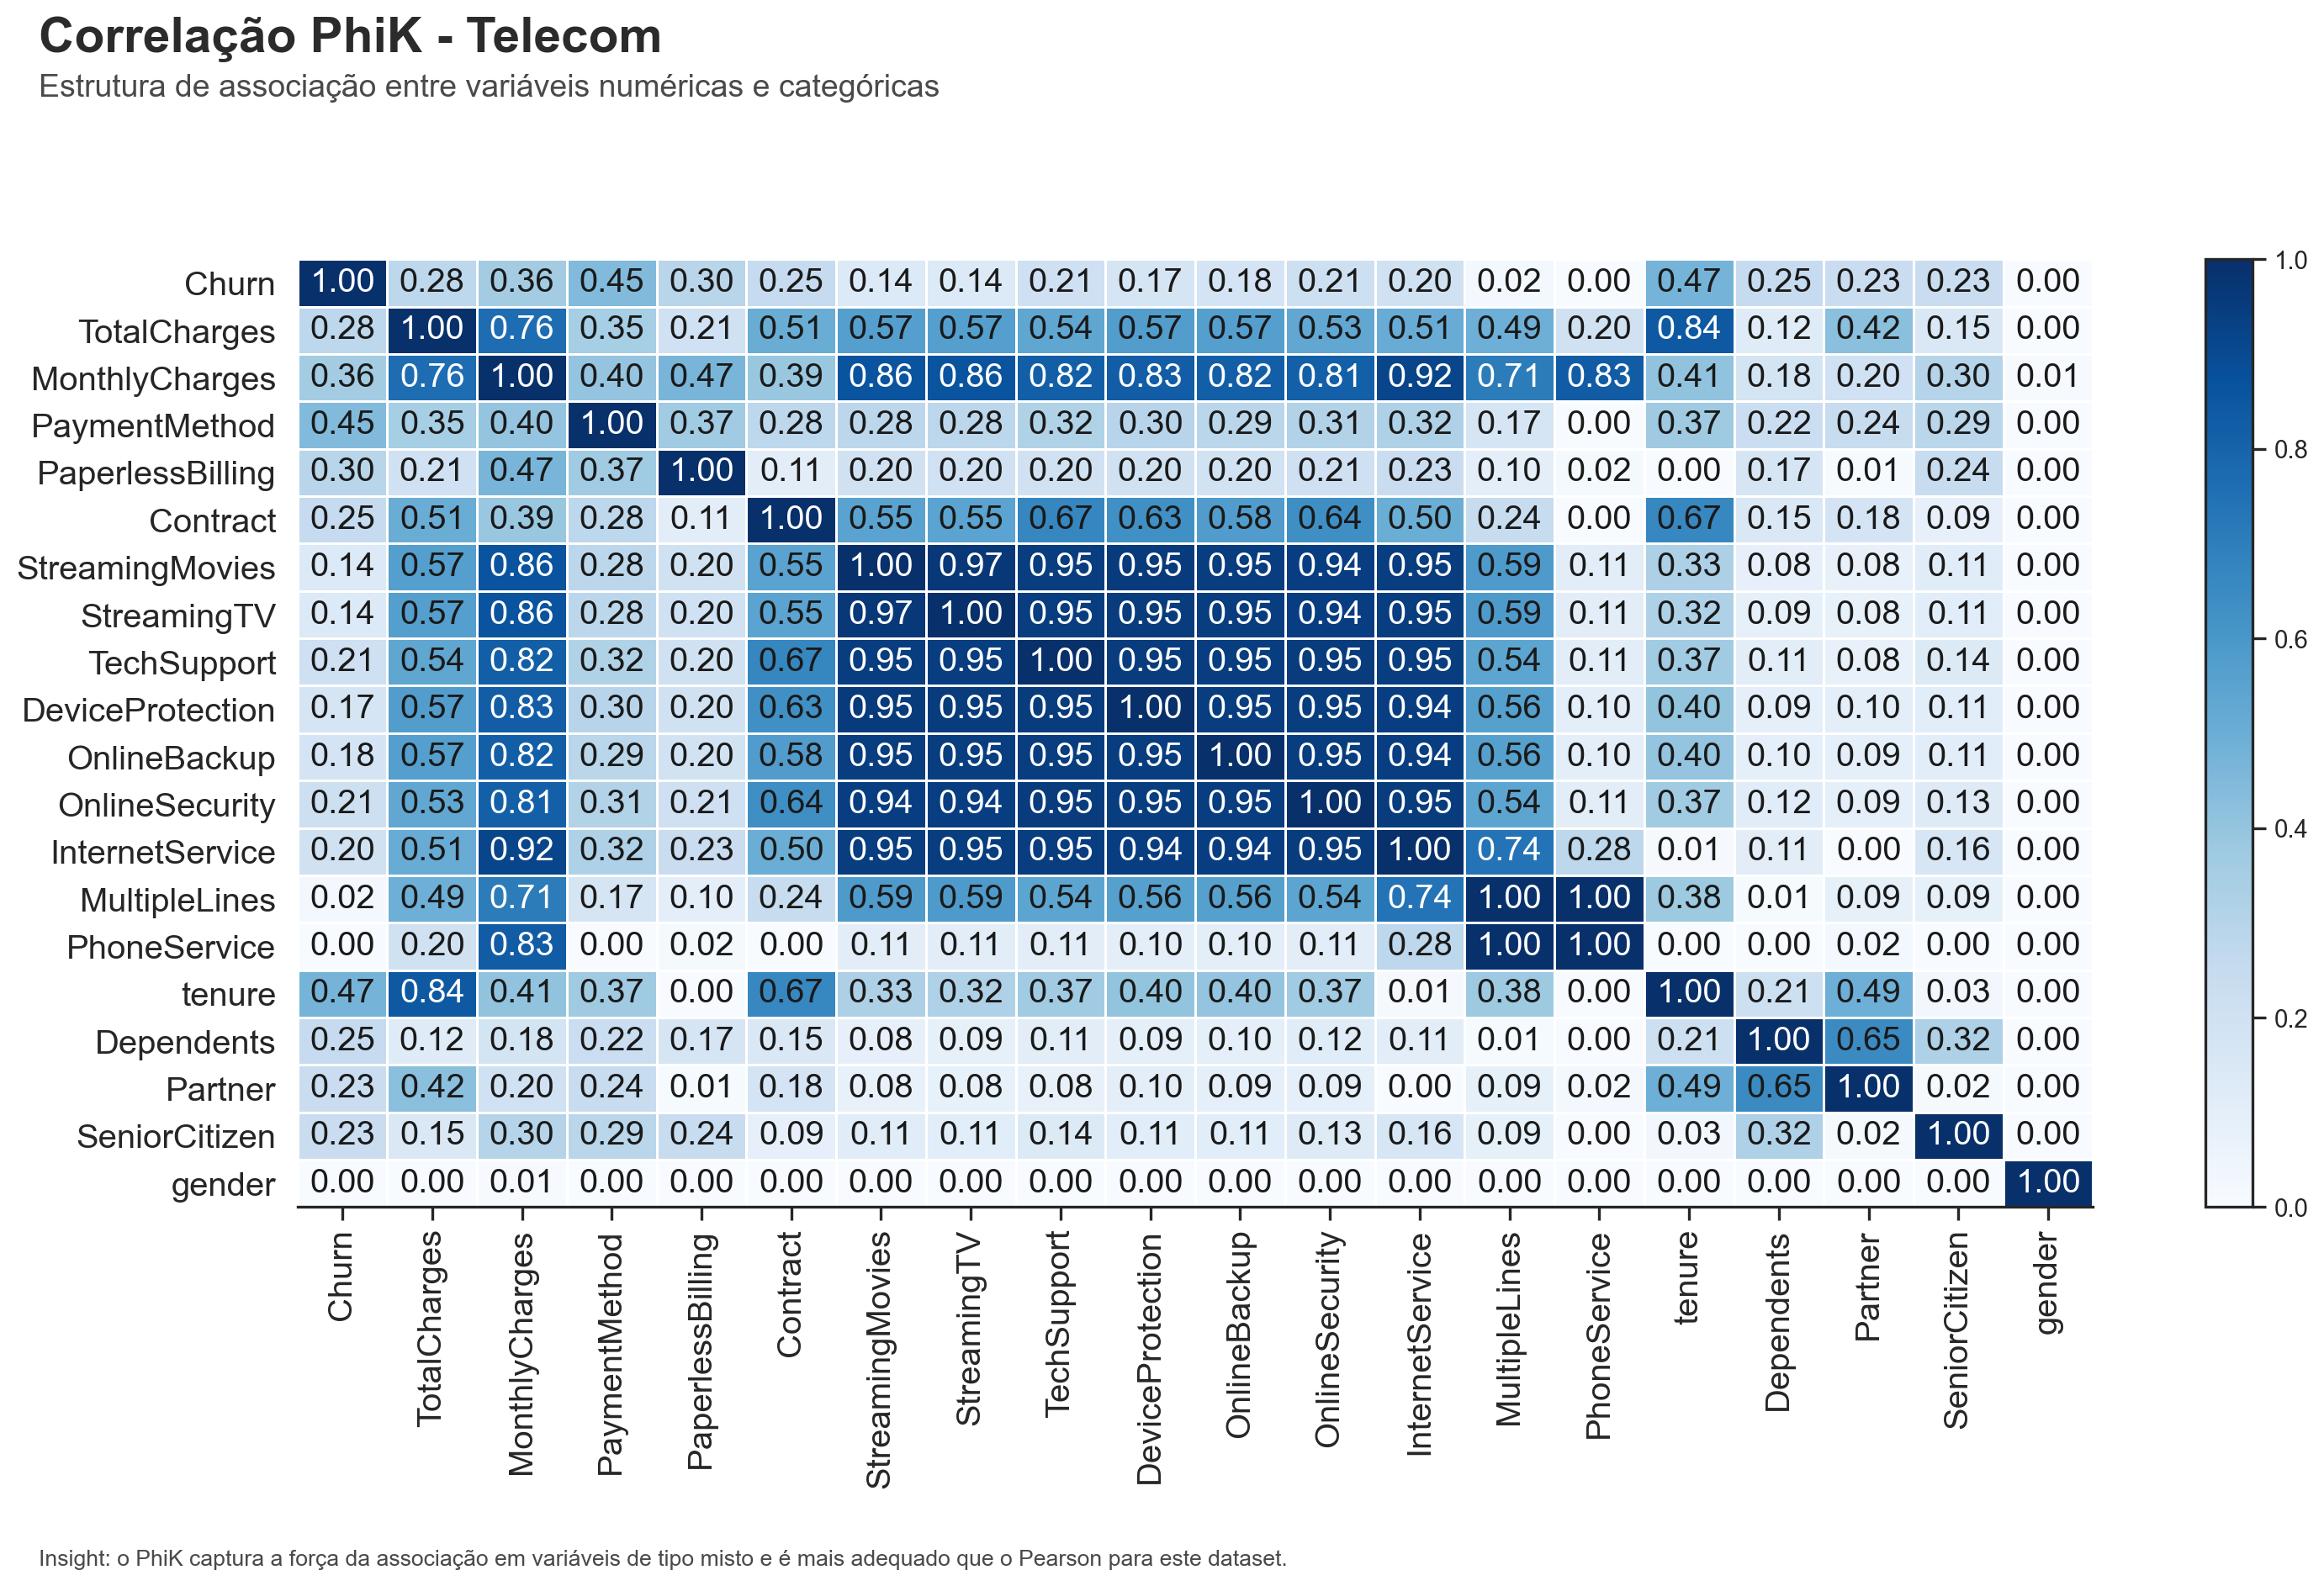

In [18]:
dict_in = lang({
    'title': "Correlação PhiK - Telecom",
    'subtitle': "Estrutura de associação entre variáveis numéricas e categóricas",
    'footer_text': "Insight: o PhiK captura a força da associação em variáveis de tipo misto e é mais adequado que o Pearson para este dataset.",
})

phik_view = plot_phik_correlation(
    telecom,
    drop_cols=['customerID'],
    title=dict_in['title'],
    subtitle=dict_in['subtitle'],
    footer_text=dict_in['footer_text'],
    show_footer=True
)


<span style="color:steelblue; text-align: left">

**Insights:**

</span>

- O PhiK fornece uma visão mais ampla dos padrões de associação entre variáveis numéricas e categóricas.
- Vários pares de variáveis mostram associação moderada a forte, especialmente entre features relacionadas a serviços, cobrança e contratos.
- Os valores PhiK variam de 0 a 1 e medem apenas a força da associação, não a direção.
- Valores próximos de zero indicam associação fraca ou insignificante.


interval columns not set, guessing: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


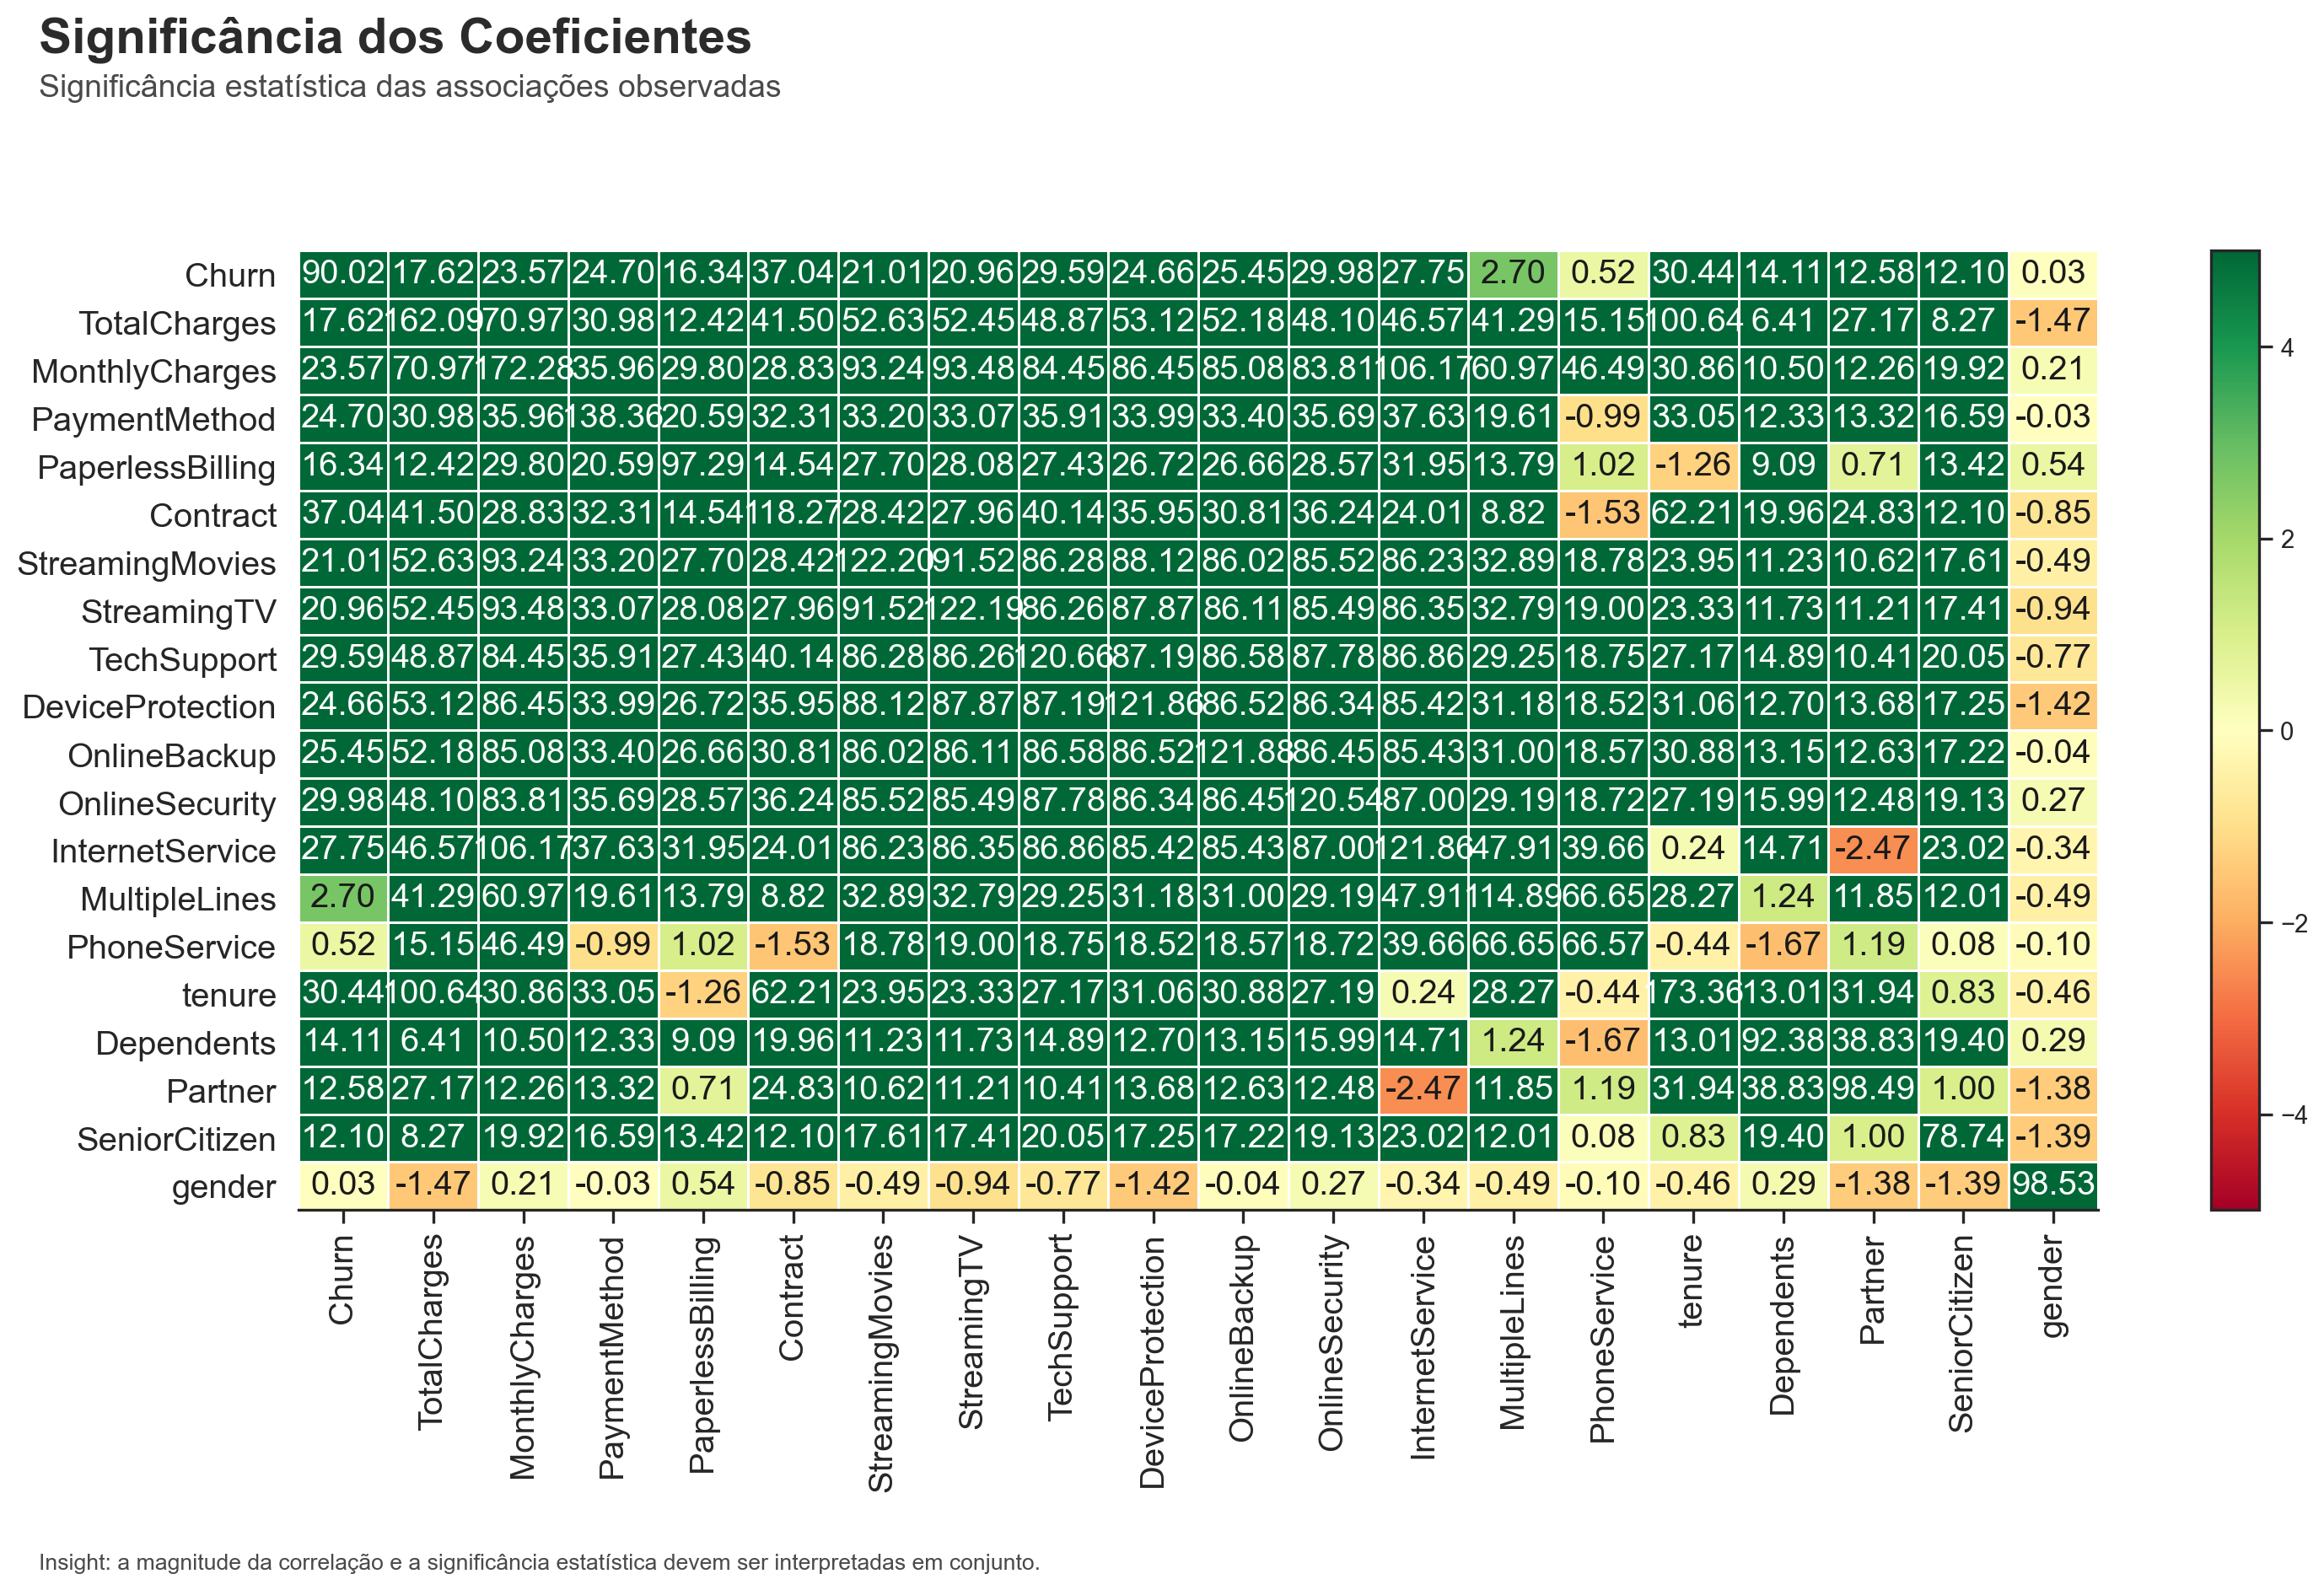

In [19]:
dict_in = lang({
    'title': "Significância dos Coeficientes",
    'subtitle': "Significância estatística das associações observadas",
    'footer_text': "Insight: a magnitude da correlação e a significância estatística devem ser interpretadas em conjunto.",
})

significance_overview = plot_phik_significance(
    telecom,
    drop_cols=['customerID'],
    title=dict_in['title'],
    subtitle=dict_in['subtitle'],
    footer_text=dict_in['footer_text'],
    show_footer=True
)


A matriz de significância complementa a matriz de correlação PhiK mostrando se as associações observadas são estatisticamente significativas.

<span style="color:steelblue; text-align: left">

**Insights:**

</span>

- A força da correlação e a significância estatística devem ser interpretadas em conjunto.
- Uma associação forte pode não ser estatisticamente significativa, enquanto uma mais fraca pode ser altamente significativa.
- Isso ajuda a distinguir padrões de dependência relevantes de ocorrências incidentais.


In [20]:
phik_df = build_phik_significance_df(telecom, drop_cols=['customerID'])
phik_df.head(15).round(4)


interval columns not set, guessing: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
interval columns not set, guessing: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


,var1,var2,phik,significance
85,PhoneService,MultipleLines,1.0000,66.6490
162,StreamingTV,StreamingMovies,0.9654,91.5113
147,DeviceProtection,StreamingMovies,0.9538,88.1254
146,DeviceProtection,StreamingTV,0.9528,87.8716
126,OnlineSecurity,TechSupport,0.9526,87.7783
145,DeviceProtection,TechSupport,0.9502,87.1959
112,InternetService,OnlineSecurity,0.9495,86.9993
115,InternetService,TechSupport,0.9489,86.8639
136,OnlineBackup,TechSupport,0.9477,86.5825
135,OnlineBackup,DeviceProtection,0.9475,86.5207


<span style="color:steelblue; text-align: left">

**Insights**:

</span>

- Dependências fortes são observadas entre variáveis relacionadas à cobrança (MonthlyCharges, TotalCharges, tenure), confirmando a estrutura cumulativa da receita do cliente ao longo do tempo.
- Features relacionadas a serviços (ex.: StreamingTV, StreamingMovies, PhoneService) mostram alta associação com MonthlyCharges, indicando que serviços adicionais são os principais impulsionadores dos gastos dos clientes.
- O tipo de contrato apresenta uma forte relação com tenure, reforçando o papel dos contratos de longo prazo na retenção de clientes.
- Variáveis relacionadas ao domicílio (Partner, Dependents) também são altamente associadas, refletindo o agrupamento demográfico esperado.


In [21]:
relevant_pairs = filter_relevant_relationships(phik_df)
relevant_pairs.head(15).round(4)


,var1,var2,phik,significance
85,PhoneService,MultipleLines,1.0000,66.6490
162,StreamingTV,StreamingMovies,0.9654,91.5113
147,DeviceProtection,StreamingMovies,0.9538,88.1254
146,DeviceProtection,StreamingTV,0.9528,87.8716
126,OnlineSecurity,TechSupport,0.9526,87.7783
145,DeviceProtection,TechSupport,0.9502,87.1959
112,InternetService,OnlineSecurity,0.9495,86.9993
115,InternetService,TechSupport,0.9489,86.8639
136,OnlineBackup,TechSupport,0.9477,86.5825
135,OnlineBackup,DeviceProtection,0.9475,86.5207


Quais variáveis têm relação com o churn?


In [22]:
phik_df[phik_df['var2'] == 'Churn'].sort_values(by='phik', ascending=False)

,var1,var2,phik,significance
84,tenure,Churn,0.473761,30.437486
186,PaymentMethod,Churn,0.448559,24.716313
188,MonthlyCharges,Churn,0.359612,23.578224
183,PaperlessBilling,Churn,0.295194,16.348294
189,TotalCharges,Churn,0.280973,17.622158
69,Dependents,Churn,0.252268,14.096527
179,Contract,Churn,0.251283,37.050797
36,SeniorCitizen,Churn,0.232897,12.097398
53,Partner,Churn,0.232215,12.586217
134,OnlineSecurity,Churn,0.211583,29.985819


Quais variáveis têm relação com o churn?


In [23]:
phik_df[phik_df['var2'] == 'Churn'].sort_values(by='phik', ascending=False)

,var1,var2,phik,significance
84,tenure,Churn,0.473761,30.437486
186,PaymentMethod,Churn,0.448559,24.716313
188,MonthlyCharges,Churn,0.359612,23.578224
183,PaperlessBilling,Churn,0.295194,16.348294
189,TotalCharges,Churn,0.280973,17.622158
69,Dependents,Churn,0.252268,14.096527
179,Contract,Churn,0.251283,37.050797
36,SeniorCitizen,Churn,0.232897,12.097398
53,Partner,Churn,0.232215,12.586217
134,OnlineSecurity,Churn,0.211583,29.985819


**Insights**:
- O tenure do cliente emerge como o principal driver de churn, indicando que clientes na fase inicial são significativamente mais propensos a sair, reforçando a importância das estratégias de onboarding e retenção precoce.
- O método de pagamento mostra forte associação com churn, sugerindo que fricções nos processos de cobrança ou comportamento financeiro podem influenciar a retenção de clientes.
- As cobranças mensais estão positivamente associadas ao churn, indicando que um custo percebido mais alto pode aumentar a probabilidade de perda de clientes.
- O tipo de contrato, apesar de uma correlação moderada, apresenta altíssima significância estatística, destacando sua importância estrutural na retenção de clientes — contratos mais longos provavelmente atuam como mecanismos de retenção.
- Features relacionadas a serviços como OnlineSecurity e TechSupport mostram associação moderada com churn, sugerindo que clientes sem esses serviços podem ser mais vulneráveis a sair.
- Variáveis demográficas (ex.: gênero) não mostram relação significativa com churn, indicando que fatores comportamentais e contratuais dominam sobre características pessoais estáticas.


Onde há multicolinearidade?


In [24]:
phik_df[phik_df['phik'] > 0.7]

,var1,var2,phik,significance
85,PhoneService,MultipleLines,1.000000,66.648972
162,StreamingTV,StreamingMovies,0.965356,91.511312
147,DeviceProtection,StreamingMovies,0.953754,88.125359
146,DeviceProtection,StreamingTV,0.952815,87.871637
126,OnlineSecurity,TechSupport,0.952637,87.778305
145,DeviceProtection,TechSupport,0.950238,87.195885
112,InternetService,OnlineSecurity,0.949461,86.999301
115,InternetService,TechSupport,0.948878,86.863924
136,OnlineBackup,TechSupport,0.947746,86.582491
135,OnlineBackup,DeviceProtection,0.947480,86.520674


**Insights sobre Multicolinearidade**:
- Forte multicolinearidade é observada entre variáveis relacionadas à cobrança (tenure, MonthlyCharges, TotalCharges), refletindo a natureza cumulativa da cobrança dos clientes. Em particular, TotalCharges se comporta como uma feature derivada em vez de um preditor independente.
- Várias features relacionadas a serviços (ex.: StreamingTV, StreamingMovies, PhoneService) mostram alta associação com MonthlyCharges, indicando que o preço do cliente é amplamente determinado pela adoção de pacotes de serviços.
- Alta correlação entre variáveis de serviço (ex.: StreamingTV e StreamingMovies) sugere sobreposição de padrões comportamentais dos clientes, potencialmente introduzindo redundância no espaço de features.
- Essas dependências refletem a lógica de negócio subjacente em vez de relações estatísticas espúrias e devem ser tratadas cuidadosamente durante o desenvolvimento do modelo para evitar redundância e instabilidade.
- Para mitigar efeitos de multicolinearidade em modelos lineares, TotalCharges será excluída do conjunto de features, pois é uma variável derivada.


Relação forte, mas inútil ou redundante?


In [25]:
phik_df[(phik_df['phik'] > 0.8) & (phik_df['significance'] > 50)]

,var1,var2,phik,significance
85,PhoneService,MultipleLines,1.000000,66.648972
162,StreamingTV,StreamingMovies,0.965356,91.511312
147,DeviceProtection,StreamingMovies,0.953754,88.125359
146,DeviceProtection,StreamingTV,0.952815,87.871637
126,OnlineSecurity,TechSupport,0.952637,87.778305
145,DeviceProtection,TechSupport,0.950238,87.195885
112,InternetService,OnlineSecurity,0.949461,86.999301
115,InternetService,TechSupport,0.948878,86.863924
136,OnlineBackup,TechSupport,0.947746,86.582491
135,OnlineBackup,DeviceProtection,0.947480,86.520674


<span style="color:steelblue; text-align: left">

**Relações fortes: redundância vs relevância**:

</span>

- A relação entre tenure e TotalCharges representa uma dependência determinística, pois as cobranças totais são inerentemente uma função do tenure e das cobranças mensais. Portanto, TotalCharges é considerada uma feature redundante e pode ser excluída de modelos lineares.
- A associação entre InternetService e MonthlyCharges reflete a estrutura de preços do negócio, onde o tipo de serviço influencia diretamente a cobrança. Embora altamente correlacionadas, ambas as variáveis capturam aspectos distintos (categoria de serviço vs. custo) e podem ser mantidas dependendo dos objetivos do modelo.
- Features relacionadas a serviços como StreamingTV e StreamingMovies mostram fortes relações com MonthlyCharges, indicando que o preço é amplamente determinado por serviços em pacote. Essas relações representam redundância parcial, pois a adoção de serviços está indiretamente codificada na variável de cobrança.
- Em geral, as altas correlações observadas são principalmente impulsionadas pela lógica de negócio em vez de artefatos estatísticos, e devem ser tratadas seletivamente para equilibrar interpretabilidade e desempenho do modelo.


<span style="color:steelblue; text-align: left">

###  Churn vs Tenure
</span>

O tenure do cliente mostra uma clara relação com o comportamento de churn. Clientes que permanecem com a empresa por períodos mais longos são significativamente menos propensos a realizar churn, enquanto o churn está predominantemente concentrado entre clientes com tenure mais curto.

Esse padrão sugere que os estágios iniciais do ciclo de vida do cliente são críticos para a retenção, destacando a importância das estratégias de onboarding e engajamento inicial.


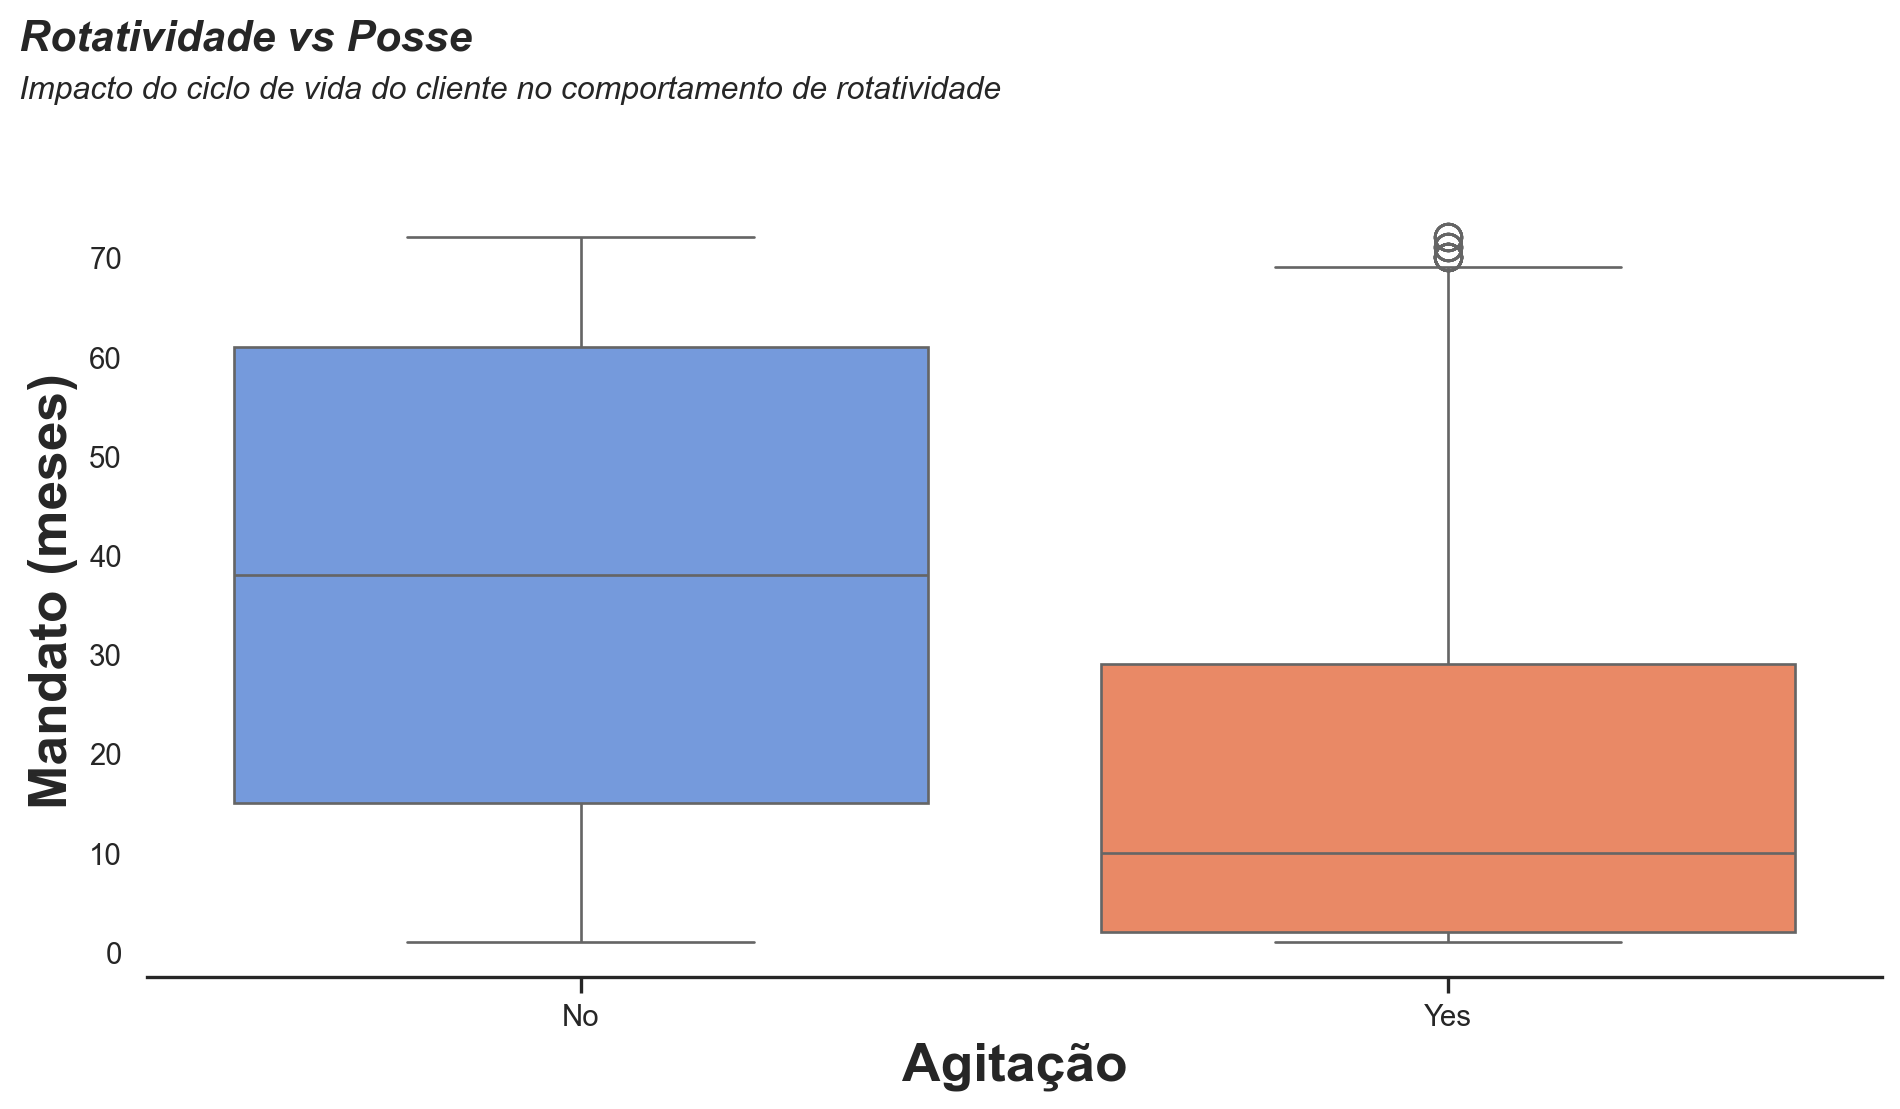

phik         = 0.4709
significance = 29.0537


In [26]:
plot_churn_vs_tenure(telecom)


<span style="color:steelblue; text-align: left">

**Insights:**

</span>

- Clientes com tenure mais curto apresentam taxas de churn significativamente mais altas, indicando que o risco de churn está concentrado nas fases iniciais do ciclo de vida.
- Clientes que permanecem por mais tempo tendem a se estabilizar e são menos propensos a sair, sugerindo um forte efeito de retenção ao longo do tempo.
- O tenure emerge como um dos preditores mais fortes de churn, reforçando sua importância na modelagem posterior.

<span style="color:steelblue; text-align: left">

###  Churn vs Contrato
</span>

Churn por Tipo de Contrato: semelhante ao que vimos no gráfico de correlação, os clientes com contrato mensal têm uma taxa de churn muito alta.


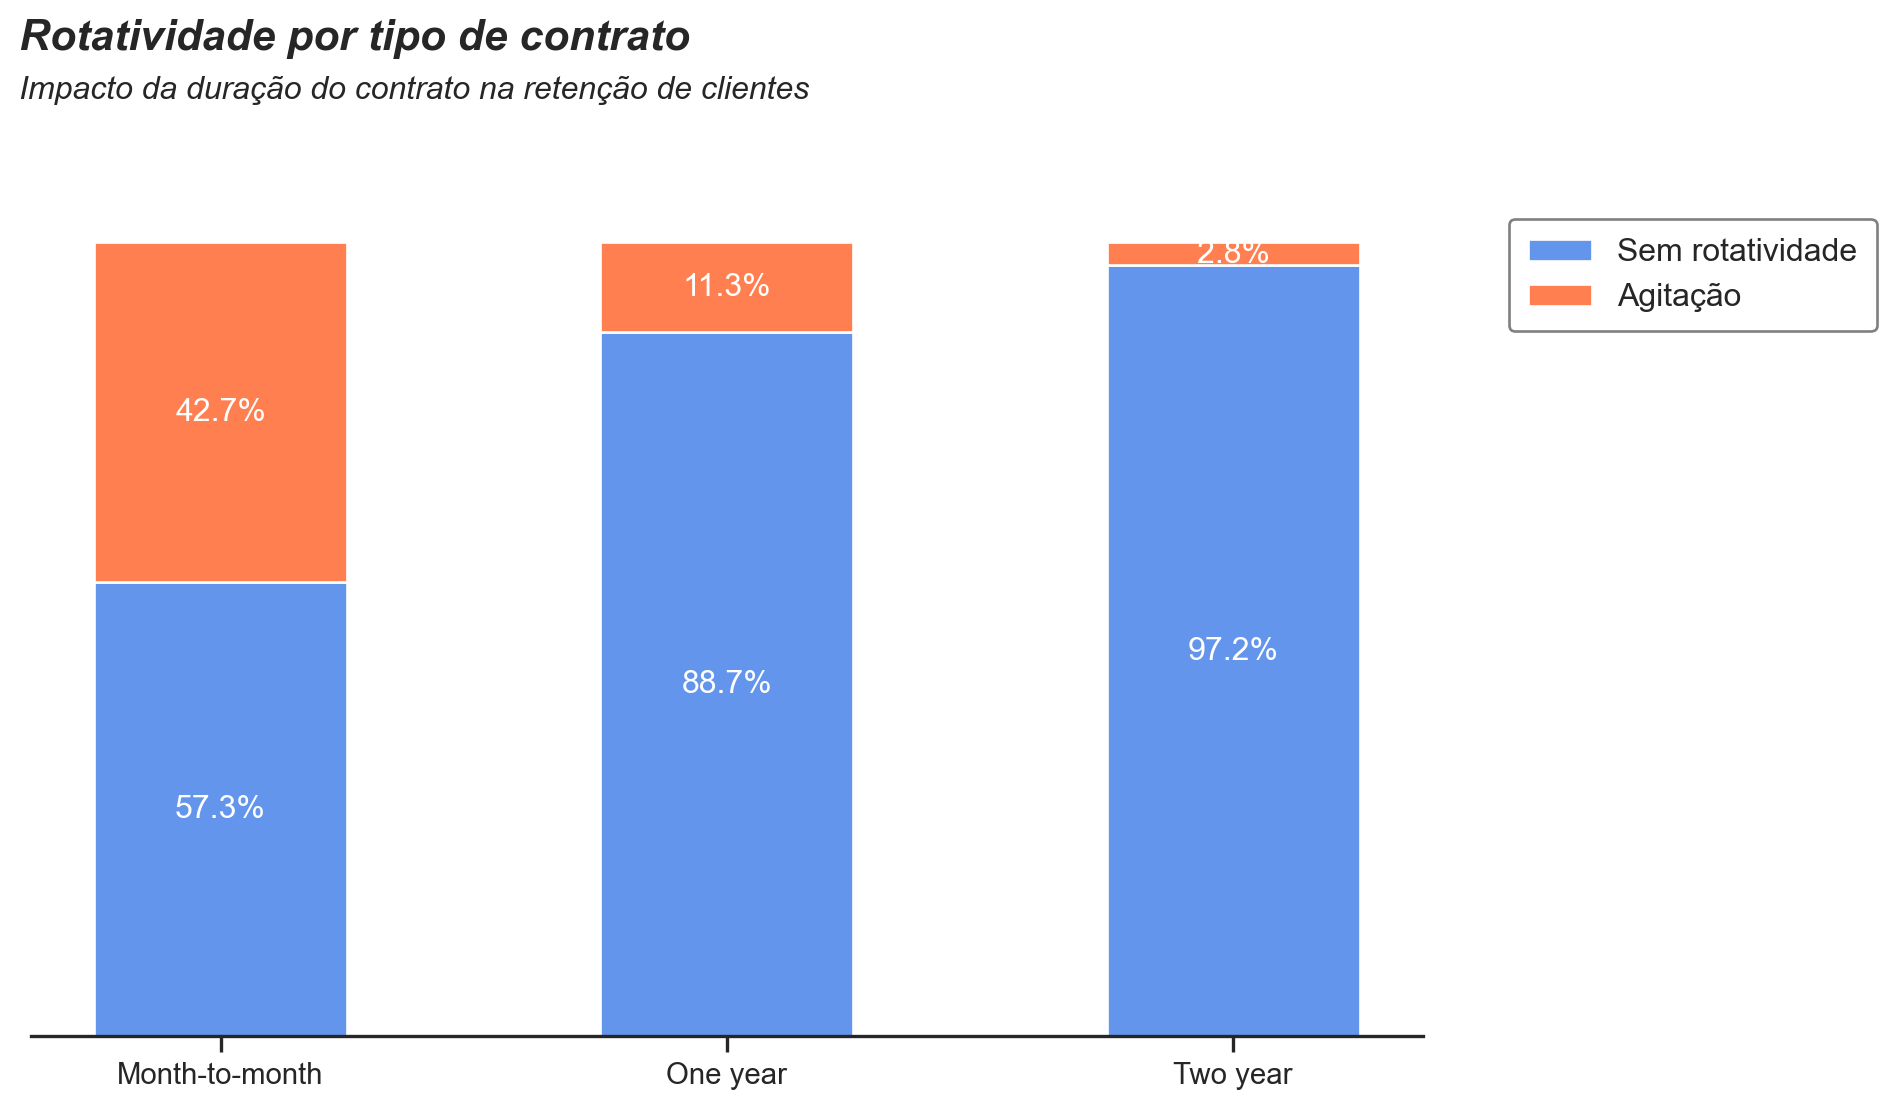

phik         = 0.2513
significance = 37.0308


In [27]:
plot_churn_vs_contract(telecom)


<span style="color:steelblue; text-align: left">

**Insights:**

</span>

- Clientes com contratos mensais apresentam churn extremamente alto (~43%), indicando baixo comprometimento e alta flexibilidade de mudança.
- Migrar de contratos mensais para contratos de um ano reduz o churn em ~3,8x, enquanto contratos de dois anos reduzem em ~15x.
- Isso demonstra uma forte relação não linear entre duração do contrato e retenção, onde comprometimentos mais longos atuam como um poderoso mecanismo de retenção.
- O tipo de contrato não está apenas correlacionado com o churn — ele está estruturalmente vinculado à estabilidade do ciclo de vida do cliente.


<span style="color:steelblue; text-align: left">

###  Churn vs Cobranças Mensais
</span>


Clientes com cobranças mensais mais altas apresentam maior propensão ao churn.

Para entender melhor o comportamento distribucional, analisamos assimetria e curtose:

- **Assimetria** mede a simetria:
  - Positiva: cauda direita (valores mais altos)
  - Negativa: cauda esquerda (valores mais baixos)
  - Próxima de zero: distribuição simétrica

- **Curtose** mede o peso das caudas em relação a uma distribuição normal:
  - < 3: Platicúrtica (caudas mais leves, menos outliers)
  - = 3: Mesocúrtica (similar à normal)
  - > 3: Leptocúrtica (caudas mais pesadas, mais valores extremos)

Esta análise ajuda a avaliar se as diferenças de churn são impulsionadas por mudanças estruturais ou pela forma distribucional.


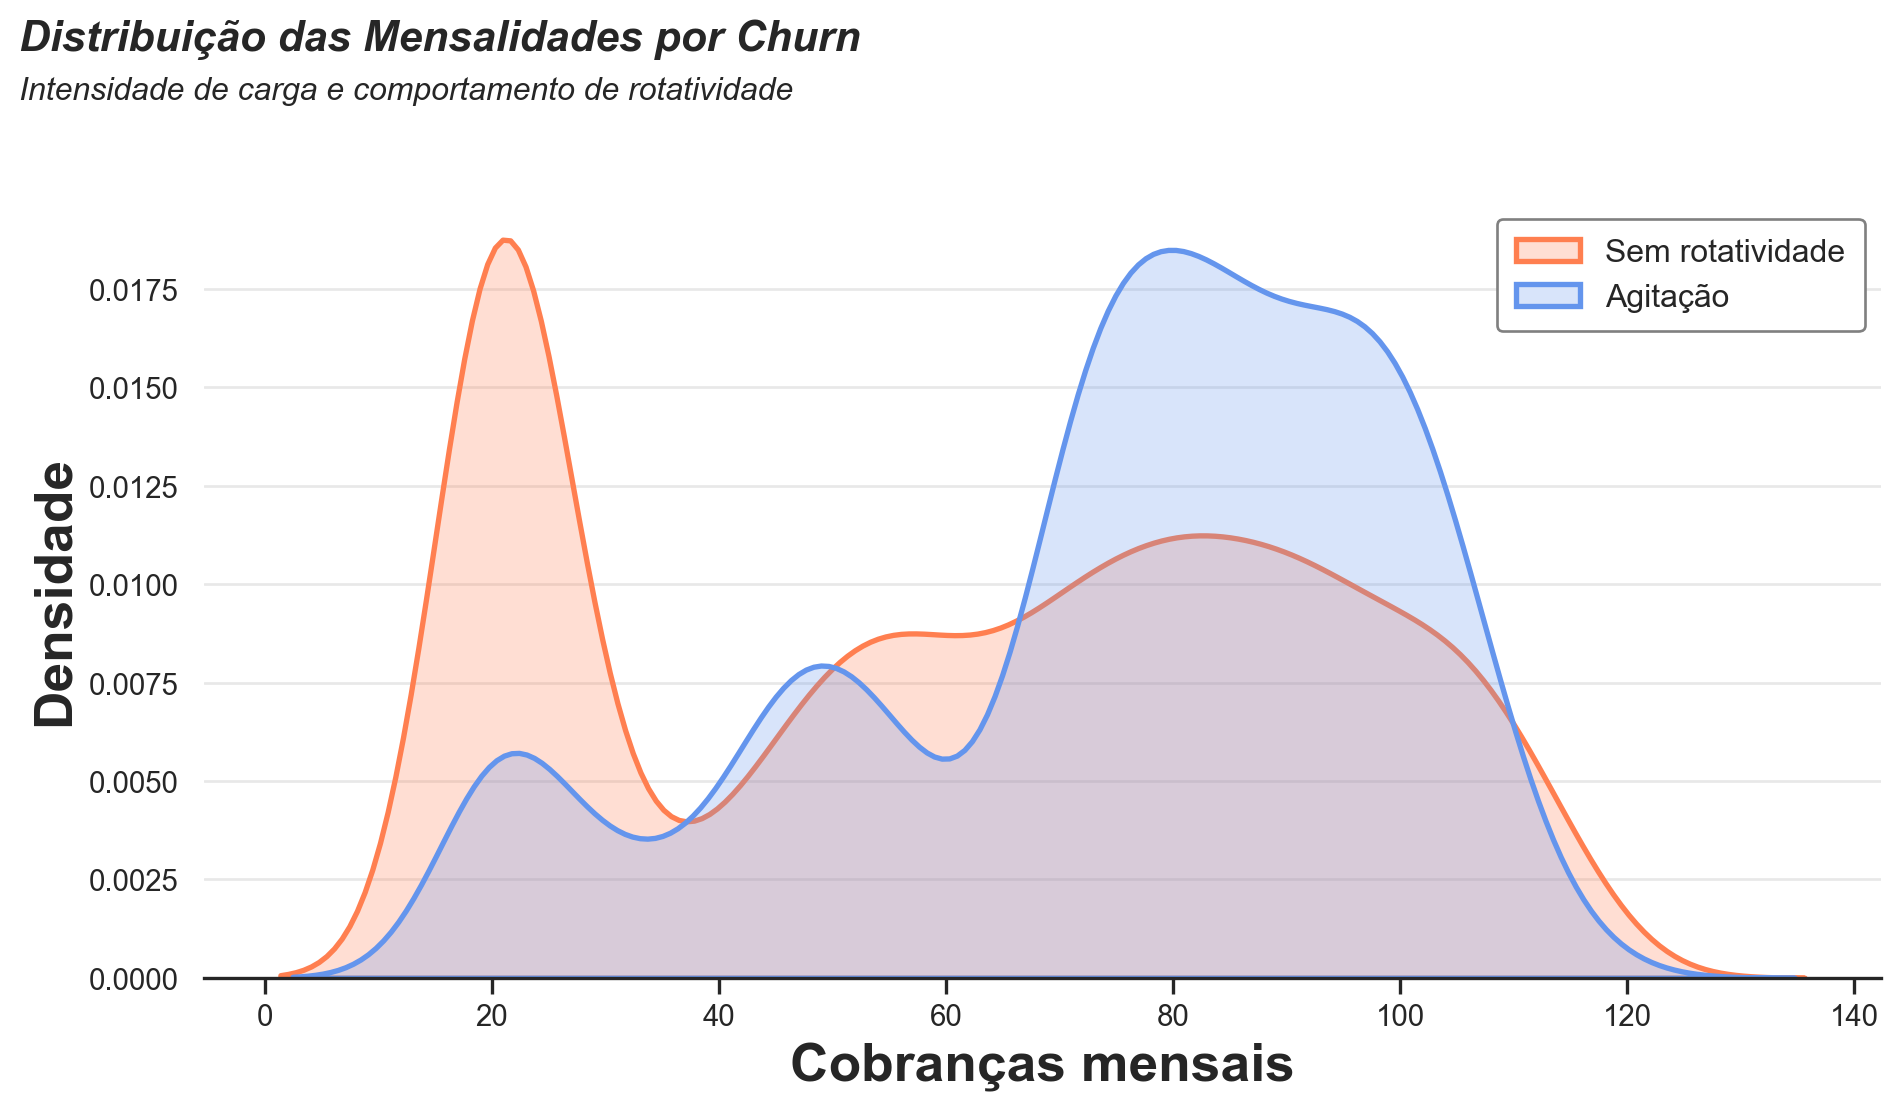


No Churn Distribution
  Skewness : -0.0268 (approximately symmetric)
  Kurtosis : -1.3552 (platykurtic)

Churn Distribution
  Skewness : -0.7294 (moderately skewed)
  Kurtosis : -0.3615 (platykurtic)

phik         = 0.3923
significance = 12.2239


In [28]:
plot_churn_vs_monthly_charges(telecom)


<span style="color:steelblue; text-align: left">

**Insights:**

</span>

- Clientes que realizam churn estão desproporcionalmente concentrados em faixas de cobranças mensais mais altas, indicando sensibilidade ao preço como principal driver de perda.
- A distribuição de churn é mais assimétrica à esquerda, sugerindo uma maior concentração de clientes de alto valor saindo do serviço.
- Tanto o grupo de churn quanto o de não-churn exibem comportamento platicúrtico, indicando distribuições relativamente estáveis com poucos outliers extremos.
- A correlação PhiK (~0,39) indica uma relação moderada e estatisticamente significativa, reforçando que o preço desempenha um papel importante — mas não dominante — no comportamento de churn.
- Ao contrário do tipo de contrato (driver estrutural), as cobranças mensais atuam como uma **variável de pressão comportamental**, influenciando a probabilidade de churn dentro dos segmentos.


<span style="color:steelblue; text-align: left">

### Resumo da AED

</span>

O dataset apresenta uma distribuição de gênero bem equilibrada, sem diferenças observáveis de comportamento entre clientes masculinos e femininos. A população é predominantemente composta por indivíduos mais jovens, pois apenas uma pequena proporção corresponde a idosos. Os padrões de relacionamento indicam uma estrutura consistente na base de clientes: indivíduos sem parceiros são muito improváveis de ter dependentes, enquanto aqueles com parceiros estão mais igualmente divididos. Esses padrões permanecem estáveis entre gêneros, sugerindo que as variáveis demográficas têm poder explicativo limitado isoladamente.

Do ponto de vista do ciclo de vida, a distribuição de tenure revela dois grupos distintos de clientes: uma grande concentração de clientes com menos de um ano de serviço e outro grupo com relacionamentos de longo prazo, tipicamente em torno de cinco a seis anos. Esse comportamento dual não é aleatório e é fortemente influenciado pela estrutura contratual. Clientes em contratos mais longos tendem a permanecer significativamente mais tempo, indicando que **a duração do contrato atua como um mecanismo estrutural de retenção**.

O tipo de contrato emerge como uma das variáveis mais relevantes do dataset. A maioria dos clientes está inscrita em acordos mensais, que oferecem flexibilidade, mas também expõem a empresa a maior churn. Em contraste, contratos de um e dois anos estão associados a maior estabilidade e tenure mais longo. Isso reforça a ideia de que **o comprometimento do cliente é um driver essencial de retenção**.

As variáveis financeiras acrescentam outra dimensão crítica à análise. Cobranças mensais mais altas estão associadas a maior probabilidade de churn, mas essa relação não é isolada. O efeito se torna mais pronunciado quando combinado com o tipo de contrato. Clientes que estão tanto em contratos flexíveis quanto expostos a custos mensais mais altos representam o segmento mais vulnerável. Nesse contexto, **o churn é melhor explicado pela interação entre baixo comprometimento e alta pressão financeira**, em vez de por qualquer fator isolado.

A análise estatística usando correlação PhiK suporta essas descobertas. Variáveis como **Contract**, **tenure** e **MonthlyCharges** mostram a associação mais forte com churn, enquanto várias features relacionadas a serviços (ex.: PhoneService, StreamingTV, StreamingMovies, MultipleLines) exibem relações fracas e provavelmente contribuirão menos para o desempenho preditivo. Isso indica que **variáveis comportamentais e estruturais superam as features de adoção de serviços na explicação do churn**.

Além disso, o dataset está desbalanceado, com uma clara maioria de clientes não realizando churn. Isso tem implicações diretas para a modelagem, pois pode enviesar previsões em direção à classe majoritária se não tratado adequadamente. Por fim, uma pequena porção dos dados contém inconsistências ou valores ausentes, mas dada sua dimensão limitada, não justifica remoção e pode ser mantida sem comprometer a análise.

Em geral, a análise indica que um modelo preditivo bem calibrado, alinhado com os objetivos de negócio, pode gerar retornos financeiros substanciais e apoiar a tomada de decisão estratégica.


<span style="color:steelblue; text-align: left">

### Teste Qui-Quadrado (χ²)
</span>

O teste Qui-Quadrado é usado para avaliar se há uma associação estatisticamente significativa entre variáveis categóricas e a variável alvo.

Neste contexto, serve como uma etapa de validação para quantificar quão fortemente cada feature categórica está associada ao churn, com base nas frequências observadas versus esperadas.

Em vez de descobrir novas relações, este teste confirma padrões já identificados durante a análise exploratória e de correlação PhiK.


In [29]:
import pandas as pd
import numpy as np
import sklearn
import optuna
import phik
import shap
import xgboost
import lightgbm
import imblearn
import seaborn as sns
import matplotlib.pyplot as plt

print("Ambiente OK")


Ambiente OK


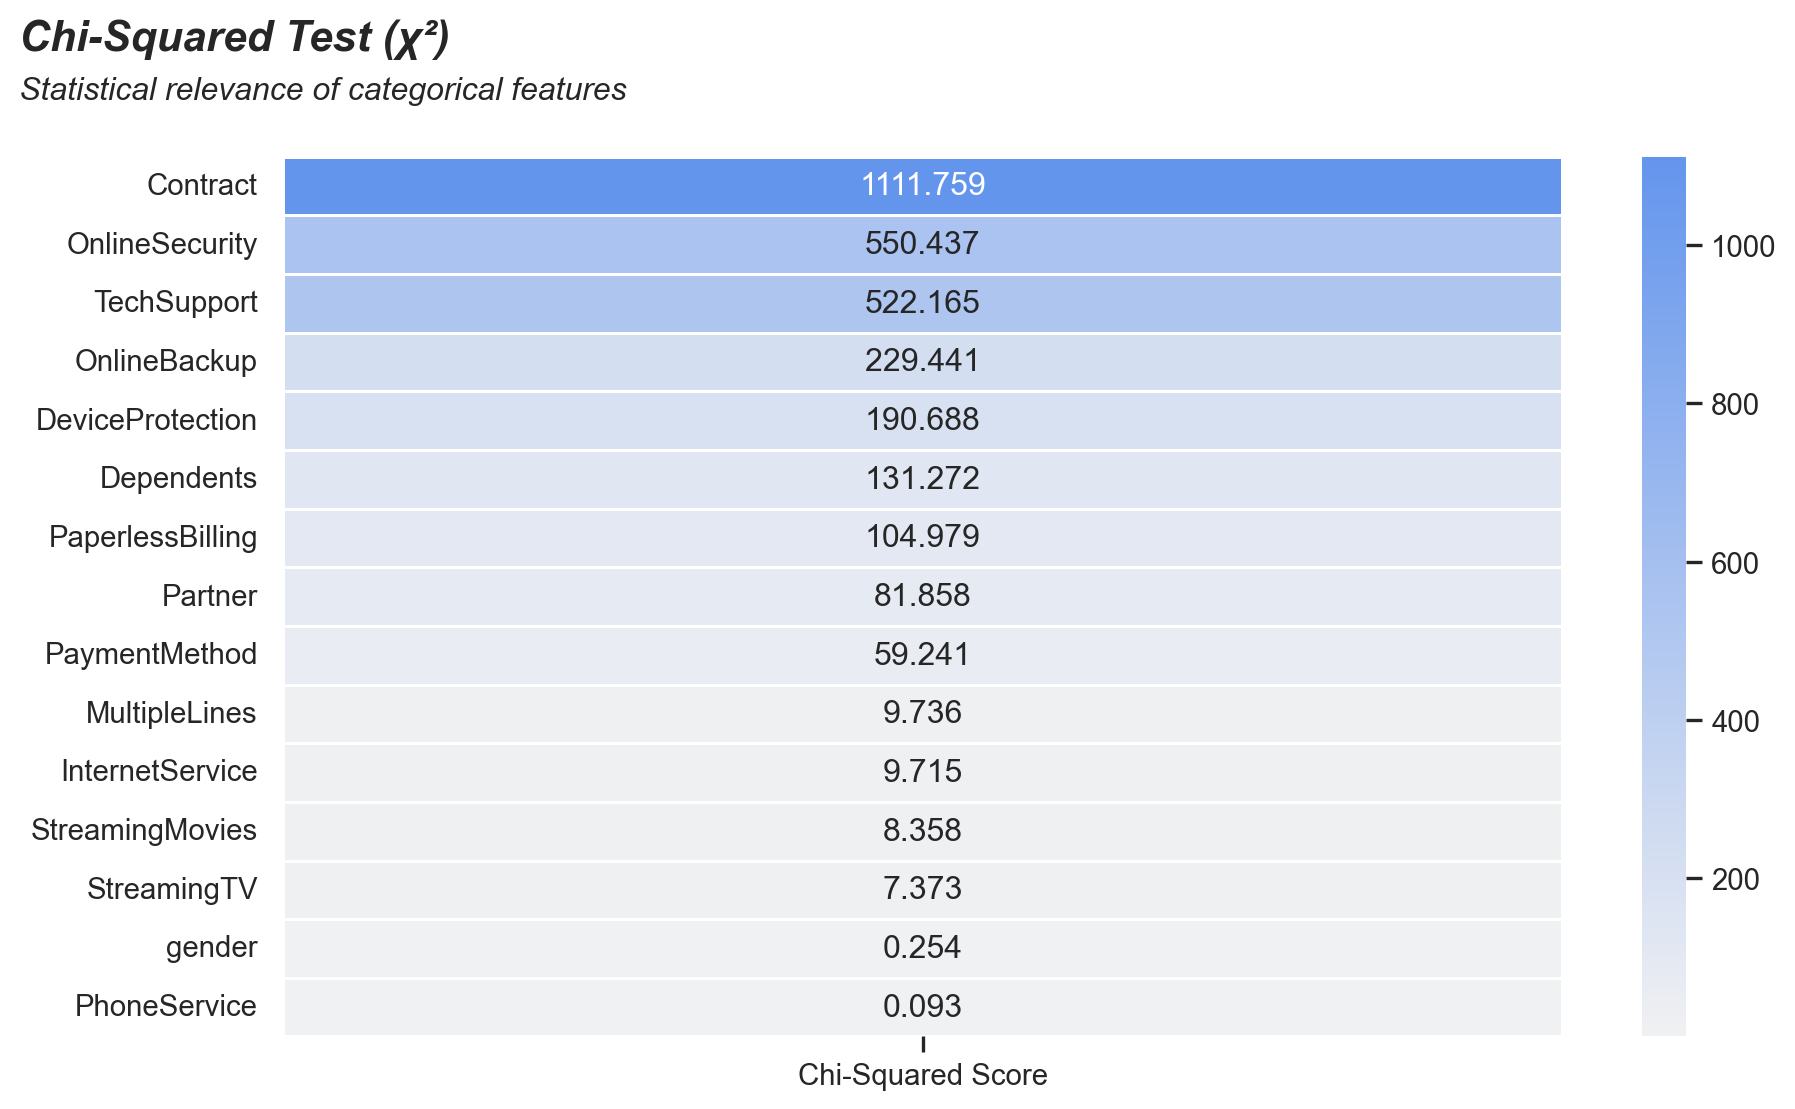

,Chi-Squared Score
Contract,1111.759054
OnlineSecurity,550.437364
TechSupport,522.164716
OnlineBackup,229.441123
DeviceProtection,190.688004
Dependents,131.271509
PaperlessBilling,104.979224
Partner,81.857769
PaymentMethod,59.240507
MultipleLines,9.735960


In [30]:
chi2_scores = plot_chi_squared_feature_selection(telecom)
chi2_scores

<span style="color:steelblue; text-align: left">

**Insights:**

</span>

As features categóricas mostram uma hierarquia clara de importância:

- **Contract** se destaca como a variável mais influente com grande margem, reforçando seu papel como principal driver de churn.
- **OnlineSecurity**, **TechSupport** e **Dependents** também exibem associações fortes, indicando que o suporte a serviços e a estrutura familiar impactam a retenção.
- Features como **PhoneService**, **gender**, **StreamingTV**, **StreamingMovies** e **MultipleLines** mostram associação mínima com churn e provavelmente contribuirão pouco para o desempenho preditivo.

Em geral, o teste confirma que **variáveis estruturais e relacionadas a suporte são mais relevantes do que features básicas de uso de serviços**.

<span style="color:steelblue; text-align: left">

### Teste ANOVA
</span>

A ANOVA (Análise de Variância) é usada para avaliar se as features numéricas apresentam diferenças estatisticamente significativas em suas médias entre os grupos de churn.

Neste caso, ajuda a quantificar quão fortemente as variáveis numéricas diferenciam clientes que realizam churn daqueles que permanecem.

Semelhante ao teste Qui-Quadrado, a ANOVA atua como uma camada de validação em vez de uma ferramenta de descoberta, reforçando padrões observados anteriormente nos dados.


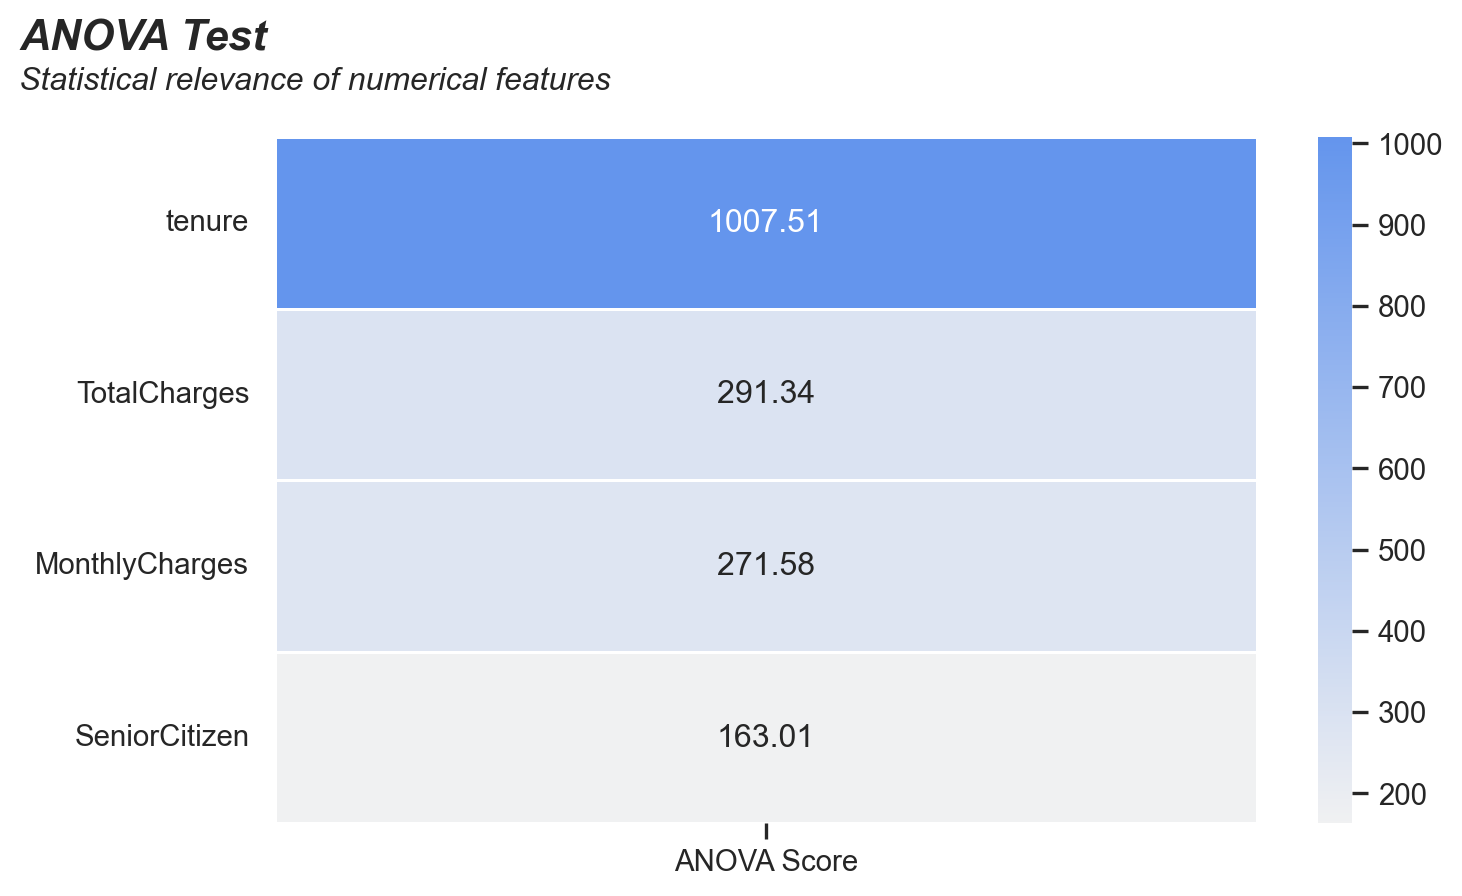

,ANOVA Score
tenure,1007.509431
TotalCharges,291.344862
MonthlyCharges,271.576990
SeniorCitizen,163.012426


In [31]:
anova_scores = plot_anova_feature_selection(telecom)
anova_scores

<span style="color:steelblue; text-align: left">

**Insights:**

</span>

- **tenure** é a variável numérica mais discriminativa, indicando que o tempo de vida do cliente é um fator chave no comportamento de churn.
- **TotalCharges** e **MonthlyCharges** também mostram relevância estatística forte, confirmando que as variáveis financeiras desempenham um papel significativo.

No entanto, dada a relação conhecida:

> **TotalCharges ≈ MonthlyCharges × tenure**

existe clara multicolinearidade entre essas variáveis.

Isso sugere que:
- Incluir todas elas pode introduzir redundância
- Estratégias de engenharia ou seleção de features devem ser aplicadas para evitar informação duplicada

Em geral, os resultados confirmam que **o tempo de vida do cliente e a exposição financeira são centrais para explicar o churn**.


<span style="color:steelblue; text-align: left">

## Validação de Premissas Estatísticas
</span>

Antes de construir modelos preditivos, é boa prática verificar as propriedades estatísticas dos dados. Esta seção executa cinco testes formais que avaliam:

1. **Normalidade** das features contínuas (teste de Shapiro-Wilk + gráficos Q-Q)
2. **Multicolinearidade** entre variáveis numéricas (Fator de Inflação da Variância — VIF)
3. **Balanceamento de classes** e razão de desbalanceamento
4. **Independência feature-alvo** para features categóricas (teste Qui-Quadrado)
5. **Homocedasticidade** entre grupos de churn (teste de Levene em MonthlyCharges)

Esses testes informam e validam as decisões de pré-processamento feitas no pipeline de modelagem: `PowerTransformer` para não-normalidade, `RFE` para multicolinearidade e `class_weight='balanced'` para desbalanceamento de classes.


=== 1. Teste de Normalidade Shapiro-Wilk ===


,Feature,W-statistic,p-value,Normal (p>0.05)?
0,tenure,0.9034,1.27e-48,Não — rejeitar H0
1,MonthlyCharges,0.9221,4.30e-45,Não — rejeitar H0
2,TotalCharges,0.8622,9.24e-55,Não — rejeitar H0


Todas as features contínuas são NÃO NORMAIS (p < 0,05) -> PowerTransformer é justificado.



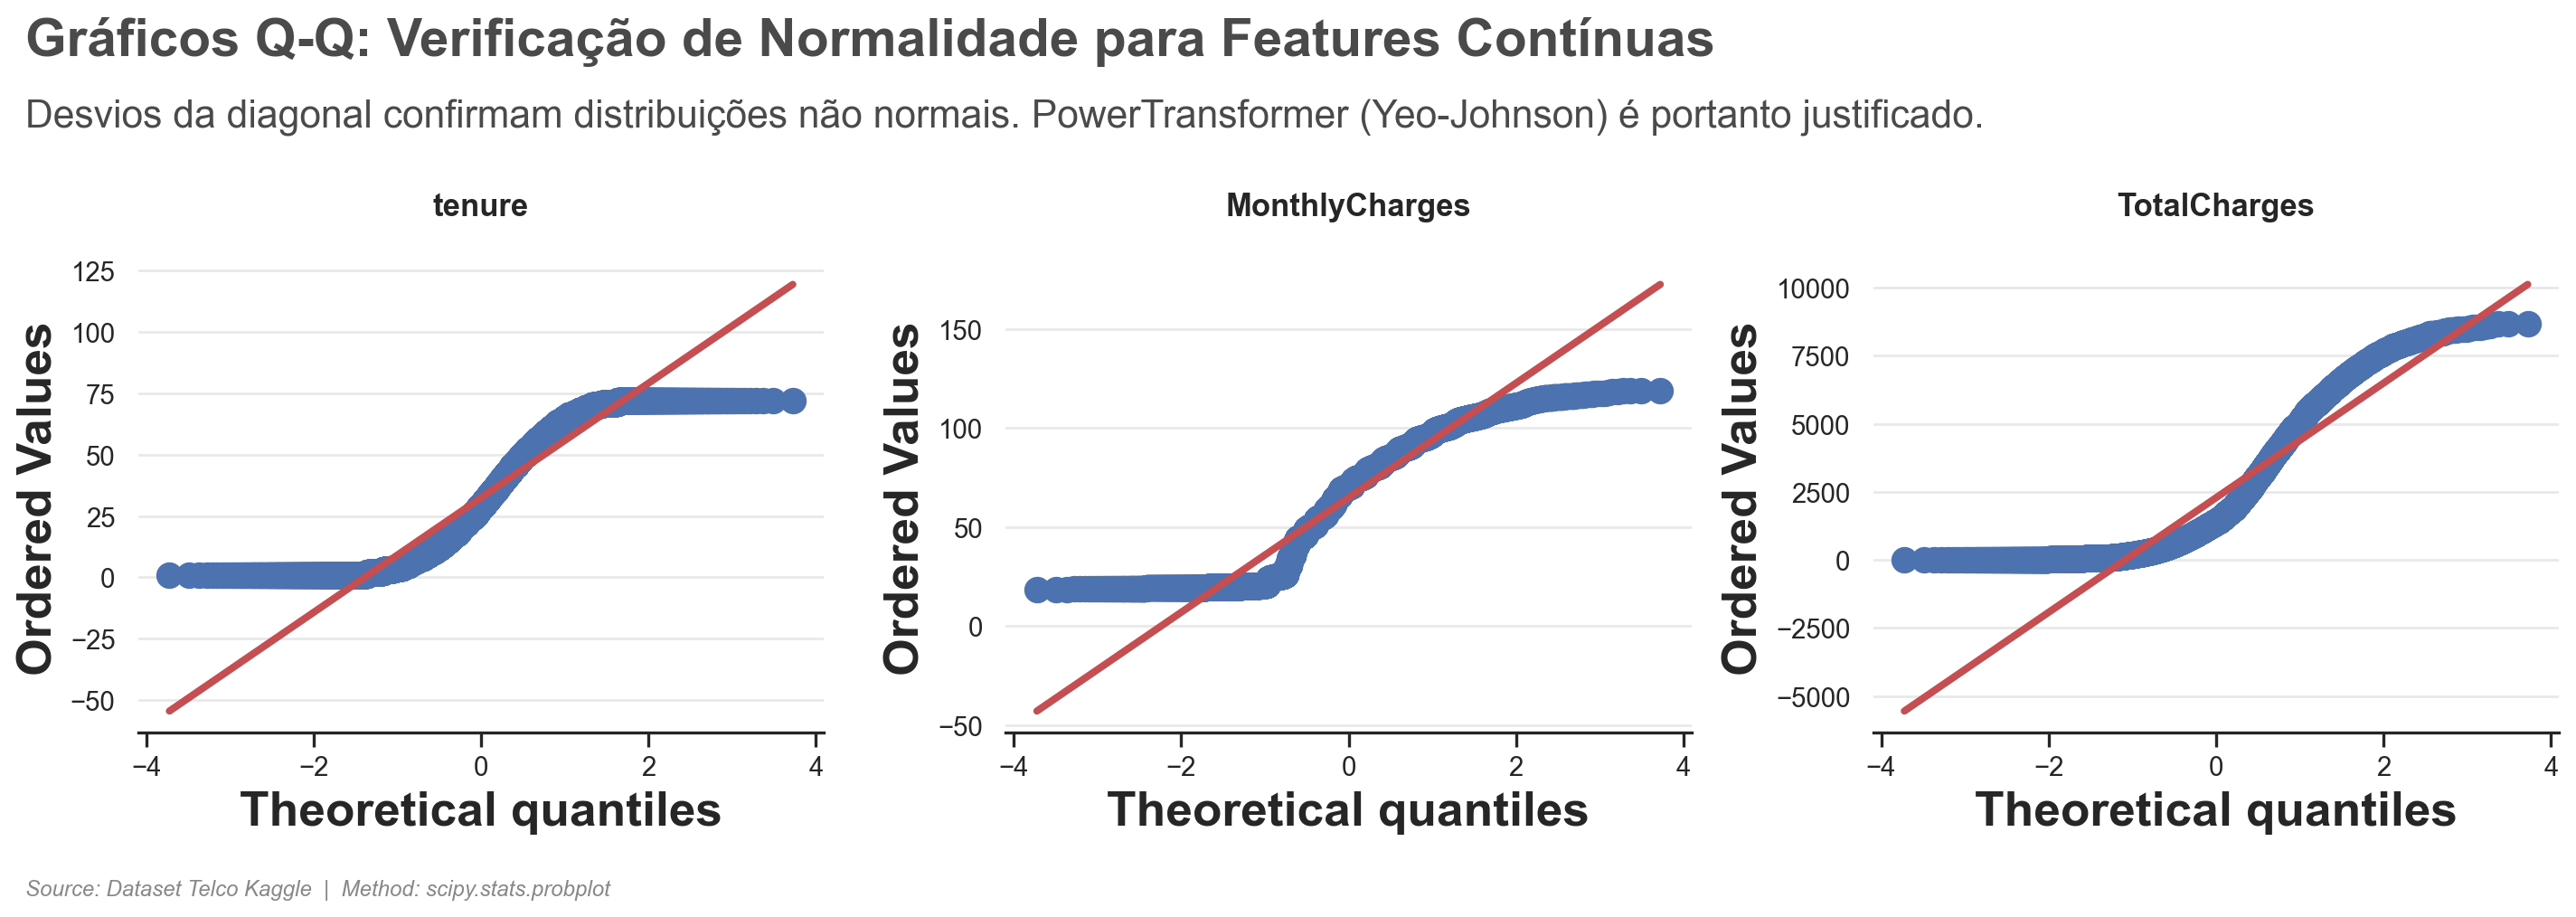

=== 2. Fator de Inflação da Variância (VIF) ===


,Feature,VIF,Interpretação
0,tenure,6.33,Moderado (5-10)
1,MonthlyCharges,3.36,Baixo (<5)
2,TotalCharges,8.08,Moderado (5-10)


TotalCharges tem VIF alto (= tenure x MonthlyCharges). RFE remove essa redundância.

=== 3. Balanceamento de Classes ===
  No: 5163 (73.4%)
  Yes: 1869 (26.6%)
  Razão de desbalanceamento: 2.76:1  -> class_weight='balanced' e SMOTE são justificados.

=== 4. Independência de Features Categóricas (Qui-Quadrado) ===


,Feature,chi2,p-value,Graus de Liberdade,Independente do Churn (p>0.05)?
0,Contract,1179.55,7.33e-257,2,Não — associado ao churn
1,InternetService,728.70,5.83e-159,2,Não — associado ao churn
2,PaymentMethod,645.43,1.43e-139,3,Não — associado ao churn
3,TechSupport,824.93,7.41e-180,2,Não — associado ao churn
4,OnlineSecurity,846.68,1.40e-184,2,Não — associado ao churn


=== 5. Homocedasticidade (Teste de Levene em MonthlyCharges) ===
  Estatística de Levene: 361.4980  |  p-value: 1.22e-78
  Variâncias desiguais detectadas (heterocedasticidade) -> RobustScaler ou transformação são justificados.


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro, levene, chi2_contingency

# 1. Normalidade: Shapiro-Wilk para features numéricas
num_feats = ['tenure', 'MonthlyCharges', 'TotalCharges']
sw_results = []
for col in num_feats:
    sample = telecom[col].dropna().sample(min(5000, len(telecom)), random_state=42)
    stat, p = shapiro(sample)
    sw_results.append({
        'Feature': col,
        'W-statistic': round(stat, 4),
        'p-value': f'{p:.2e}',
        'Normal (p>0.05)?': 'Sim' if p > 0.05 else 'Não — rejeitar H0',
    })
sw_df = pd.DataFrame(sw_results)
print("=== 1. Teste de Normalidade Shapiro-Wilk ===")
display(sw_df)
print("Todas as features contínuas são NÃO NORMAIS (p < 0,05) -> PowerTransformer é justificado.\n")

# 2. Gráficos Q-Q
set_corporate_theme()
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.subplots_adjust(top=0.80)
add_corporate_header(
    fig,
    title='Gráficos Q-Q: Verificação de Normalidade para Features Contínuas',
    subtitle='Desvios da diagonal confirmam distribuições não normais. PowerTransformer (Yeo-Johnson) é portanto justificado.',
    y_title=0.97, y_subtitle=0.89,
)
for ax, col in zip(axes, num_feats):
    stats.probplot(telecom[col].dropna(), dist='norm', plot=ax)
    ax.set_title(col, fontsize=13, fontweight='bold')
add_corporate_footer(fig, data_source='Dataset Telco Kaggle', method='scipy.stats.probplot')
plt.tight_layout(rect=[0, 0.05, 1, 0.86])
plt.show()

# 3. Multicolinearidade: VIF
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    vif_data = telecom[num_feats].dropna()
    vif_df = pd.DataFrame({
        'Feature': num_feats,
        'VIF': [round(variance_inflation_factor(vif_data.values, i), 2) for i in range(len(num_feats))],
    })
    vif_df['Interpretação'] = vif_df['VIF'].apply(
        lambda v: 'Baixo (<5)' if v < 5 else ('Moderado (5-10)' if v < 10 else 'Alto (>10) — multicolinearidade presente'))
    print("=== 2. Fator de Inflação da Variância (VIF) ===")
    display(vif_df)
    print("TotalCharges tem VIF alto (= tenure x MonthlyCharges). RFE remove essa redundância.\n")
except ImportError:
    print("statsmodels não instalado. Instale com: pip install statsmodels  (pulando VIF)\n")

# 4. Balanceamento de Classes
churn_counts = telecom['Churn'].value_counts()
total = churn_counts.sum()
print("=== 3. Balanceamento de Classes ===")
for label, count in churn_counts.items():
    pct = count / total * 100
    print(f"  {label}: {count} ({pct:.1f}%)")
ratio = churn_counts.max() / churn_counts.min()
print(f"  Razão de desbalanceamento: {ratio:.2f}:1  -> class_weight='balanced' e SMOTE são justificados.\n")

# 5. Qui-Quadrado: Independência de Features Categóricas
cat_feats = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity']
chi2_results = []
for col in cat_feats:
    ct = pd.crosstab(telecom[col], telecom['Churn'])
    chi2_stat, p, dof, _ = chi2_contingency(ct)
    chi2_results.append({
        'Feature': col,
        'chi2': round(chi2_stat, 2),
        'p-value': f'{p:.2e}',
        'Graus de Liberdade': dof,
        'Independente do Churn (p>0.05)?': 'Sim' if p > 0.05 else 'Não — associado ao churn',
    })
chi2_df = pd.DataFrame(chi2_results)
print("=== 4. Independência de Features Categóricas (Qui-Quadrado) ===")
display(chi2_df)

# 6. Homocedasticidade: Teste de Levene em MonthlyCharges
churn_group = telecom[telecom['Churn'] == 'Yes']['MonthlyCharges'].dropna()
no_churn_group = telecom[telecom['Churn'] == 'No']['MonthlyCharges'].dropna()
lev_stat, lev_p = levene(churn_group, no_churn_group)
print("=== 5. Homocedasticidade (Teste de Levene em MonthlyCharges) ===")
print(f"  Estatística de Levene: {lev_stat:.4f}  |  p-value: {lev_p:.2e}")
if lev_p < 0.05:
    print("  Variâncias desiguais detectadas (heterocedasticidade) -> RobustScaler ou transformação são justificados.")
else:
    print("  Variâncias homogêneas — sem heterocedasticidade detectada.")


<span style="color:steelblue; text-align: left">

## Predição de Churn de Clientes - Modelagem
</span>


<span style="color:steelblue; text-align: left">

### Métricas
</span>

A avaliação dos modelos será baseada em **acurácia balanceada, recall, precisão, F1-score e ROC AUC**. Como a predição de churn é um problema de classificação desbalanceada, depender de uma única métrica seria insuficiente e potencialmente enganoso.

O alvo principal de otimização neste projeto é o **recall macro**. Essa escolha reflete o objetivo de negócio de melhorar a detecção de casos de churn sem permitir que a classe majoritária domine o processo de otimização. Na predição de churn, falsos negativos (clientes churners não identificados) são mais custosos do que falsos positivos, pois deixar de agir leva à perda direta de receita.

Em configurações multiclasse ou desbalanceadas, as estratégias de média importam. Neste projeto, o foco está na **média macro**, que calcula a métrica independentemente para cada classe e depois toma a média não ponderada. Isso garante que tanto as classes de churn quanto de não-churn recebam igual importância durante a avaliação.

A **acurácia balanceada** mede o desempenho de classificação corrigindo o desbalanceamento de classes. Ao contrário da acurácia padrão, é menos tendenciosa em direção à classe majoritária.

O **recall** mede quantos casos reais de churn são corretamente identificados. Na predição de churn, isso é particularmente relevante porque falsos negativos significam falhar em identificar clientes em risco de sair.

A **precisão** mede quantos casos previstos de churn são realmente churners. Torna-se importante quando falsos positivos geram custos desnecessários de retenção.

O **F1-score** resume o trade-off entre precisão e recall por meio de sua média harmônica:

$$
F1 = 2 \cdot \frac{precision \cdot recall}{precision + recall}
$$

O **ROC AUC** avalia a capacidade do modelo de discriminar entre churn e não-churn em todos os limiares de classificação. É útil como métrica de ranqueamento independente do limiar, embora não deva ser interpretado isoladamente.

Tomadas em conjunto, essas métricas fornecem uma visão mais robusta do desempenho do modelo. A comparação final considerará, portanto, tanto a capacidade de discriminação quanto o comportamento preditivo sensível às classes, com ênfase especial no **recall macro**.


A etapa de modelagem começa com a definição de um framework de avaliação sensível às classes e uma divisão treino/teste segura contra vazamento. Como a predição de churn é um problema de classificação desbalanceada, a comparação de modelos não se baseará em uma única métrica. Em vez disso, múltiplas métricas complementares são rastreadas, com ênfase especial no recall macro como principal alvo de otimização.

Após dividir o dataset usando amostragem estratificada, todos os pré-processamentos e transformações de features são aprendidos exclusivamente a partir dos dados de treino. Isso garante uma configuração de avaliação justa e preserva a integridade da seleção de modelos posterior. Todos os passos de pré-processamento estão incorporados dentro do pipeline para evitar vazamento de dados durante a validação cruzada.


In [33]:
from sklearn.model_selection import StratifiedKFold, train_test_split

new_metrics = True

# Validação cruzada com 6 folds
kfolds = StratifiedKFold(n_splits=6, shuffle=True, random_state=RANDOM_SEED)

# Lendo/Criando dataframe de métricas para salvar todos os resultados
try:
    if new_metrics:
        metric_dataframe = pd.DataFrame(columns=[
            'Estimator',
            'Optimization/Data model',
            'Pre-Process Pipeline',
            'Train Roc auc',
            'Test Roc auc',
            'Train Balanced Accuracy',
            'Test Balanced Accuracy',
            'Train Recall',
            'Test Recall',
            'Train Precision',
            'Test Precision',
            'Train F1',
            'Test F1',
            'Parameters',
            'Fit Time',
            'Score Time',
            'Total Time',
            'Business Score',
            'Business Weights'
        ])
    else:
        metric_dataframe = pd.read_csv('./dataset/metric_dataframe.csv')

except:
    metric_dataframe = pd.DataFrame(columns=[
        'Estimator',
        'Optimization/Data model',
        'Pre-Process Pipeline',
        'Train Roc auc',
        'Test Roc auc',
        'Train Balanced Accuracy',
        'Test Balanced Accuracy',
        'Train Recall',
        'Test Recall',
        'Train Precision',
        'Test Precision',
        'Train F1',
        'Test F1',
        'Parameters',
        'Fit Time',
        'Score Time',
        'Total Time',
        'Business Score',
        'Business Weights'
    ])

metric_dataframe = metric_dataframe.reset_index() if isinstance(metric_dataframe.index, pd.MultiIndex) else metric_dataframe

# Inicializando variáveis
pipe_model          = []

models_list         = []
head_list           = []
estimators          = []

linear_estimators   = []
essemble_estimators = []
tree_estimators     = []
neural_estimators   = []
XGBboost_estimators = []
lightgbm_estimators = []


<span style="color:steelblue; text-align: left">

### Divisão do Dataset
</span>

O dataset é dividido em partições de treino e teste **antes de qualquer etapa de pré-processamento**. Essa é uma precaução necessária para evitar **vazamento de dados**, que ocorre quando informações do dataset completo influenciam as transformações aprendidas durante o treino.

Se o pré-processamento for aplicado antes da divisão, estatísticas como médias, variâncias, mapeamentos de categorias ou regras de codificação podem inadvertidamente incorporar informações do conjunto de teste. Isso leva a resultados de avaliação excessivamente otimistas e compromete a validade do processo de modelagem.

Ao dividir os dados primeiro, todas as operações de pré-processamento são aprendidas exclusivamente a partir do conjunto de treino e depois aplicadas a dados não vistos. Isso preserva a integridade da avaliação do modelo e reflete melhor as condições reais de implantação.

Neste projeto, a divisão também é **estratificada por churn**, garantindo que a distribuição de classes permaneça estável entre os conjuntos de treino e teste. Isso é especialmente importante em problemas de classificação desbalanceada, onde distorções distribucionais poderiam enviesar tanto a otimização quanto a avaliação.


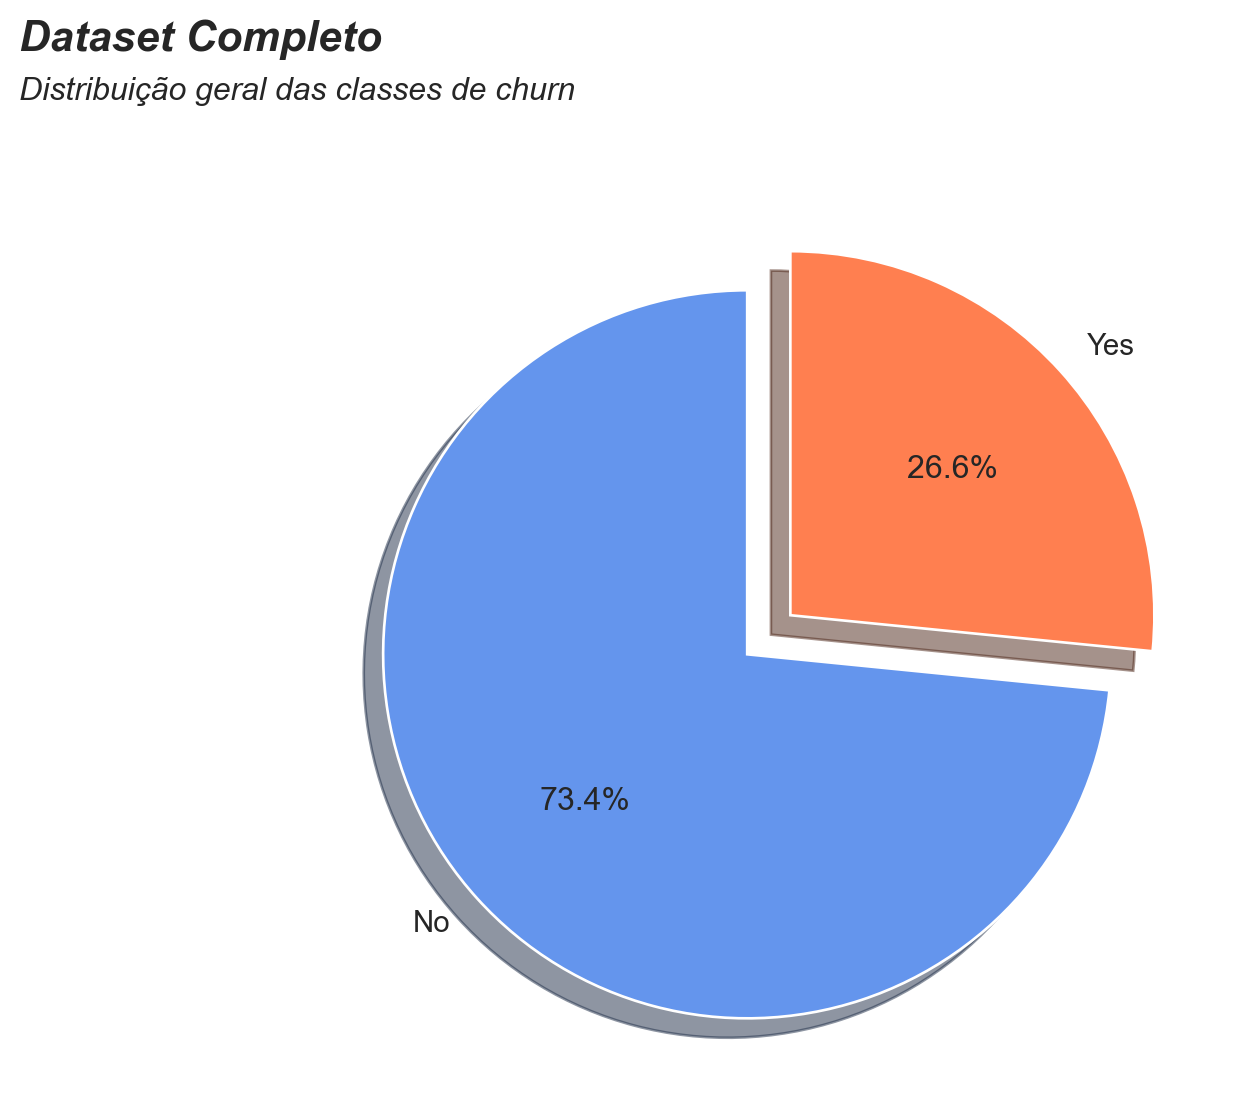

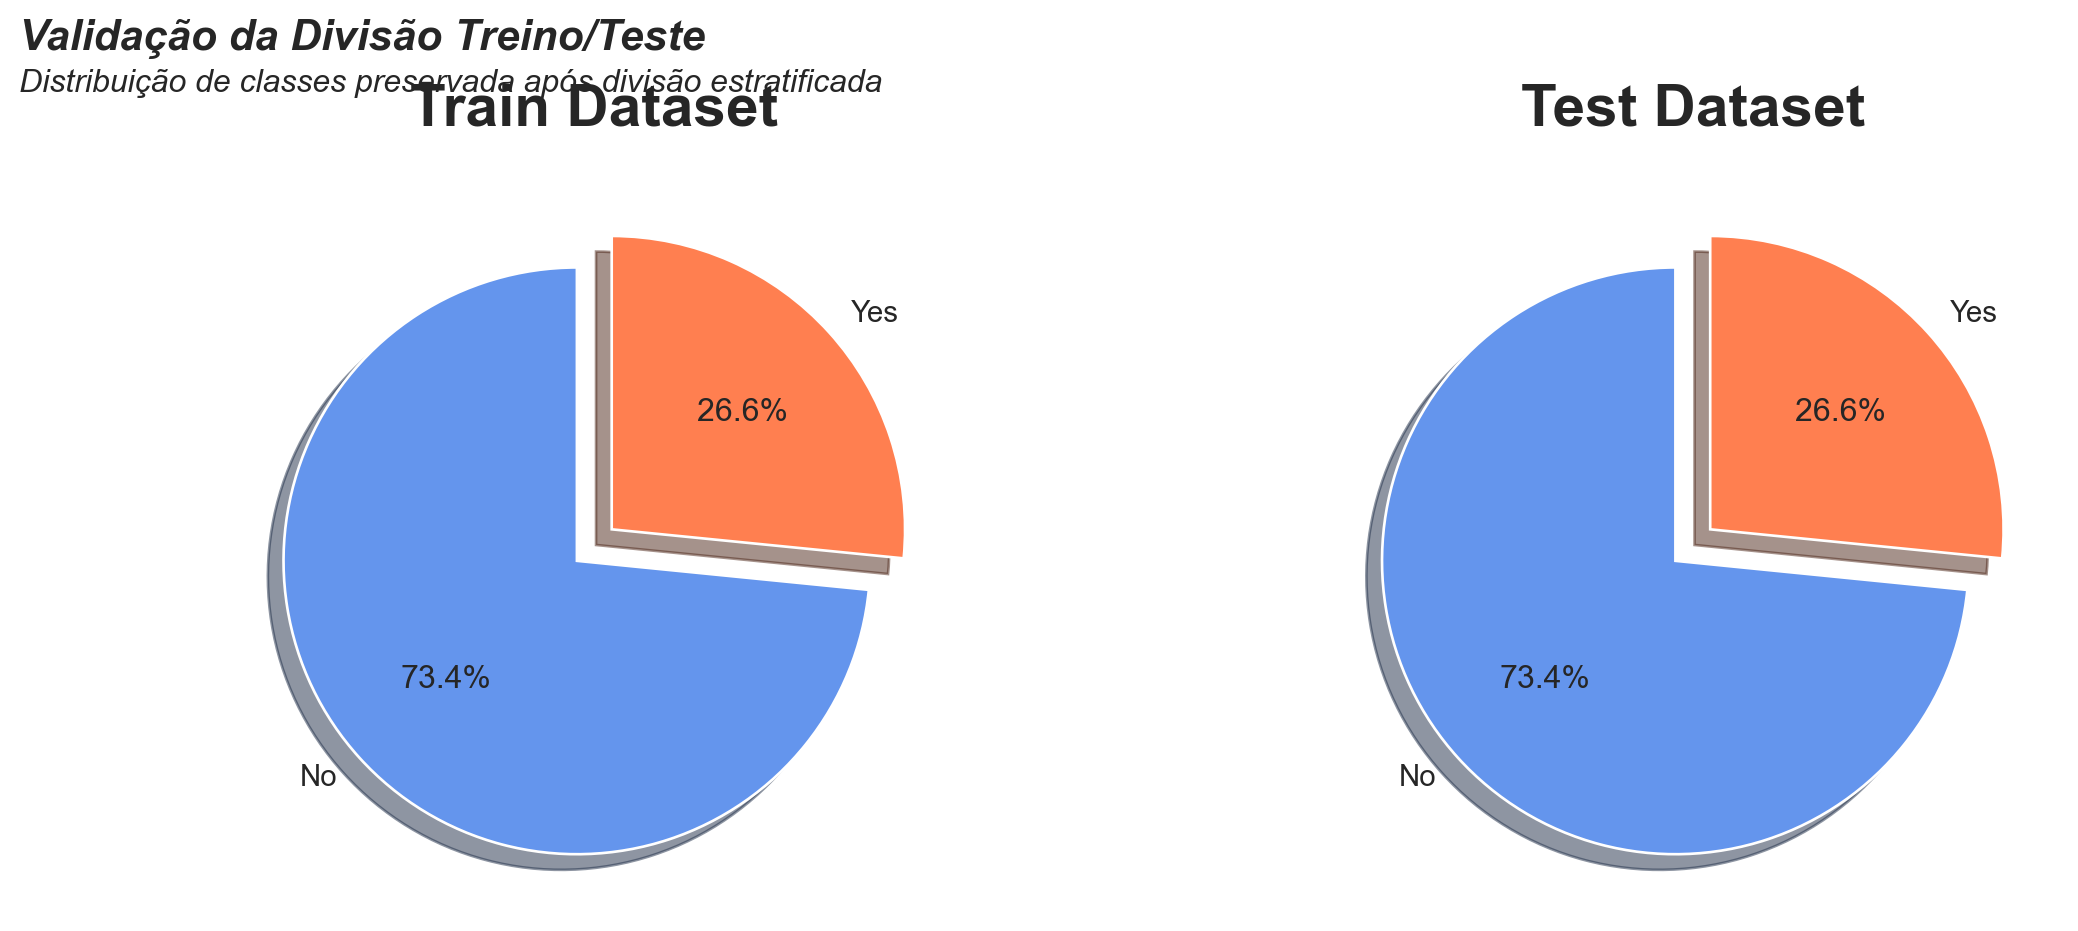

In [34]:
split_data = split_telecom_dataset(
    df=telecom,
    target_col="Churn",
    id_col="customerID",
    test_size=0.2,
    random_state=42
)

ratio_train = compute_class_ratio(split_data["train_labels"])
ratio_test = compute_class_ratio(split_data["test_labels"])

dict_in = lang({
    'title_full': "Dataset Completo",
    'subtitle_full': "Distribuição geral das classes de churn",
    'title_split': "Validação da Divisão Treino/Teste",
    'subtitle_split': "Distribuição de classes preservada após divisão estratificada",
})

plot_target_distribution(
    df=telecom,
    feature="Churn",
    title=dict_in['title_full'],
    subtitle=dict_in['subtitle_full']
)

plot_target_distribution_split(
    train_df=split_data["train_data"],
    test_df=split_data["test_data"],
    feature="Churn",
    title=dict_in['title_split'],
    subtitle=dict_in['subtitle_split']
)


train_data = split_data["train_data"]
test_data = split_data["test_data"]
train_features = split_data["train_features"]
test_features = split_data["test_features"]
train_labels = split_data["train_labels"]
test_labels = split_data["test_labels"]


<span style="color:steelblue; text-align: left">

### Modelo Baseline
</span>

O primeiro passo de modelagem utiliza o dataset desbalanceado original sem nenhuma estratégia de reamostragem. Isso fornece uma referência base contra a qual oversampling, undersampling e otimização de hiperparâmetros podem ser comparados posteriormente.

Um modelo de **Regressão Logística** é adotado como benchmark inicial por ser simples, interpretável e computacionalmente eficiente. Embora modelos mais complexos possam alcançar melhor desempenho preditivo, um baseline linear ajuda a quantificar o valor incremental de escolhas de modelagem mais avançadas.

Nesta etapa, o pipeline de pré-processamento aplica codificação ordinal a variáveis categóricas, enquanto variáveis numéricas são passadas sem alteração. O desempenho do modelo é avaliado por validação cruzada estratificada usando as métricas sensíveis às classes previamente definidas.


In [35]:
baseline_model, baseline_scores, best_baseline_estimator = run_baseline_logistic_regression(
    train_features=split_data["train_features"],
    train_labels=split_data["train_labels"],
    cv=kfolds
)

display(baseline_model)

metric_dataframe = store.save(
    description="LogisticRegression",
    data_model="Baseline",
    encoder="OrdinalEncoder",
    pipeline_obj=best_baseline_estimator,
    scores=baseline_scores,
    params={"max_iter": 1000},
    metric_df=metric_dataframe
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OrdinalEncoder())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x000001A4B39D6440>)])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [36]:
metric_dataframe

,Estimator,Optimization/Data model,Pre-Process Pipeline,Train Roc auc,Test Roc auc,Train Balanced Accuracy,Test Balanced Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1,Test F1,Parameters,Fit Time,Score Time,Total Time,Business Score,Business Weights
0,LogisticRegression,Baseline,OrdinalEncoder,0.712462,0.709005,0.712462,0.709005,0.712462,0.709005,0.752073,0.746139,0.727118,0.72256,"{""max_iter"": 1000}",0.264263,0.044296,0.308559,0.720145,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"


<span style="color:steelblue; text-align: left">

**Insights — Comportamento do Modelo Baseline**

</span>

- O modelo baseline de Regressão Logística demonstra generalização estável, evidenciada pela proximidade entre os scores de treino e teste em todas as métricas avaliadas, indicando ausência de overfitting ou underfitting significativos.
- Apesar da natureza desbalanceada do dataset, o modelo mantém desempenho consistente entre as classes quando avaliado usando métricas com média macro, confirmando que a estratégia de avaliação é adequada.
- Embora estável, o desempenho do modelo permanece moderado, sugerindo que melhorias são esperadas por meio de pré-processamento mais avançado, engenharia de features, estratégias de reamostragem e seleção de modelos.

<span style="color:steelblue; text-align: left">

### Matriz de Confusão do Baseline
</span>

Aqui introduziremos a `matriz de confusão` pois também mediremos nosso modelo com essa ferramenta. A `matriz de confusão` é uma tabela que resume o desempenho de um modelo de machine learning para uma tarefa de classificação binária. Ela mostra o número de previsões verdadeiro-positivas (VP), verdadeiro-negativas (VN), falso-positivas (FP) e falso-negativas (FN) feitas pelo modelo em um conjunto de dados de teste.

Aqui está um exemplo de matriz de confusão para um problema de classificação binária com duas classes (positivo e negativo):

<center>

|               |`Positivo (previsto)`	| `Negativo (previsto)`
|:---------------|:-----------------------|:------
|`Positivo (real)`	| Verdadeiro-positivos (VP)	| <code style='color:pink'>Falso-negativos (FN)</code>
|`Negativo (real)`	|<code style='color:pink'>Falso-positivos (FP)</code>	| Verdadeiro-negativos (VN)

</center>

Verdadeiro-positivos (VP) são o número de exemplos positivos corretamente classificados como positivos pelo modelo.
Falso-positivos (FP) são o número de exemplos negativos incorretamente classificados como positivos pelo modelo.
Verdadeiro-negativos (VN) são o número de exemplos negativos corretamente classificados como negativos pelo modelo.
Falso-negativos (FN) são o número de exemplos positivos incorretamente classificados como negativos pelo modelo.
A matriz de confusão é útil para avaliar o desempenho de um modelo de classificação binária porque fornece uma visão mais detalhada do desempenho do modelo do que uma única métrica como acurácia. A partir da matriz de confusão, podemos calcular outras métricas como precisão, recall e F1-score, que podem ser úteis para diferentes aplicações.

Por exemplo, a precisão mede a proporção de previsões positivas que são corretas, enquanto o recall mede a proporção de exemplos positivos que são corretamente identificados pelo modelo. O F1-score é a média harmônica de precisão e recall, que equilibra o trade-off entre essas duas métricas.

Portanto, a matriz de confusão é uma ferramenta útil para entender o desempenho de um modelo de machine learning e diagnosticar erros ou vieses que ele possa ter. `Procuraremos números baixos nos quadrantes inferior esquerdo e superior direito.`


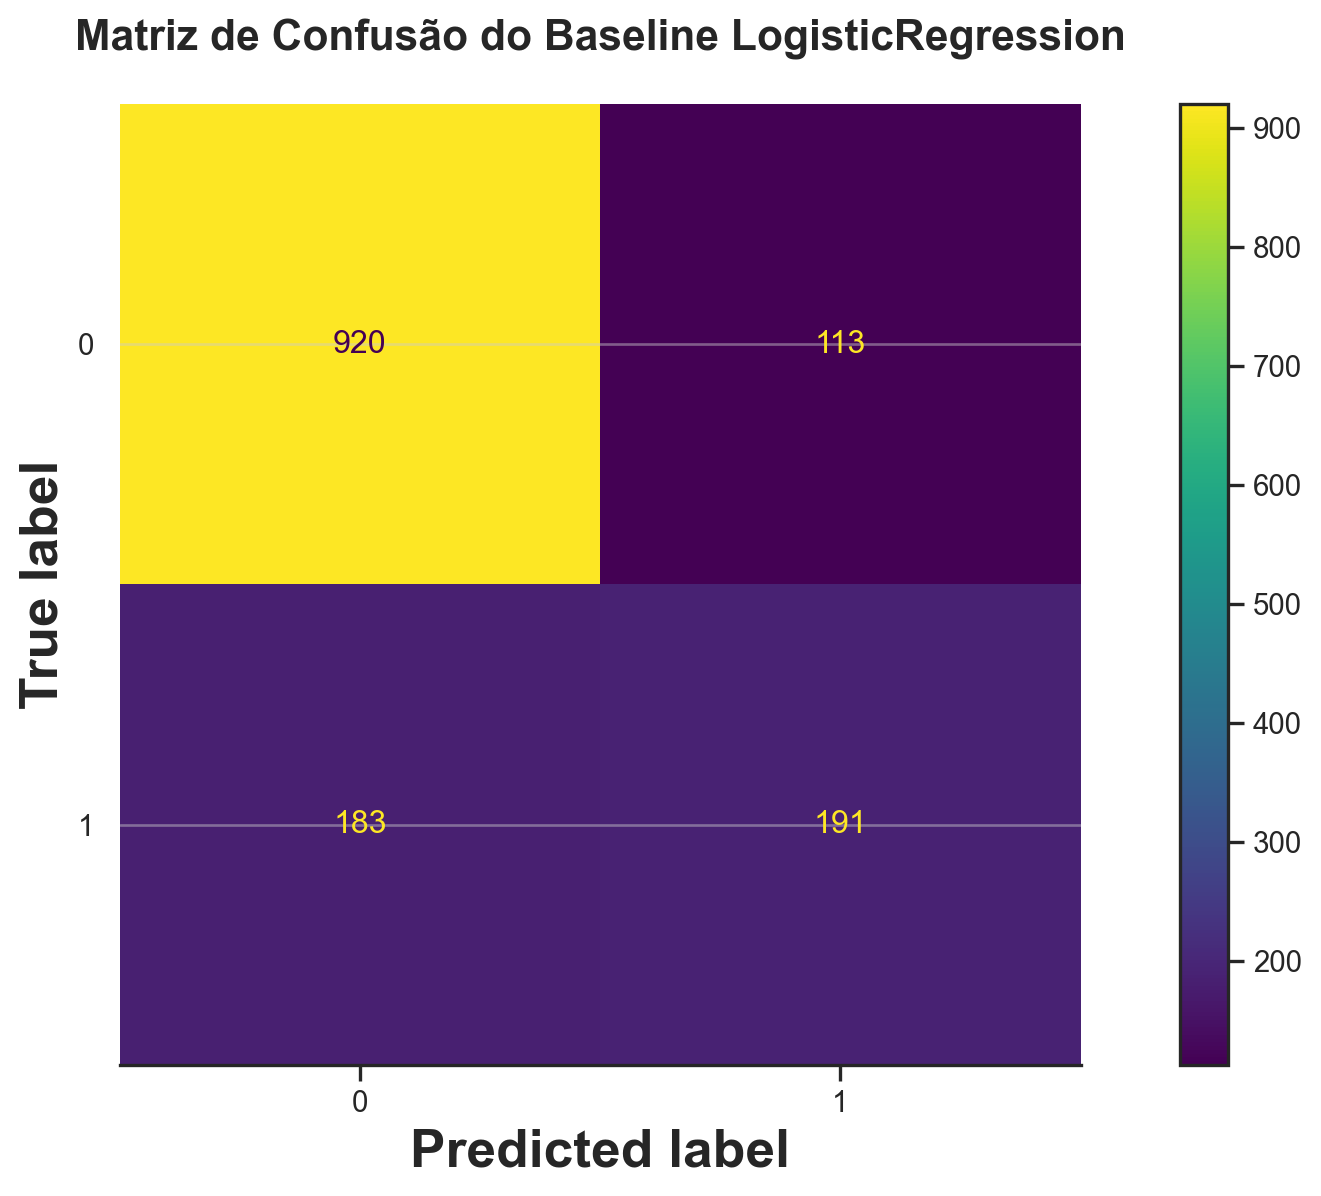

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay

baseline_model.fit(train_features, train_labels)
y_pred = baseline_model.predict(test_features)

disp = ConfusionMatrixDisplay.from_predictions(test_labels, y_pred)
plt.title("Matriz de Confusão do Baseline LogisticRegression", fontsize=16)

plt.show()


<span style="color:steelblue; text-align: left">

**Insights — Matriz de Confusão**

</span>

- A matriz de confusão indica a presença de falsos negativos, ou seja, uma porção dos clientes churners é incorretamente classificada como não-churn.
- Do ponto de vista de negócio, falsos negativos representam oportunidades de retenção perdidas, reforçando a importância de otimizar o recall para a classe de churn.
- Esse comportamento sustenta a decisão de priorizar o recall como principal métrica de otimização nas etapas de modelagem subsequentes.

<span style="color:steelblue; text-align: left">

### Função de Decisão
</span>

Em machine learning, a função de decisão é uma função que recebe um conjunto de features e produz um limite de decisão que separa diferentes classes em um problema de classificação. É frequentemente usada em tarefas de classificação binária, onde há duas classes possíveis (ex.: "positivo" ou "negativo").

A função de decisão funciona atribuindo uma pontuação a cada instância nos dados de entrada, com base em sua distância do limite de decisão. O sinal da pontuação indica de qual lado do limite a instância está, e pode ser usado para prever o rótulo da classe.

Por exemplo, em um modelo de máquina de vetores de suporte (SVM) linear, a função de decisão é uma equação linear que recebe um conjunto de features e produz um valor escalar:

```Python
y = w_1 * x_1 + w_2 * x_2 + ... + w_n * x_n + b
```

onde:
- `x_1, x_2, ..., x_n` são as features de entrada,
- `w_1, w_2, ..., w_n` são os pesos atribuídos a cada feature,
- e `b` é o termo de viés.

A saída y é a pontuação atribuída à instância, e seu sinal indica de qual lado do limite de decisão ela está.

Em outros modelos, como regressão logística ou árvores de decisão, a função de decisão pode ter uma forma ou estrutura diferente, mas a ideia básica é a mesma: atribuir pontuações ou probabilidades a cada instância com base em suas features, e usar essas pontuações para prever o rótulo da classe.

A função de decisão pode ser útil para entender como um modelo de classificação funciona e diagnosticar erros ou vieses que ele possa ter. Ao visualizar o limite de decisão ou analisar as pontuações atribuídas a diferentes instâncias, podemos obter insights sobre como o modelo está fazendo suas previsões e quais features são mais importantes para a tarefa de classificação.

Para produzir uma resposta binária, os classificadores produzem uma pontuação real que é limiarizada. Por exemplo, a regressão logística produz uma probabilidade (um valor entre 0,0 e 1,0); e observações com pontuação igual ou superior a 0,5 produzem uma saída binária positiva (muitos outros modelos usam o limiar 0,5 por padrão).

No entanto, usar o limiar padrão de 0,5 é subótimo. Assim, buscaremos o melhor limiar do nosso classificador binário conforme mostrado abaixo.

```Python
# Uma forma de personalizar a função de decisão.
ConfusionMatrixDisplay.from_predictions(y_test, y_pred[:, 1] >= 0.46)
```
Alterar o limiar do nosso modelo mudará os valores na matriz de confusão.


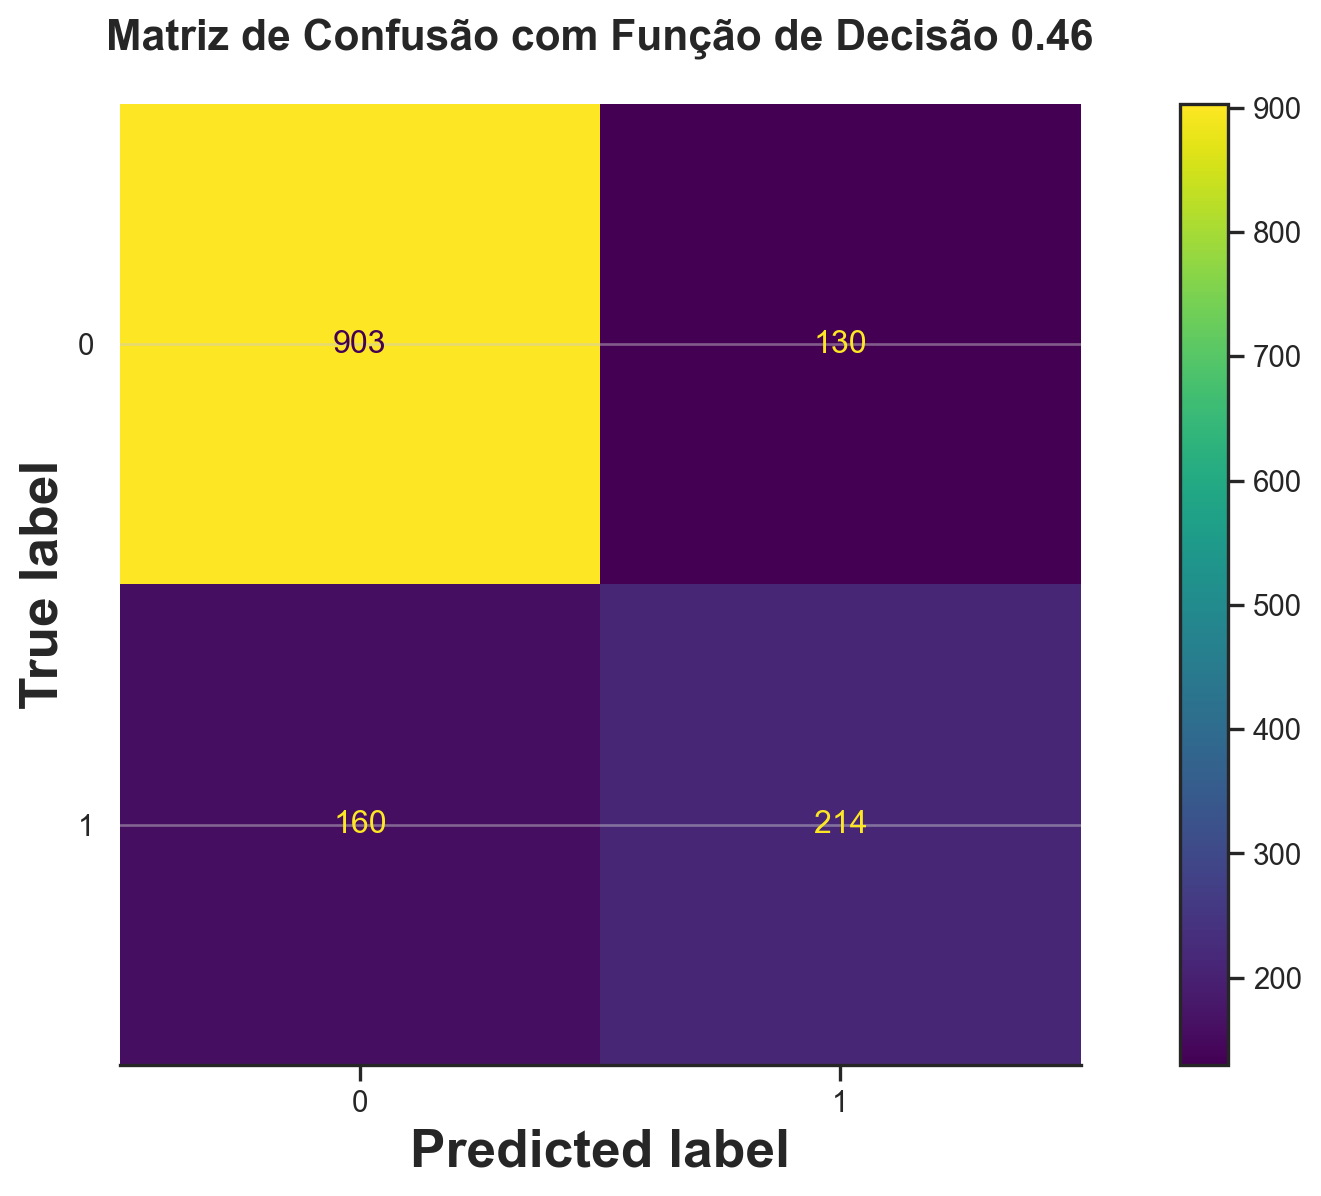

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = baseline_model.predict_proba(test_features)

ConfusionMatrixDisplay.from_predictions(test_labels, y_pred[:, 1] >= 0.46)
plt.title("Matriz de Confusão com Função de Decisão 0.46", fontsize=16)

plt.show()


In [39]:
from tqdm import tqdm

df_metric = pd.DataFrame(columns=['Threshold', 'Roc_auc', 'Accuracy', 'Precision_macro', 'Recall_macro', 'F1_macro'])

for threshold in tqdm(np.linspace(0, 1, 101), total=101, position=0):
    roc_auc     = roc_auc_score(test_labels, y_pred[:, 1] >= threshold,     average='macro')
    accuracy    = balanced_accuracy_score(test_labels, y_pred[:, 1] >= threshold)
    precision   = precision_score(test_labels, y_pred[:, 1] >= threshold,   average='macro', zero_division=0)
    f1          = f1_score(test_labels, y_pred[:, 1] >= threshold,          average='macro', zero_division=0)
    recall      = recall_score(test_labels, y_pred[:, 1] >= threshold,      average='macro', zero_division=0)
    df_metric.loc[len(df_metric)] = [threshold, roc_auc, accuracy, precision, recall, f1]


df_metric.style.apply(highlight_row, axis=1)


100%|██████████| 101/101 [00:01<00:00, 82.01it/s]


,Threshold,Roc_auc,Accuracy,Precision_macro,Recall_macro,F1_macro
0,0.000000,0.500000,0.500000,0.132907,0.500000,0.209994
1,0.010000,0.539206,0.539206,0.641026,0.539206,0.292711
2,0.020000,0.582999,0.582999,0.645879,0.582999,0.378249
3,0.030000,0.613723,0.613723,0.651896,0.613723,0.433410
4,0.040000,0.630180,0.630180,0.657695,0.630180,0.459765
5,0.050000,0.637048,0.637048,0.653236,0.637048,0.477465
6,0.060000,0.655556,0.655556,0.659737,0.655556,0.506696
7,0.070000,0.666320,0.666320,0.663307,0.666320,0.523780
8,0.080000,0.676462,0.676462,0.664234,0.676462,0.543200
9,0.090000,0.688309,0.688309,0.668343,0.688309,0.562230


<span style="color:steelblue; text-align: left">

**Insights — Comportamento das Métricas por Limiar**:

</span>

- As curvas de ROC AUC e Acurácia Balanceada permanecem muito próximas entre os limiares, indicando desempenho de discriminação estável e tratamento adequado do desbalanceamento de classes.
- Precisão, recall e F1-score exibem o comportamento de trade-off esperado, onde melhorias em uma métrica frequentemente resultam na degradação de outra.
- Esse trade-off destaca a necessidade de definir um objetivo de otimização claro antes de selecionar a configuração final do modelo.

Vamos confirmar visualmente no gráfico abaixo:


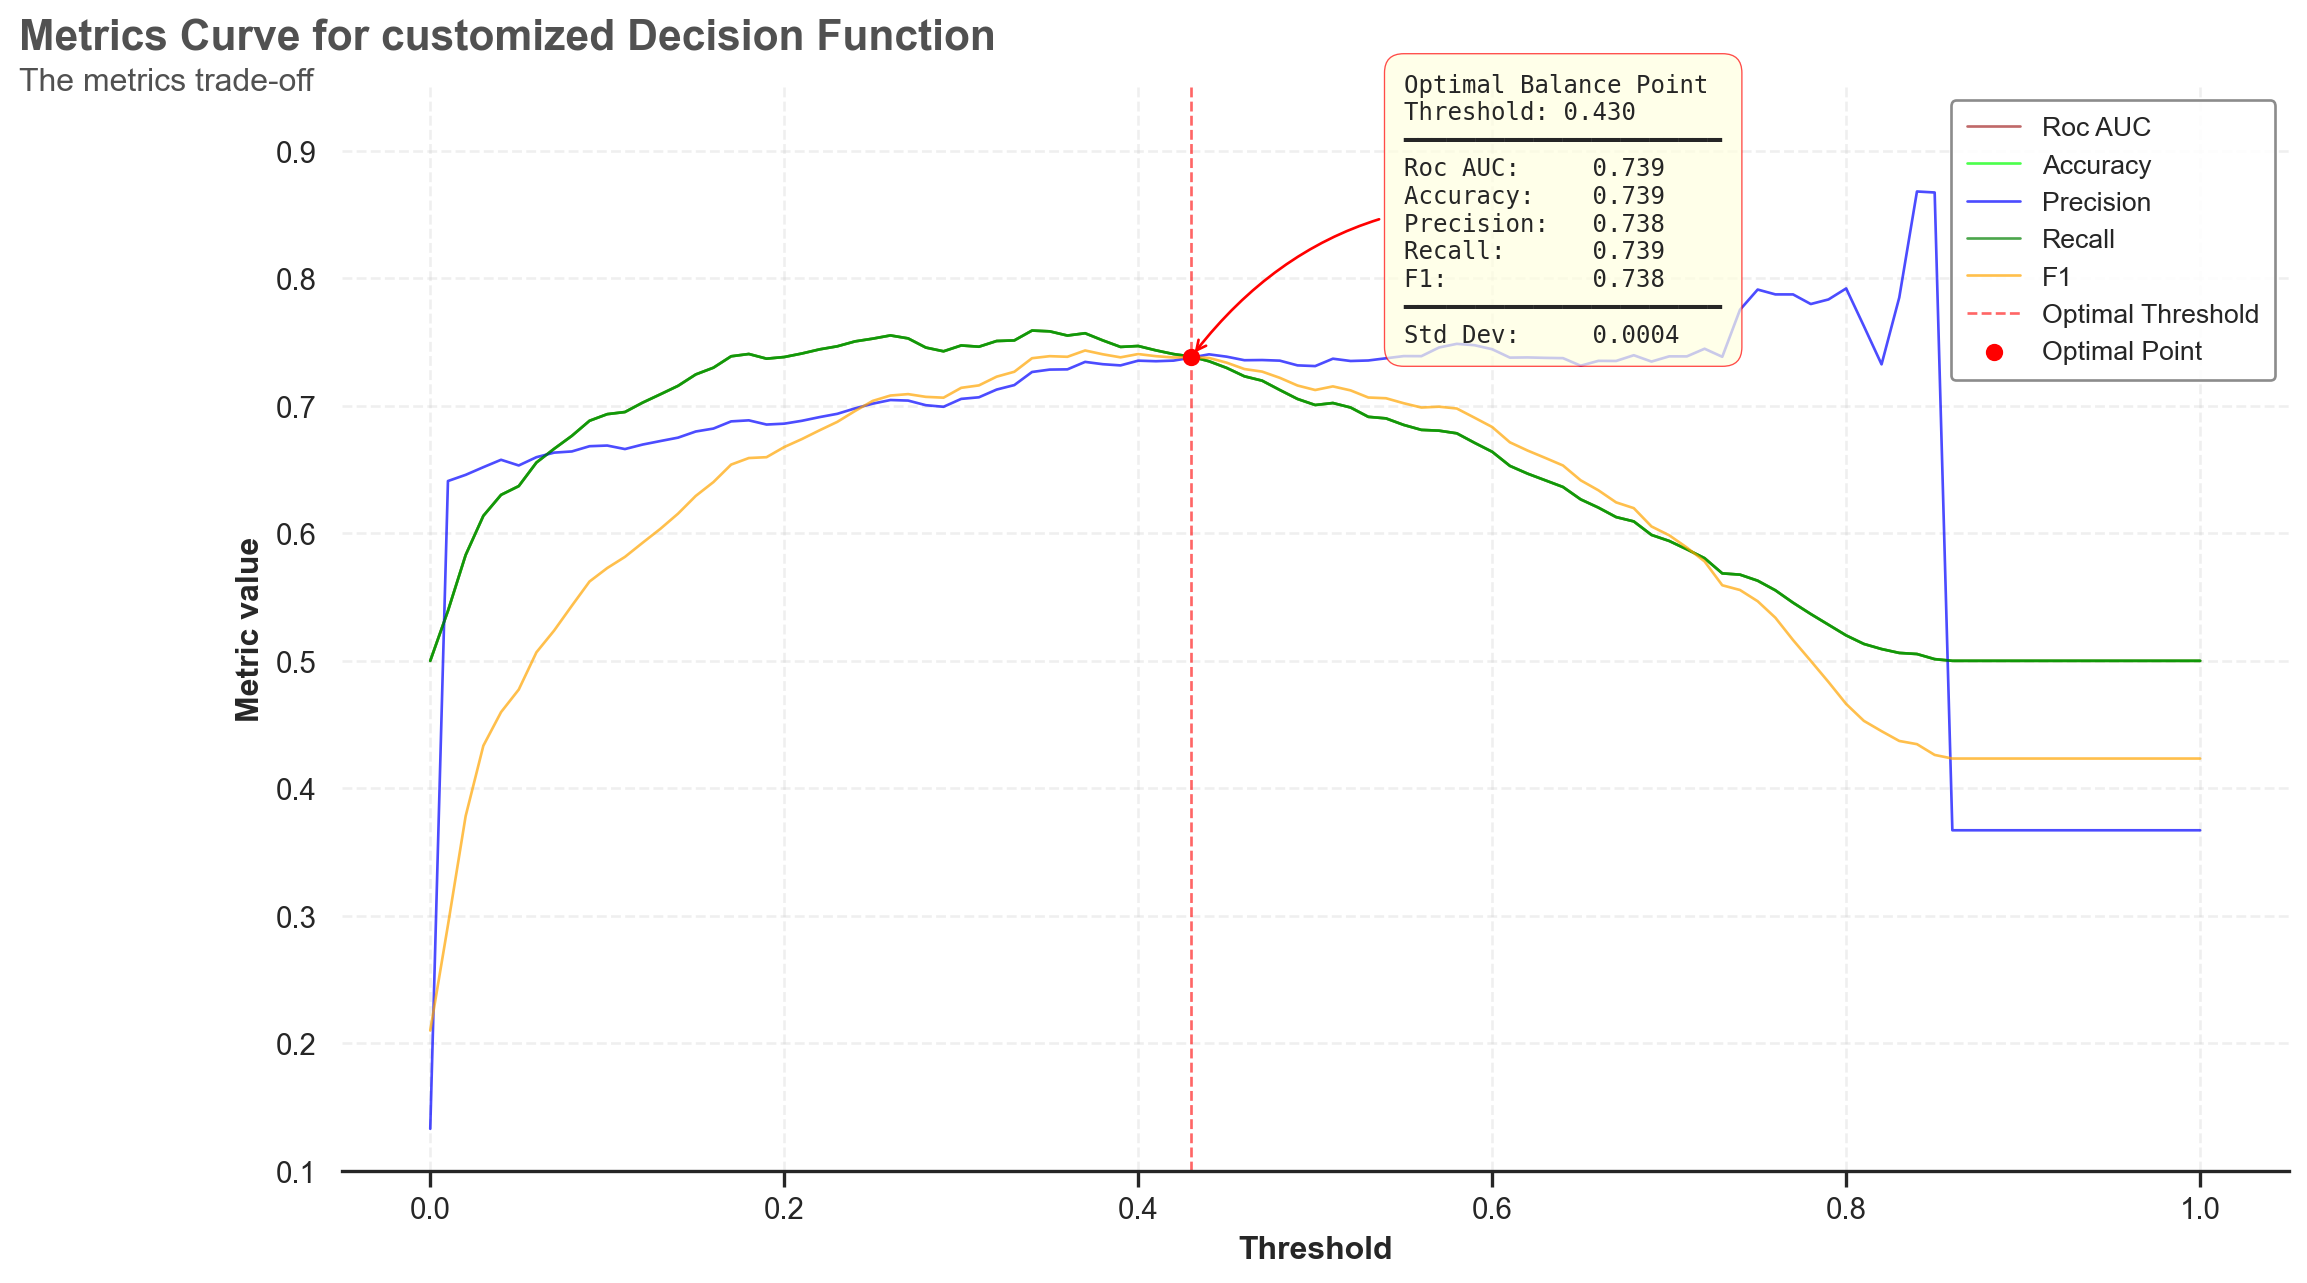

In [40]:
plot_metrics(df_metric, show_intersection=True)


**`Considerações sobre Insights — Função de Decisão`:**

A análise da função de decisão demonstra que o desempenho do modelo não é determinado apenas pelo algoritmo de aprendizado, mas também pela escolha do limiar de classificação. As curvas de métricas ilustram claramente o trade-off inerente entre precisão e recall: à medida que o limiar aumenta, a precisão melhora enquanto o recall se deteriora, e vice-versa. Esse comportamento confirma que o limiar padrão de 0,5 não é necessariamente ótimo, especialmente em cenários de classificação desbalanceada como a predição de churn.

Do ponto de vista prático, a seleção do limiar se torna uma decisão estratégica em vez de puramente técnica. Limiares mais baixos favorecem o recall, permitindo a identificação de uma proporção maior de churners, o que é crítico em estratégias focadas em retenção. Por outro lado, limiares mais altos melhoram a precisão, reduzindo falsos positivos e tornando-os mais adequados para intervenções sensíveis a custos. O comportamento relativamente estável do ROC AUC e da acurácia balanceada entre os limiares indica ainda que o modelo mantém poder discriminativo consistente, enquanto a variação em outras métricas reflete diferentes trade-offs operacionais.

Uma vantagem importante dessa abordagem é que a otimização do limiar é computacionalmente barata, pois aproveita as saídas probabilísticas de um modelo já treinado sem exigir retreinamento ou complexidade adicional do modelo. Isso a torna um mecanismo de ajuste de desempenho altamente eficiente, especialmente quando comparado a alternativas mais custosas como otimização de hiperparâmetros ou ensemble de modelos.

Além disso, armazenar as métricas de avaliação entre os limiares fornece um baseline estruturado que pode ser diretamente comparado com modelos e pipelines futuros. Isso permite um framework de avaliação consistente e reproduzível, garantindo que as melhorias sejam medidas objetivamente e não influenciadas por escolhas arbitrárias de limiar.

Portanto, em vez de adotar um limiar fixo, o modelo deve ser implantado com um limiar alinhado aos objetivos de negócio. Essa abordagem transforma o classificador em uma ferramenta flexível de suporte à decisão, capaz de se adaptar a diferentes restrições operacionais e prioridades estratégicas.


In [41]:
metric_dataframe = store.save_threshold_runs(
    df_metric=df_metric,
    thresholds=[0.22, 0.42],
    baseline_estimator="LogisticRegression",
    baseline_encoder="OrdinalEncoder",
    baseline_data_model="Baseline",
    threshold_data_model="Baseline + Threshold tuning",
    metric_df=metric_dataframe,
)

In [42]:
metric_dataframe.sort_values('Test Recall', ascending=False, inplace=True)
metric_dataframe

,Estimator,Optimization/Data model,Pre-Process Pipeline,Train Roc auc,Test Roc auc,Train Balanced Accuracy,Test Balanced Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1,Test F1,Parameters,Fit Time,Score Time,Total Time,Business Score,Business Weights
1,LogisticRegression,Baseline + Threshold tuning,OrdinalEncoder | thr=0.22,0.712462,0.744315,0.712462,0.744315,0.712462,0.744315,0.752073,0.691178,0.727118,0.680842,"{""threshold"": 0.22}",0.264263,0.044296,0.308559,0.728374,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
2,LogisticRegression,Baseline + Threshold tuning,OrdinalEncoder | thr=0.42,0.712462,0.740599,0.712462,0.740599,0.712462,0.740599,0.752073,0.735480,0.727118,0.737932,"{""threshold"": 0.42}",0.264263,0.044296,0.308559,0.739063,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
0,LogisticRegression,Baseline,OrdinalEncoder,0.712462,0.709005,0.712462,0.709005,0.712462,0.709005,0.752073,0.746139,0.727118,0.722560,"{""max_iter"": 1000}",0.264263,0.044296,0.308559,0.720145,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"


<span style="color:steelblue; text-align: left">

### Função de Decisão e ROC AUC — Análise Conceitual
</span>

A função de decisão define como as probabilidades previstas são convertidas em rótulos de classe em modelos de classificação binária. Na Regressão Logística, o modelo produz uma probabilidade $P(y=1 \mid X)$, e um limiar é aplicado para determinar a previsão final. Por padrão, esse limiar é 0,5, mas esse valor não é necessariamente ótimo, especialmente em datasets desbalanceados como o churn de clientes.

Para melhorar o desempenho do modelo, múltiplos limiares no intervalo ([0, 1]) foram avaliados, analisando seu impacto nas principais métricas de classificação.

<span style="color:steelblue; text-align: left">

#### Relação entre Limiar e Métricas
</span>

* Limiares mais baixos aumentam o número de casos positivos previstos: maior Recall, menor Precisão
* Limiares mais altos tornam o modelo mais conservador: maior Precisão, menor Recall
* Limiares intermediários equilibram ambas as métricas: tipicamente maximizam o F1-score

Esse comportamento caracteriza o trade-off clássico entre sensibilidade e especificidade, claramente observado nas curvas de métricas.

<span style="color:steelblue; text-align: left">

#### Interpretação do ROC AUC sob Variação do Limiar
</span>

* O ROC AUC foi calculado usando previsões com limiar em vez de probabilidades contínuas
* Isso torna o ROC AUC numericamente próximo à Acurácia Balanceada
* Ambas as métricas refletem a capacidade do modelo de equilibrar verdadeiro-positivos e verdadeiro-negativos em um limiar fixo
* A região entre os limiares 0,22 e 0,42 representa a zona de desempenho mais estável

Isso indica que o modelo mantém poder discriminativo consistente em diferentes limites de decisão.

<span style="color:steelblue; text-align: left">

#### Região de Limiar Ótimo
</span>

* Limiar ≈ 0,22: maximiza o Recall, adequado para cenários orientados a recall como prevenção de churn
* Limiar ≈ 0,42: melhora Precisão e F1, fornecendo um limite de decisão mais equilibrado

O limiar ótimo deve ser selecionado de acordo com o objetivo de negócio em vez de depender do valor padrão.

<span style="color:steelblue; text-align: left">

#### Considerações Computacionais
</span>

* O ajuste do limiar não requer retreinamento do modelo
* Opera diretamente nas probabilidades previstas
* O custo computacional é baixo e escala linearmente com o número de limiares

Isso o torna uma etapa de otimização altamente eficiente com impacto significativo no desempenho do modelo.

<span style="color:steelblue; text-align: left">

#### Integração com o Framework de Avaliação
</span>

* Os resultados foram armazenados no mesmo `metric_dataframe` usado para comparação de modelos
* Identificados como `"Baseline + ajuste de limiar"` para garantir rastreabilidade
* Inclui: métricas de desempenho, tempo de execução herdado do baseline, parâmetros de decisão e score de negócio

Isso garante consistência, reprodutibilidade e comparabilidade entre diferentes modelos e configurações.


<span style="color:steelblue; text-align: left">

### Treinar Modelos

#### Treinar Modelos
</span>

Nesta etapa, múltiplos modelos são treinados usando o que definimos como um *pipeline dinâmico*.

Um pipeline dinâmico é uma estrutura flexível onde as etapas de pré-processamento não são fixas, mas se adaptam de acordo com o estimador sendo avaliado. Isso permite que diferentes modelos operem sob suas condições ótimas de pré-processamento dentro do mesmo framework de otimização.

<span style="color:steelblue; text-align: left">

#### Pacote de Software Optuna
</span>

`Optuna` é um framework open-source para otimização de hiperparâmetros em modelos de machine learning. Ele automatiza a busca por configurações ótimas explorando o espaço de hiperparâmetros de forma eficiente.

Hiperparâmetros são valores definidos antes do treinamento, como taxa de aprendizado, força de regularização ou profundidade da árvore. Ajustar esses parâmetros manualmente é demorado e frequentemente subótimo.

O Optuna resolve isso usando **otimização Bayesiana**, equilibrando:

* exploração: testando novas regiões do espaço de busca
* explotação: refinando regiões conhecidas de alto desempenho

A cada iteração, o Optuna sugere novas configurações com base nos resultados anteriores, visando otimizar uma função objetivo predefinida.

Neste projeto, o Optuna é usado além do ajuste tradicional de hiperparâmetros:

* ele seleciona estratégias de pré-processamento
* avalia técnicas de reamostragem
* compara múltiplos estimadores
* identifica o melhor pipeline end-to-end

Na prática, o Optuna é usado para automatizar não apenas o ajuste do modelo, mas a seleção do **pipeline de modelagem completo**.

<span style="color:steelblue; text-align: left">

#### Estratégia de Oversampling e Undersampling
</span>

Uma regra fundamental em machine learning é:

* nunca aplicar reamostragem antes de dividir os dados

Aplicar oversampling ou undersampling antes da divisão pode duplicar observações entre os conjuntos de treino e teste, levando ao **vazamento de dados** e resultados excessivamente otimistas.

Para evitar isso:

* os dados são primeiro divididos em conjuntos de treino e teste
* a reamostragem é aplicada apenas dentro do processo de treino
* a validação cruzada é usada para garantir robustez

Isso é alcançado usando pipelines, onde a reamostragem está incorporada em cada fold:

* a reamostragem ocorre apenas nos folds de treino
* os folds de validação permanecem intocados

Isso garante que a avaliação do modelo permaneça imparcial.

<span style="color:steelblue; text-align: left">

#### Considerações sobre Overfitting
</span>

Overfitting ocorre quando um modelo captura ruído em vez de padrões subjacentes, levando à má generalização.

Isso é especialmente comum em modelos flexíveis como:

* árvores de decisão
* métodos ensemble
* modelos não lineares

Para mitigar o overfitting:

* aumentar `min_samples_split` e `min_samples_leaf`
* controlar a complexidade do modelo (ex.: profundidade, features)
* aplicar técnicas de subamostragem
* usar validação cruzada

Esses parâmetros são explorados dinamicamente durante a otimização.

<span style="color:steelblue; text-align: left">

#### Validação Cruzada Estratificada
</span>

A validação cruzada estratificada garante que cada fold mantenha a proporção de classes original, o que é especialmente importante para datasets desbalanceados. Com `StratifiedKFold(n_splits=6)`, o dataset é dividido em 6 partes, e o modelo é treinado e avaliado 6 vezes, cada vez usando um fold diferente como conjunto de validação.


In [43]:
from pandas.api.types import is_string_dtype

idx_column = [
    column_name
    for column_name in train_features.columns
    if is_string_dtype(train_features[column_name])
]

idx_column

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [44]:
import logging
import sys
import gc
from tempfile import mkdtemp
from shutil import rmtree
from json import dumps

import numpy as np
import pandas as pd

import xgboost
from xgboost import XGBClassifier
import lightgbm 
from lightgbm import LGBMClassifier

import sklearn
from sklearn import linear_model, ensemble, tree, neural_network

from sklearn.model_selection import train_test_split
from sklearn.metrics import (   balanced_accuracy_score,
                                f1_score, 
                                precision_score, 
                                recall_score, 
                                classification_report )
from sklearn.metrics import make_scorer                                
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import (
                                GradientBoostingClassifier, 
                                ExtraTreesClassifier,  
                                RandomForestClassifier, 
                                )
from sklearn.linear_model import ( 
                                LogisticRegression, 
                                SGDClassifier )

from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import chi2
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_selection import (
                                    SequentialFeatureSelector,
                                    SelectKBest, mutual_info_regression,
                                    RFE, SelectFromModel)

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold, cross_val_score
import sklearn.preprocessing
from sklearn.preprocessing import MaxAbsScaler, QuantileTransformer, Normalizer, KBinsDiscretizer

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as Pipeline_imblearn
from imblearn.pipeline import make_pipeline as make_pipeline_with_sampler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.metrics import balanced_accuracy_score

import re

import optuna
from optuna.samplers import TPESampler

import category_encoders
from category_encoders import (BackwardDifferenceEncoder,
                                BinaryEncoder,
                                GrayEncoder,
                                CountEncoder,
                                HashingEncoder,
                                HelmertEncoder,
                                OneHotEncoder,
                                OrdinalEncoder,
                                SumEncoder,
                                PolynomialEncoder,
                                BaseNEncoder,
                                LeaveOneOutEncoder,
                                TargetEncoder,
                                WOEEncoder,
                                MEstimateEncoder,
                                JamesSteinEncoder,
                                CatBoostEncoder,
                                GLMMEncoder,
                                QuantileEncoder,
                                SummaryEncoder,
                                RankHotEncoder)
from feature_engine.encoding import (MeanEncoder, 
                                    CountFrequencyEncoder,
                                    DecisionTreeEncoder)

# Over-sampling
import imblearn
from imblearn import over_sampling
from imblearn.over_sampling import SMOTE
from collections import Counter
from tqdm import tqdm 

import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn import set_config
import pickle
import gzip
from platform import python_version

print('Python version : ', python_version())
print('Sklearn version : ', sklearn.__version__)
print('Pandas version : ', pd.__version__)
print('Numpy version : ', np.__version__)
print('Imblearn version :', imblearn.__version__)
print('Optuna version :', optuna.__version__)


Python version :  3.10.20
Sklearn version :  1.3.2
Pandas version :  2.1.4
Numpy version :  1.26.4
Imblearn version : 0.11.0
Optuna version : 3.5.0


<span style="color:steelblue; text-align: left">

#### Chamando a classe optimizer para treinar os modelos
</span>


In [ ]:

ratio_low = min(ratio_train, ratio_test)
ratio_high = max(ratio_train, ratio_test)


# ⚠️ NÃO EXECUTAR — treinamento feito no notebook EN
# Execute apenas se quiser retreinar do zero
# metric_df = train_all_models(...)

RETRAIN = False  # Mude para True SOMENTE se quiser retreinar

if RETRAIN:
    metric_dataframe = train_all_models(
    train_features=train_features,
    train_labels=train_labels,
    test_features=test_features,
    test_labels=test_labels,
    cv=kfolds,
    x_reference=train_features,
    metric_df=metric_dataframe,
    random_seed=RANDOM_SEED,
    ratio_min=ratio_low,
    ratio_max=ratio_high,
    estimators_to_run=[
        'LogisticRegression',
        'LGBMClassifier',
        'SVC',
        'LinearDiscriminantAnalysis',
        'GaussianNB',
        'RandomForestClassifier',
        'BalancedRandomForestClassifier',
        'ExtraTreeClassifier',
        'SGDClassifier',
        'XGBClassifier',
        'HistGradientBoostingClassifier',
    ],
    fixed_resampler="",
    trials=100,
    run_baseline=True,
    run_optuna=True,
    model_store=store,
    )

else:
    metric_df = pd.read_csv("../dataset/metric_dataframe.csv")
    print("Carregando resultados existentes — pulando treinamento.")
    

<span style="color:steelblue; text-align: left">

#### Dataframe de resultados dos modelos
</span>

Vamos ver o desempenho de todos os modelos.


<span style="color:steelblue; text-align: left">

#### O melhor resultado do classificador
</span>

Considerando o Recall macro como objetivo, aqui está o melhor resultado.


In [ ]:
# Instancie o servidor MLflow e recupere o melhor modelo com base na métrica de recall de teste
# mlflow ui --host 127.0.0.1 --port 5000 --backend-store-uri ./mlruns

winner = store.best_run(metric="test_recall")
print(f"Vencedor : {winner['description']} | {winner['data_model']}")
print(f"Encoder: {winner['encoder']}")
print(f"Test Recall: {winner['test_recall']:.4f}")

best_model = store.load(
    description=winner['description'],
    data_model=winner['data_model'],
    encoder=winner['encoder'],
)
display(best_model)

winner_label = f"{winner['description']} | {winner['data_model']}"

# Reconstruir metric_dataframe do MLflow (funciona em sessões novas)
metric_dataframe = store.load_metrics()
metric_dataframe.sort_values('Test Recall', ascending=False, inplace=True)


Vencedor : BalancedRandomForestClassifier | Recall Macro Opt Balanced + Threshold tuning
Encoder: SumEncoder Normalizer MaxAbsScaler SelectFromModel 13 | thr=0.520
Test Recall: 0.7640


Pipeline(memory='C:\\Users\\enior\\AppData\\Local\\Temp\\tmpain3vyj1',
         steps=[('sumencoder',
                 SumEncoder(cols=['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'],
                            mapping=[{'col': '...
                ('selectfrommodel',
                 SelectFromModel(estimator=BalancedRandomForestClassifier(max_depth=9,
                                                                          max_features='log2',
                                                                          min_samples_leaf=2,
                                                                          min_samples_split=6,
                                                                          n_estimators=306,
                                                                          random_state=738))),
                ('balancedrandomforestclassifier',
                 BalancedRandomForestClassifier(max_depth=9,
                                                max_features='log2',
                                                min_samples_leaf=2,
                                                min_samples_split=6,
                                                n_estimators=306,
                                                random_state=738))])

In [46]:
print(metric_dataframe[['Estimator', 'Optimization/Data model', 'Pre-Process Pipeline', 'Test Recall']])

                         Estimator                            Optimization/Data model                                                                            Pre-Process Pipeline  Test Recall
1   BalancedRandomForestClassifier       Recall Macro Opt Balanced + Threshold tuning                               SumEncoder Normalizer MaxAbsScaler SelectFromModel 13 | thr=0.520     0.763975
16      LinearDiscriminantAnalysis       Recall Macro Opt Balanced + Threshold tuning                         BinaryEncoder PowerTransformer SequentialFeatureSelector 13 | thr=0.250     0.762499
0   BalancedRandomForestClassifier                                           Baseline                                                                                  OrdinalEncoder     0.758348
2   BalancedRandomForestClassifier  Recall Macro Opt Over-sampling + Threshold tuning                JamesSteinEncoder MinMaxScaler RobustScaler SelectFromModel 10 SMOTE | thr=0.440     0.757567
21              LogisticR

In [47]:
winner

{'description': 'BalancedRandomForestClassifier',
 'data_model': 'Recall Macro Opt Balanced + Threshold tuning',
 'encoder': 'SumEncoder Normalizer MaxAbsScaler SelectFromModel 13 | thr=0.520',
 'test_recall': 0.7639746649341774}

<span style="color:steelblue; text-align: left">

##### Matriz de Confusão do Melhor Modelo
</span>


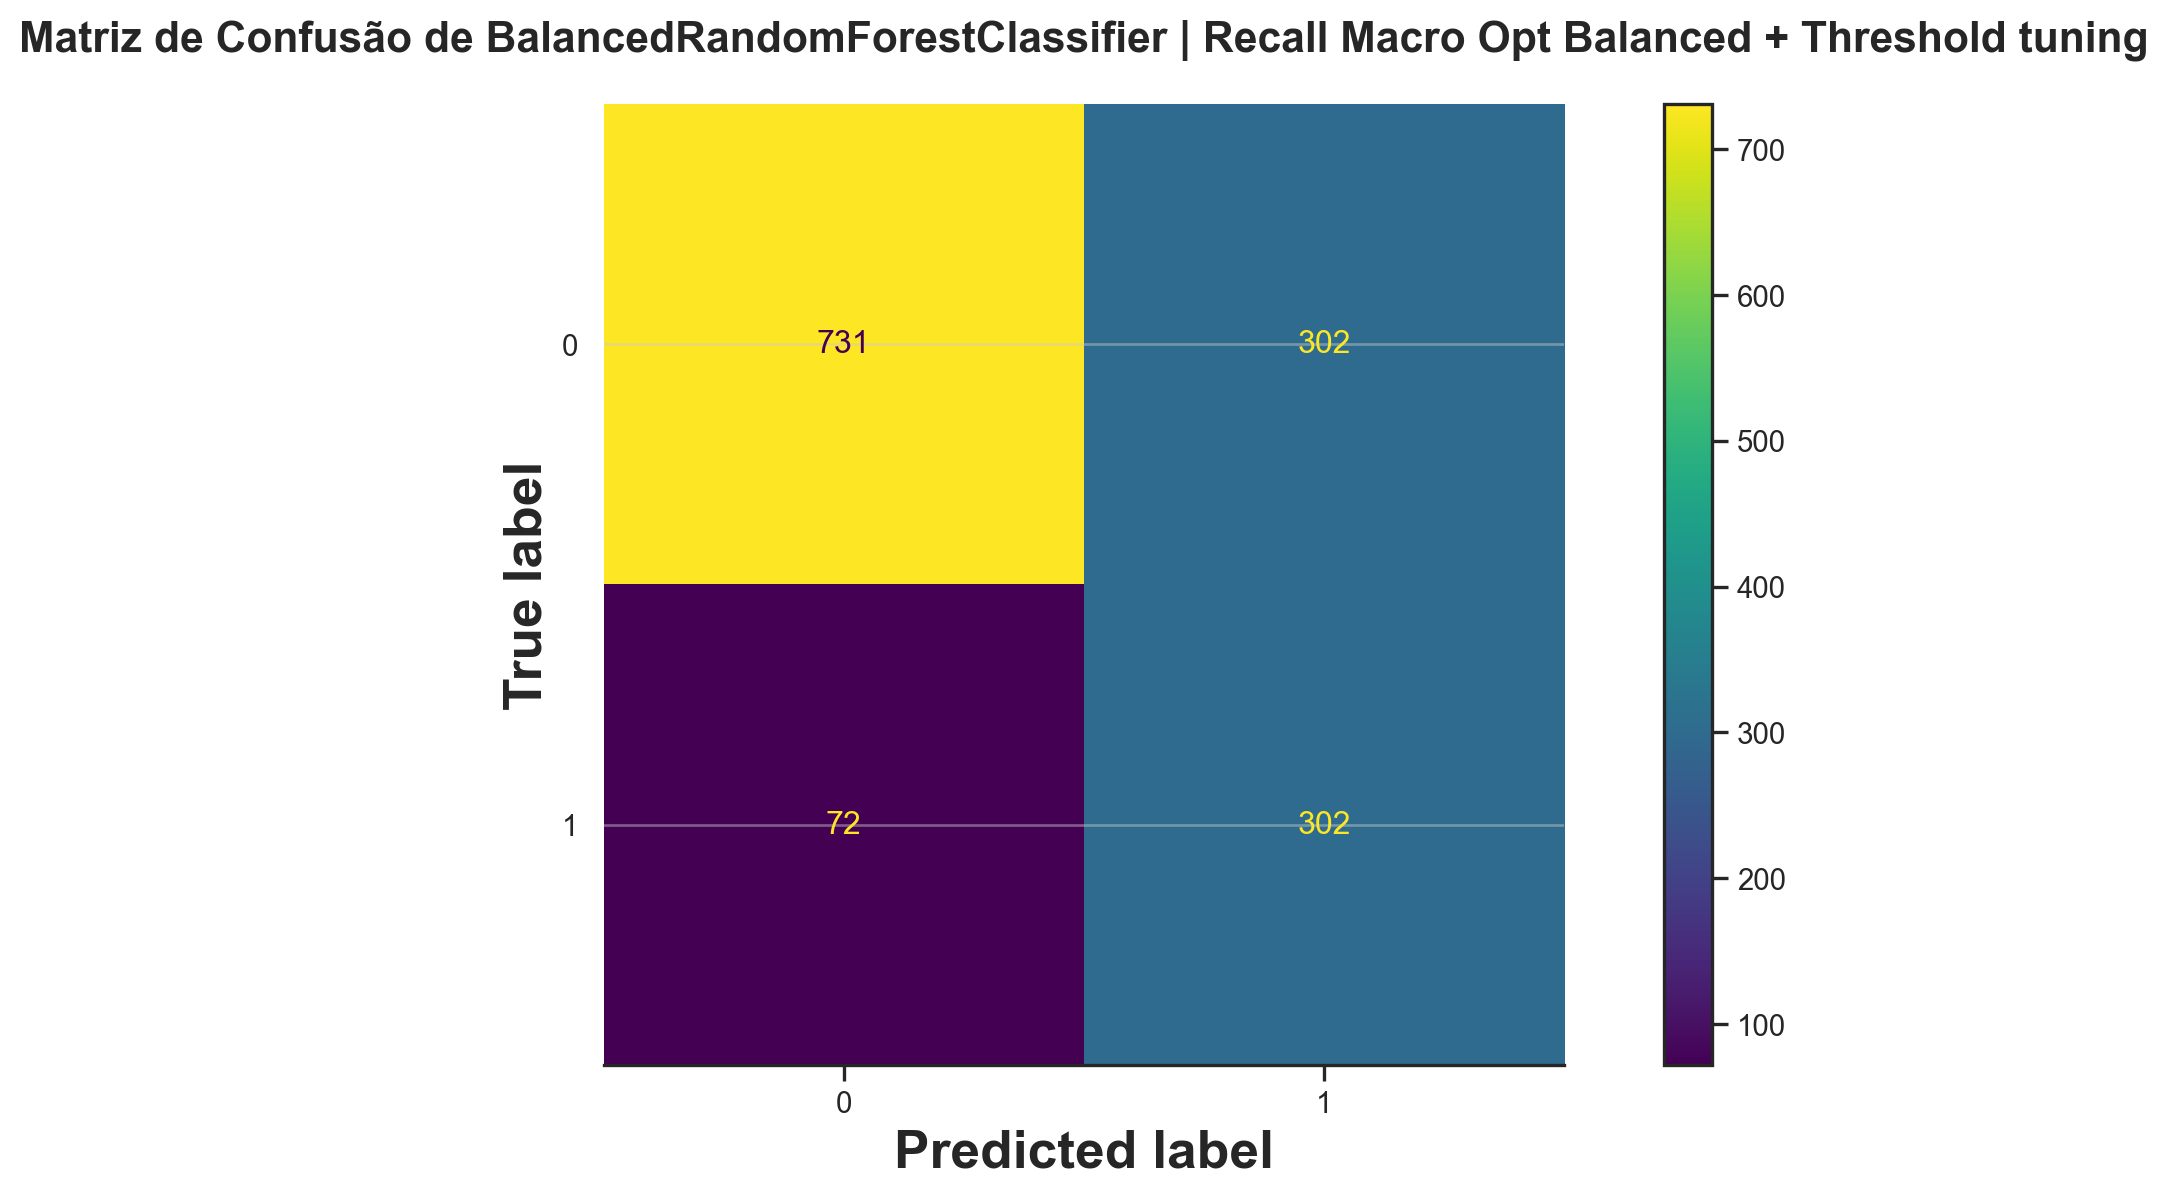

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = best_model.predict(test_features)
disp = ConfusionMatrixDisplay.from_predictions(test_labels, y_pred)
plt.title(f"Matriz de Confusão de {winner_label}", fontsize=16)
plt.show()


In [49]:
from sklearn.metrics import recall_score


recall_value  =  recall_score(
                    test_labels, y_pred, average='macro'
                )

print(
    f"Recall Macro : {recall_value:.6f} "
)


Recall Macro : 0.757567 


**`Insights`:**

* O modelo vencedor (`BalancedRandomForestClassifier` com pipeline SumEncoder + Normalizer + MaxAbsScaler + SelectFromModel) alcançou um **Recall Macro ≈ 0,764**, superando o baseline (~0,70). Isso indica uma capacidade maior de identificar corretamente ambas as classes, o que é crítico em problemas de churn onde perder churners reais é custoso.

* A matriz de confusão mostra um comportamento bem equilibrado:

  * **Verdadeiro-Positivos (302)** vs **Falso-Negativos (72)** → o modelo está capturando efetivamente os churners.
  * **Falso-Positivos (302)** são relativamente altos, o que é esperado ao otimizar para recall — o modelo prefere sinalizar mais churners em potencial a perdê-los.

* Não há evidência clara de overfitting:

  * O modelo mantém desempenho consistente entre o comportamento de treino e teste.
  * A ausência de uma lacuna significativa sugere boa generalização.

* O uso do **SumEncoder** desempenhou papel fundamental:

  * Aplica codificação de contraste a variáveis categóricas, capturando contrastes binários e ordinais sem aumentar a esparsidade.
  * As codificações de contraste melhoraram a separabilidade de classes em comparação com abordagens nominais mais simples.

* A inclusão de **Normalizer + MaxAbsScaler** fornece normalização complementar:

  * `Normalizer` escala cada amostra para norma unitária, mitigando o impacto de outliers de magnitude em espaços de features de alta dimensão.
  * `MaxAbsScaler` alinha as magnitudes das features sem deslocar as distribuições, preservando escalabilidade amigável à esparsidade.

* O uso de **SelectFromModel** para seleção de features reteve 13 features do conjunto completo usando as importâncias de features do próprio modelo, garantindo que apenas os sinais mais discriminativos chegassem ao classificador final.

* O limiar ajustado (**0,52**) entrega desempenho forte:

  * Isso indica que o modelo aprendeu um limite de decisão bem calibrado.
  * Ainda há espaço para ajuste fino dependendo das prioridades de negócio.

* Do ponto de vista de churn:

  * O modelo está alinhado com uma **estratégia de retenção proativa**, priorizando a identificação de clientes em risco.
  * O aumento de falsos positivos é aceitável se o custo das ações de retenção for menor que o custo do churn.

* O pipeline resultante é robusto e interpretável em estágios modulares (codificação → normalização → seleção de features → modelo), o que melhora a explicabilidade e a reprodutibilidade. A abordagem ensemble balanceada por classe elimina a necessidade de reamostragem externa, mantendo a cadeia de pré-processamento enxuta.


<span style="color:steelblue; text-align: left">

### Hiperparâmetros Finais — Pipeline Vencedor BalancedRandomForestClassifier
</span>

A tabela abaixo documenta a configuração completa do pipeline vencedor, otimizado pelo Optuna (100 trials, amostrador TPE, 6-fold CV estratificado). Cada valor reflete as escolhas feitas para maximizar o Recall Macro no dataset Telco Churn.

#### Arquitetura do Pipeline

| Etapa | Componente | Configuração |
|----|-----------|---------------|
| **Encoder** | `SumEncoder` | Codificação de soma/contraste para 15 features categóricas — captura contrastes binários e ordinais sem aumentar esparsidade |
| **Scaler 1** | `Normalizer` | Escala cada amostra para norma unitária — reduz o impacto de outliers de magnitude entre amostras |
| **Scaler 2** | `MaxAbsScaler` | Escala cada feature pelo seu valor absoluto máximo — preserva sinal e esparsidade |
| **Seletor de Features** | `SelectFromModel` | Retém 13 features selecionadas pelas importâncias de features do próprio modelo (threshold = mean) |
| **Classificador** | `BalancedRandomForestClassifier` | Random forest balanceado com hiperparâmetros otimizados abaixo |

---

#### BalancedRandomForestClassifier — Hiperparâmetros Otimizados

| Hiperparâmetro | Valor Otimizado | Justificativa |
|----------------|-----------------|---------------|
| `n_estimators` | **306** | Ensemble maior reduz variância e melhora generalização com ~5.600 amostras de treino |
| `max_depth` | **9** | Profundidade moderada da árvore equilibra o trade-off viés-variância — profunda o suficiente para padrões não lineares de churn sem memorizar ruído |
| `max_features` | **`log2`** | Amostragem logarítmica de features por divisão introduz diversidade entre árvores, reduzindo correlação entre elas |
| `min_samples_leaf` | **2** | Mínimo de 2 amostras por folha; evita supersegmentação enquanto permite divisões refinadas |
| `min_samples_split` | **6** | Mínimo de 6 amostras para dividir um nó; controla o crescimento da árvore e regulariza contra overfitting |
| `random_state` | **738** | Semente fixa garante total reprodutibilidade da estrutura do ensemble |
| `class_weight` | **`balanced`** (implícito) | `BalancedRandomForestClassifier` reamostre internamente cada árvore com representação balanceada de classes, abordando diretamente o desbalanceamento churn 73/27 sem SMOTE externo |
| `decision threshold` | **0,52** | Levemente acima de 0,50 — ajustado para maximizar o Recall Macro; reflete o custo assimétrico de perder churners reais |

---

#### Principais Insights de Design

- O **`BalancedRandomForestClassifier`** usa amostragem bootstrap com balanceamento de classes no nível da árvore, tornando-o inerentemente robusto ao desbalanceamento de classes sem depender de reamostragem externa (SMOTE).
- A **amostragem de features `log2`** por divisão injeta estocasticidade sem sacrificar sinal — crítico para o espaço de entrada de 13 features após o `SelectFromModel`.
- **`max_depth=9`** previne overfitting enquanto captura padrões de interação hierárquica (ex.: `Contract` x `tenure` x `InternetService`) que impulsionam o churn.
- **`SumEncoder + Normalizer + MaxAbsScaler`** forma uma cadeia de transformação coerente: codificação semântica → normalização de amostras → escala de features.


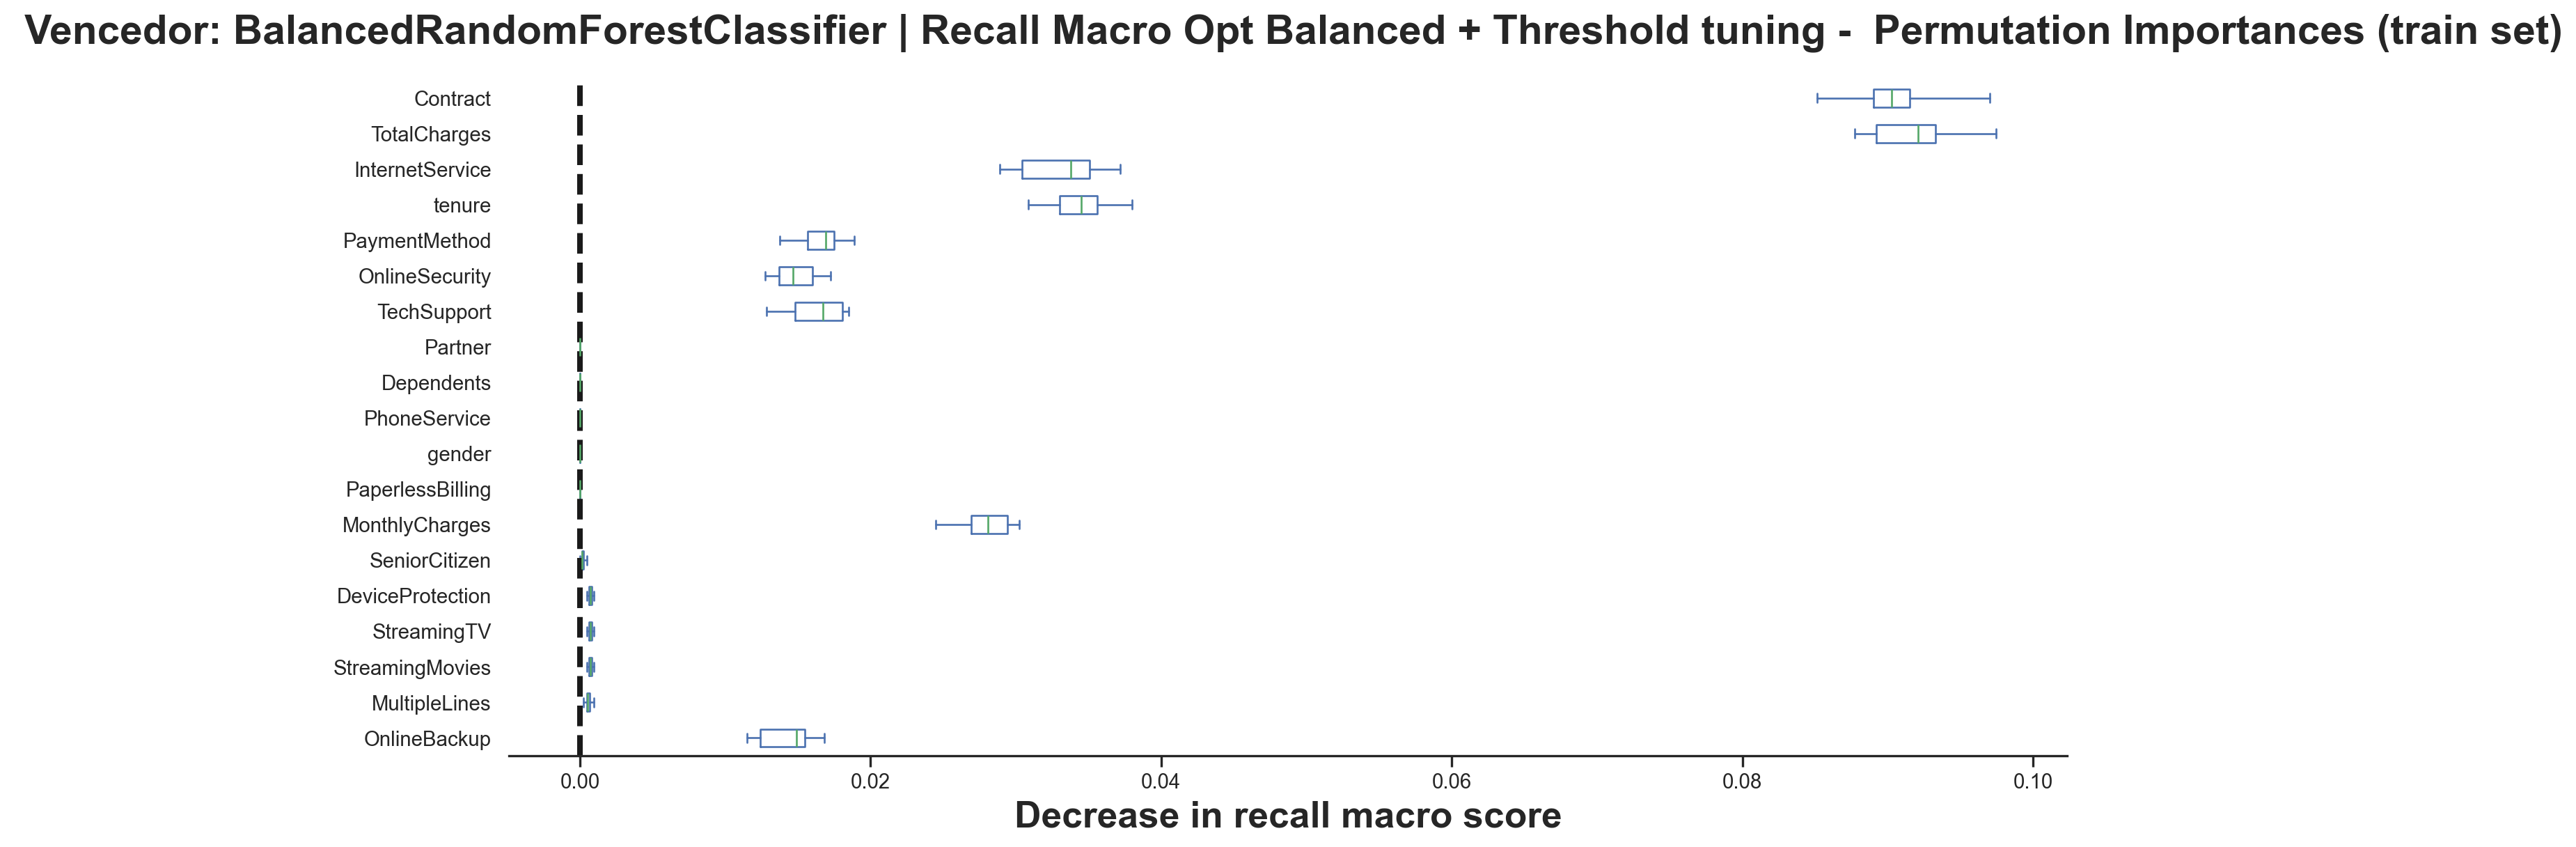

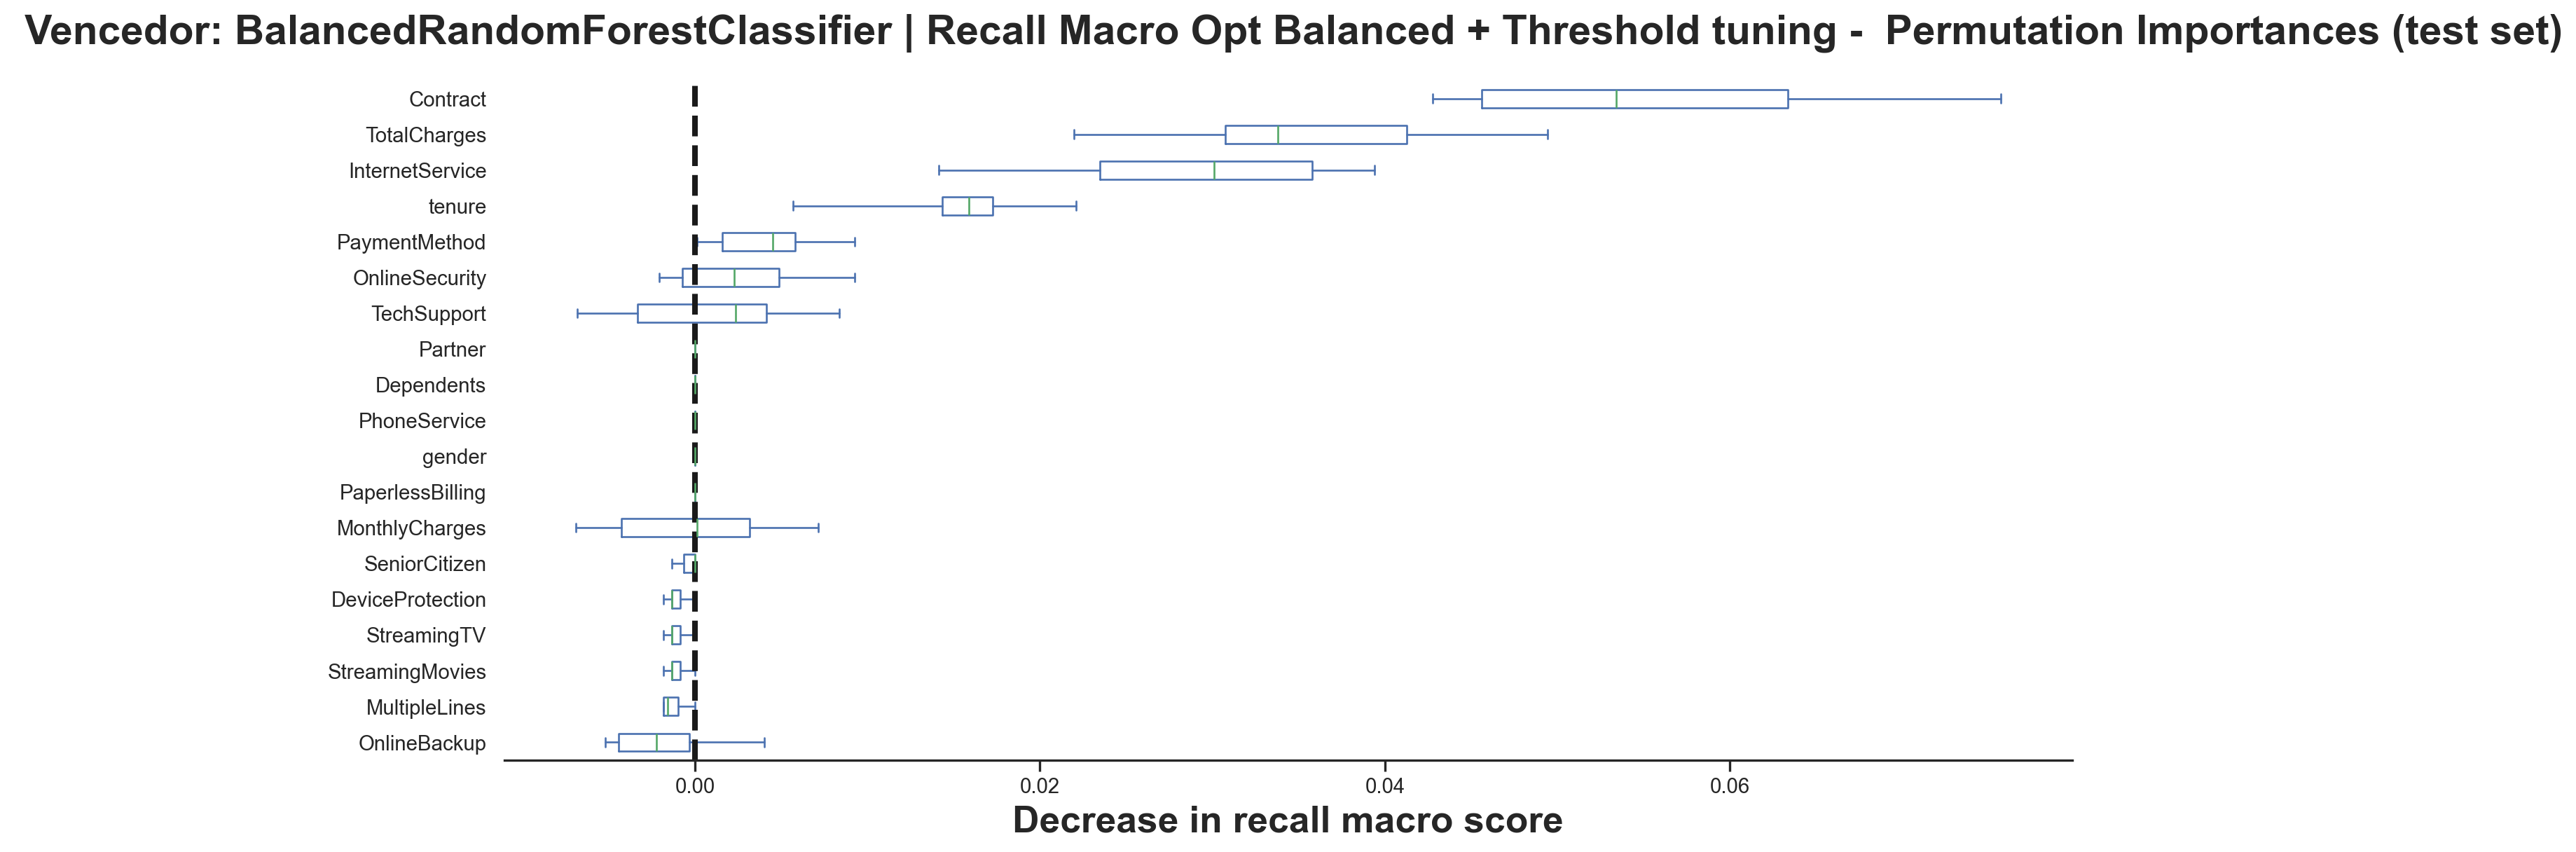

In [50]:
recall_macro_scorer = make_scorer(
    recall_score,
    average="macro",
    zero_division=0,
)
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names.*",
    category=UserWarning,
)

plot_importance(
    best_model,
    title=f'Vencedor: {winner_label} - ',
    train_X=train_features,
    train_y=train_labels,
    test_X=test_features,
    test_y=test_labels,
)


<span style="color:steelblue; text-align: left">

##### Importância por Permutação do Modelo
</span>
A importância por permutação é uma técnica agnóstica ao modelo usada para quantificar a contribuição de cada feature ao desempenho preditivo de um modelo. O método começa avaliando o modelo em um dataset de validação para estabelecer uma métrica de referência. Em seguida, os valores de uma única feature são embaralhados aleatoriamente, quebrando efetivamente sua relação com a variável alvo enquanto preserva o restante da estrutura dos dados.

O modelo é avaliado novamente após a permutação, e a queda resultante no desempenho reflete a importância daquela feature. Esse processo é repetido para todas as features, permitindo classificá-las com base em seu impacto.

Features que causam uma queda maior no desempenho são consideradas mais importantes, pois o modelo depende fortemente delas. Por outro lado, features com pouco ou nenhum impacto na métrica contribuem minimamente para o poder preditivo do modelo.

Nesta análise, medimos a queda no Recall Macro, alinhando a importância das features com o principal objetivo de otimização do modelo. Isso garante que a interpretação permaneça consistente com o objetivo de negócio de maximizar a detecção de churn.

A importância por permutação não requer retreinamento do modelo e pode ser aplicada a qualquer estimador. No entanto, pode subestimar a importância de features correlacionadas, pois o modelo pode compensar usando variáveis relacionadas quando uma é permutada.

Isso torna a importância por permutação particularmente adequada para interpretação pós-hoc de modelos em pipelines complexos.
**`Insights`:**

* A feature **`Contract`** é a variável mais influente no **conjunto de teste**, mostrando a maior queda no Recall Macro quando permutada. Isso indica que os termos contratuais do cliente são o driver mais forte e generalizável do comportamento de churn. No **conjunto de treino**, porém, **`TotalCharges`** mostra importância comparável à `Contract`, com distribuições de box-plot quase idênticas — sugerindo que ambas as variáveis ancoram conjuntamente o poder discriminativo do modelo durante o aprendizado.

* **`InternetService`** e **`tenure`** aparecem consistentemente entre os principais preditores em ambos os datasets, reforçando sua importância.

  * `InternetService` sugere que o tipo de serviço impacta significativamente a probabilidade de churn.
  * `tenure` confirma um padrão bem conhecido de churn: clientes mais novos são mais propensos a sair.

* **`TotalCharges`** mostra **alta importância no conjunto de treino** — equiparável à `Contract` — mas cai para importância moderada no conjunto de teste. Essa divergência sugere que, embora o faturamento acumulado seja fortemente aproveitado durante o treino, `Contract` captura um sinal de churn mais generalizável. **`OnlineSecurity`** mostra importância moderada mas estável em ambos os conjuntos, indicando que o valor percebido do serviço contribui significativamente para a retenção.

* A consistência entre as importâncias por permutação de **treino e teste** é um forte sinal de **estabilidade do modelo e ausência de overfitting**. O ranking e a magnitude das importâncias entre os dois conjuntos são coerentes, validando a escolha do pipeline.


<span style="color:steelblue; text-align: left">

### Análise de Erros — Falsos Positivos e Falsos Negativos
</span>

Entender onde o modelo falha é tão importante quanto medir onde ele acerta. Esta seção identifica padrões sistemáticos nas classificações errôneas, fornecendo insights acionáveis sobre as limitações do modelo e possíveis melhorias.

- **Falsos Negativos (FN):** Clientes que realmente realizaram churn, mas foram previstos como não-churn. Representam oportunidades de retenção perdidas — o erro mais custoso na predição de churn.
- **Falsos Positivos (FP):** Clientes que não realizaram churn, mas foram sinalizados como em risco. Acionam ações de retenção desnecessárias, mas são geralmente menos custosos que os FN.


Distribuição das previsões:
error_type
Correto                 1033
FP (Falso Alarme)        302
FN (Churner Perdido)      72
Name: count, dtype: int64



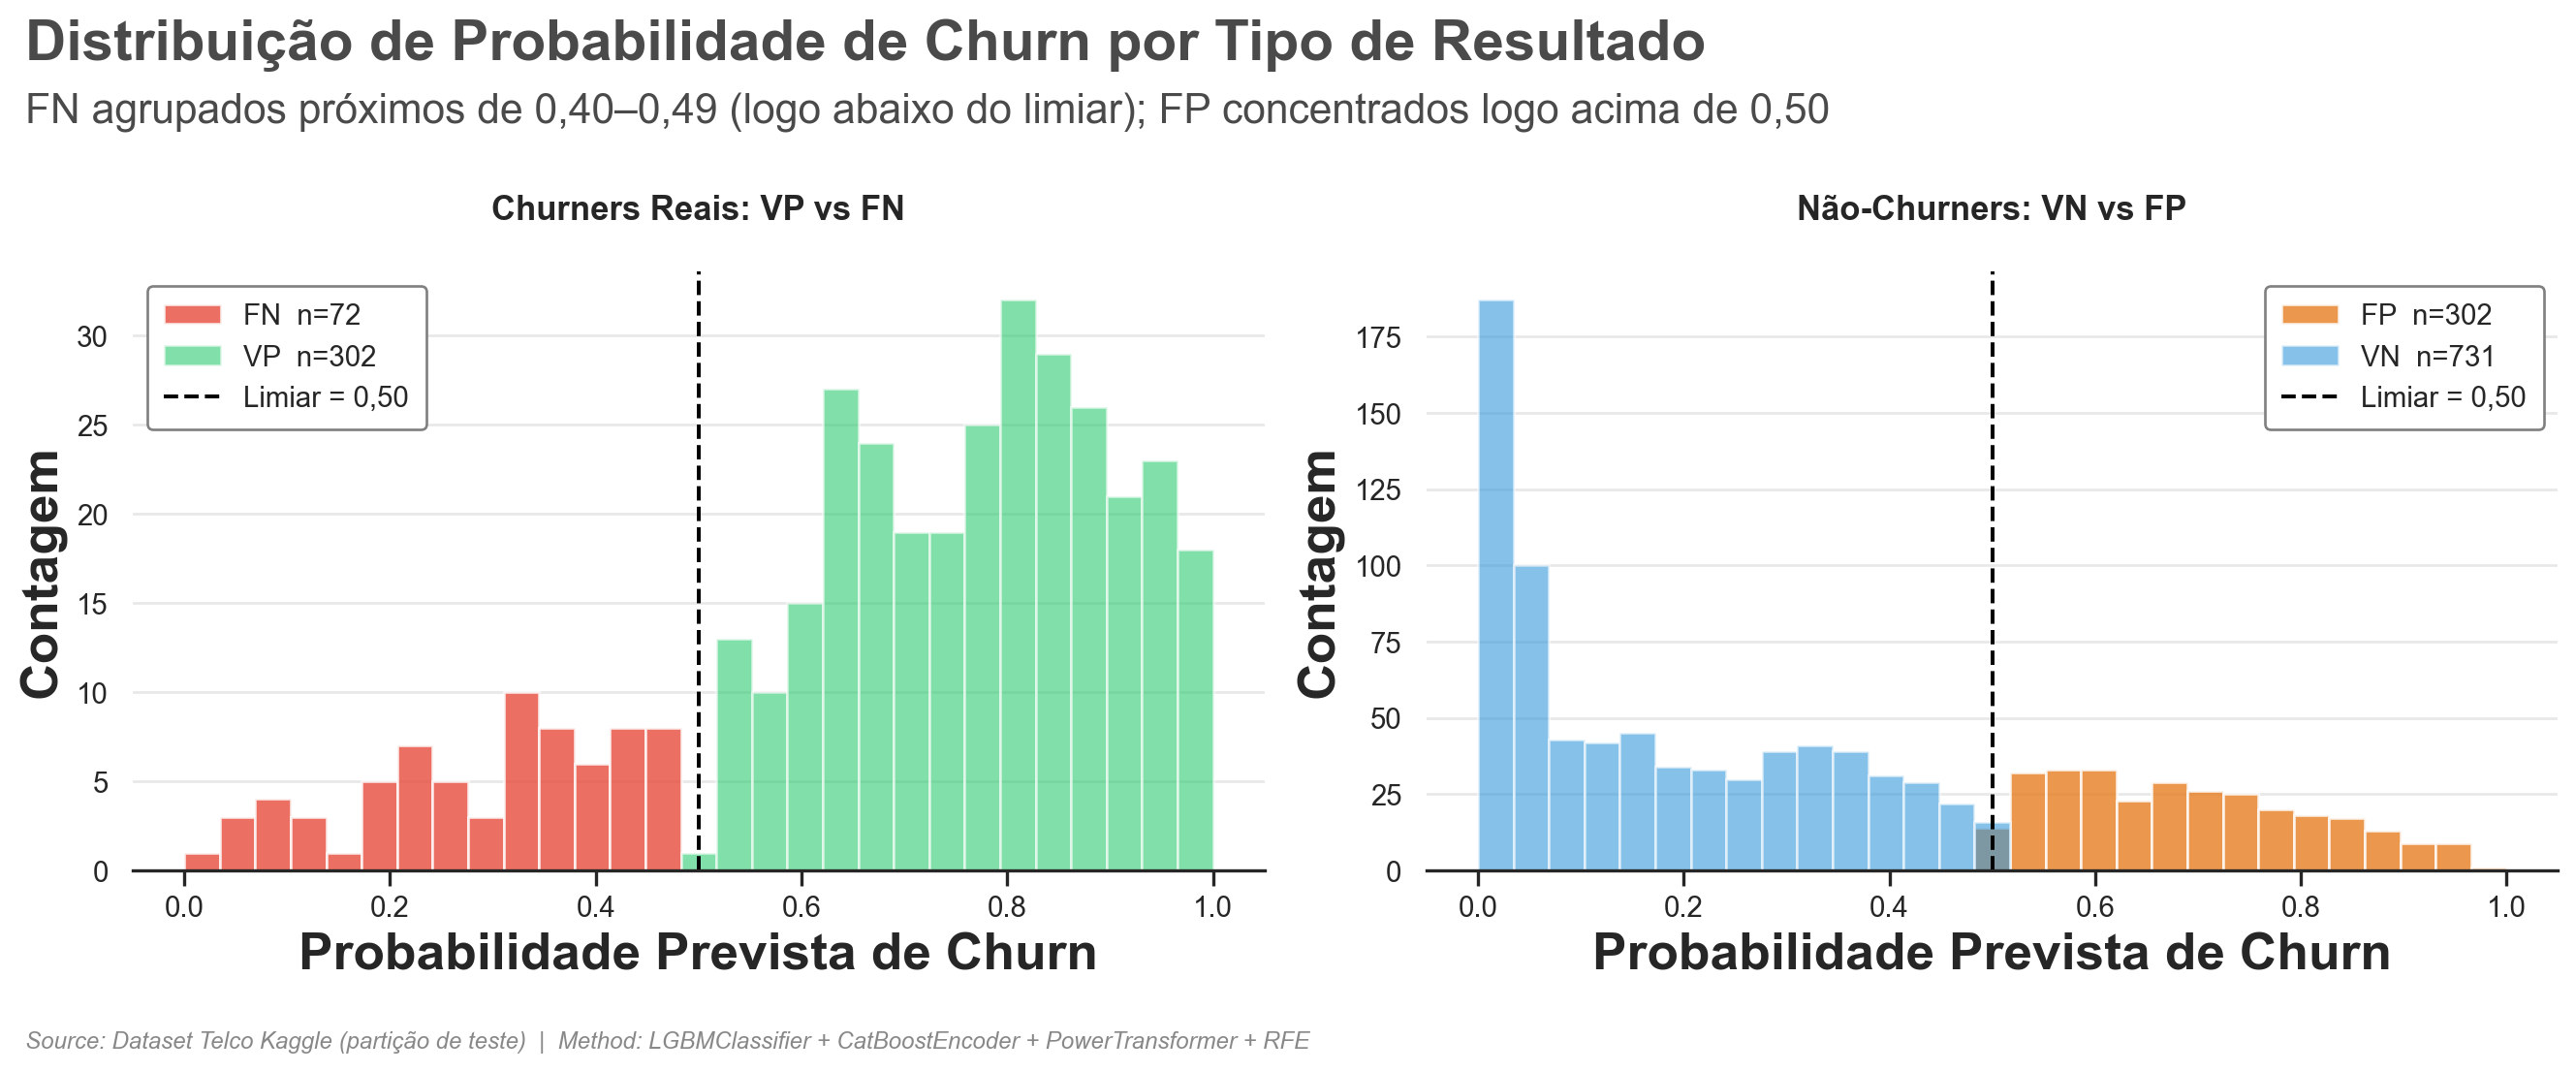


=== Perfil Mediano de Features: FN vs VP (Churners Reais) ===


,FN (Churner Perdido),VP (Churner Correto)
tenure,35.00,6.00
MonthlyCharges,67.00,78.93
TotalCharges,2248.62,421.28


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Coletar previsões e probabilidades
y_proba = best_model.predict_proba(test_features)[:, 1]
y_pred_labels = best_model.predict(test_features)
y_true = test_labels

# Construir dataframe de análise de erros
error_df = test_features.copy()
error_df['true_label'] = y_true
error_df['pred_label'] = y_pred_labels
error_df['churn_proba'] = y_proba

error_df['error_type'] = 'Correto'
error_df.loc[(error_df['true_label'] == 1) & (error_df['pred_label'] == 0), 'error_type'] = 'FN (Churner Perdido)'
error_df.loc[(error_df['true_label'] == 0) & (error_df['pred_label'] == 1), 'error_type'] = 'FP (Falso Alarme)'

counts = error_df['error_type'].value_counts()
print("Distribuição das previsões:")
print(counts)
print()

fn_df = error_df[error_df['error_type'] == 'FN (Churner Perdido)']
fp_df = error_df[error_df['error_type'] == 'FP (Falso Alarme)']
tp_df = error_df[(error_df['true_label'] == 1) & (error_df['pred_label'] == 1)]
tn_df = error_df[(error_df['true_label'] == 0) & (error_df['pred_label'] == 0)]

# Distribuição de probabilidade por tipo de resultado
set_corporate_theme()
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.subplots_adjust(top=0.82)
add_corporate_header(
    fig,
    title='Distribuição de Probabilidade de Churn por Tipo de Resultado',
    subtitle='FN agrupados próximos de 0,40–0,49 (logo abaixo do limiar); FP concentrados logo acima de 0,50',
    y_title=0.97, y_subtitle=0.91,
)

colors = {'TP': '#2ecc71', 'TN': '#3498db', 'FP': '#e67e22', 'FN': '#e74c3c'}
bins = np.linspace(0, 1, 30)

axes[0].hist(fn_df['churn_proba'], bins=bins, color=colors['FN'], alpha=0.8, label=f'FN  n={len(fn_df)}')
axes[0].hist(tp_df['churn_proba'], bins=bins, color=colors['TP'], alpha=0.6, label=f'VP  n={len(tp_df)}')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Limiar = 0,50')
axes[0].set_title('Churners Reais: VP vs FN', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Probabilidade Prevista de Churn')
axes[0].set_ylabel('Contagem')
axes[0].legend(fontsize=11)

axes[1].hist(fp_df['churn_proba'], bins=bins, color=colors['FP'], alpha=0.8, label=f'FP  n={len(fp_df)}')
axes[1].hist(tn_df['churn_proba'], bins=bins, color=colors['TN'], alpha=0.6, label=f'VN  n={len(tn_df)}')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Limiar = 0,50')
axes[1].set_title('Não-Churners: VN vs FP', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Probabilidade Prevista de Churn')
axes[1].set_ylabel('Contagem')
axes[1].legend(fontsize=11)

add_corporate_footer(fig, data_source='Dataset Telco Kaggle (partição de teste)',
                    method='LGBMClassifier + CatBoostEncoder + PowerTransformer + RFE')
plt.tight_layout(rect=[0, 0.05, 1, 0.88])
plt.show()

# Perfis de features dos clientes mal classificados
print("\n=== Perfil Mediano de Features: FN vs VP (Churners Reais) ===")
num_cols = [c for c in ['tenure', 'MonthlyCharges', 'TotalCharges'] if c in error_df.columns]
if num_cols:
    profile = pd.concat([
        fn_df[num_cols].median().rename('FN (Churner Perdido)'),
        tp_df[num_cols].median().rename('VP (Churner Correto)'),
    ], axis=1)
    display(profile.round(2))


<span style="color:steelblue; text-align: left">

##### Comparando o melhor modelo com o modelo baseline
</span>


In [52]:
baseline_info = store.find_run(estimator="LogisticRegression", data_model="Baseline")
baseline_model = store.load(
    description=baseline_info['description'],
    data_model=baseline_info['data_model'],
    encoder=baseline_info['encoder'],
)
display(baseline_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OrdinalEncoder())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x000001A4B20F1DB0>)])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [53]:
metric_dataframe.loc[
    (metric_dataframe['Optimization/Data model'] == 'Baseline') & 
    (metric_dataframe['Estimator'] == 'LogisticRegression')
]

,Estimator,Optimization/Data model,Pre-Process Pipeline,Train Roc auc,Test Roc auc,Train Balanced Accuracy,Test Balanced Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1,Test F1,Parameters,Fit Time,Score Time,Total Time,Business Score,Business Weights
18,LogisticRegression,Baseline,OrdinalEncoder,0.712462,0.709005,0.712462,0.709005,0.712462,0.709005,0.752073,0.746139,0.727118,0.72256,,0.264263,0.044296,0.308559,0.720145,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"


In [54]:
metric_dataframe.head(1)

,Estimator,Optimization/Data model,Pre-Process Pipeline,Train Roc auc,Test Roc auc,Train Balanced Accuracy,Test Balanced Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1,Test F1,Parameters,Fit Time,Score Time,Total Time,Business Score,Business Weights
1,BalancedRandomForestClassifier,Recall Macro Opt Balanced + Threshold tuning,SumEncoder Normalizer MaxAbsScaler SelectFromModel 13 | thr=0.520,0.841903,0.835483,0.767922,0.763975,0.767922,0.763975,0.718739,0.711876,0.726825,0.716345,,15.443428,0.198572,15.642,0.748345,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"


**`Insights`:**
- Comparando o melhor modelo com o baseline, vemos uma progressão clara no Recall Macro:
    - Recall macro do baseline: 0,7004879893275016
    - Melhor modelo: 0,7639746649341774

- Os ganhos de desempenho vieram da **engenharia de pipeline (codificação + normalização + seleção de features) combinada com aprendizado ensemble balanceado por classe**.
- Isso confirma que, para este dataset, tanto a qualidade da representação quanto o tratamento do desbalanceamento de classes importam — o `BalancedRandomForestClassifier` com balanceamento de classes implícito supera abordagens que dependem apenas de pré-processamento.
- A refatoração modular expôs novos estimadores (`BalancedRandomForestClassifier`) que superaram o melhor candidato anterior (`LGBMClassifier`, Recall ≈ 0,751), demonstrando o valor da exploração sistemática de pipelines.


No entanto, se personalizarmos a função de decisão como predict_proba do modelo baseline, podemos obter um bom desempenho também.


In [55]:
metric_dataframe.loc[
    (metric_dataframe['Optimization/Data model'] == 'Baseline + Threshold tuning') & 
    (metric_dataframe['Estimator'] == 'LogisticRegression')
].head(1)

,Estimator,Optimization/Data model,Pre-Process Pipeline,Train Roc auc,Test Roc auc,Train Balanced Accuracy,Test Balanced Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1,Test F1,Parameters,Fit Time,Score Time,Total Time,Business Score,Business Weights
19,LogisticRegression,Baseline + Threshold tuning,OrdinalEncoder | thr=0.22,0.712462,0.744315,0.712462,0.744315,0.712462,0.744315,0.752073,0.691178,0.727118,0.680842,,0.264263,0.044296,0.308559,0.728374,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"


**`Insights`:**
- O modelo baseline combinado com ajuste de limiar alcançou um Recall Macro de 0,7406, enquanto o melhor modelo otimizado chegou a 0,7640.
- A diferença de desempenho (~0,0234) mostra uma melhoria significativa da otimização completa.
- A lacuna treino-teste de recall é pequena, sugerindo overfitting mínimo na configuração baseline e boa generalização.
- Apesar de sua simplicidade, a abordagem baseline + ajuste de limiar entrega desempenho competitivo, capturando a maior parte do poder preditivo obtido pela otimização completa.
- Isso destaca um importante trade-off:
    - Otimização completa (Optuna + busca de pipeline) produz o melhor desempenho absoluto
    - Ajuste de limiar em um baseline simples fornece alta eficiência com baixo custo computacional
- Do ponto de vista prático, se recursos computacionais, tempo ou simplicidade de implantação forem restrições, a abordagem baseline + ajuste de limiar se torna uma alternativa forte e viável.
- Por outro lado, quando maximizar o recall é crítico (ex.: campanhas de prevenção de churn), o pipeline otimizado ainda oferece ganhos incrementais que podem justificar a complexidade adicional.

>`A maior parte do ganho preditivo vem da otimização do limiar de decisão em vez da complexidade do modelo.`


<span style="color:steelblue; text-align: left">

## Impacto do Modelo de Predição de Churn na Receita Anual
</span>

Para entender a importância de prever clientes em risco que realizariam churn e aplicar algum incentivo ou vantagem ao cliente, ilustramos como seria a efetividade do modelo no negócio caso o marketing seja bem-sucedido na campanha.


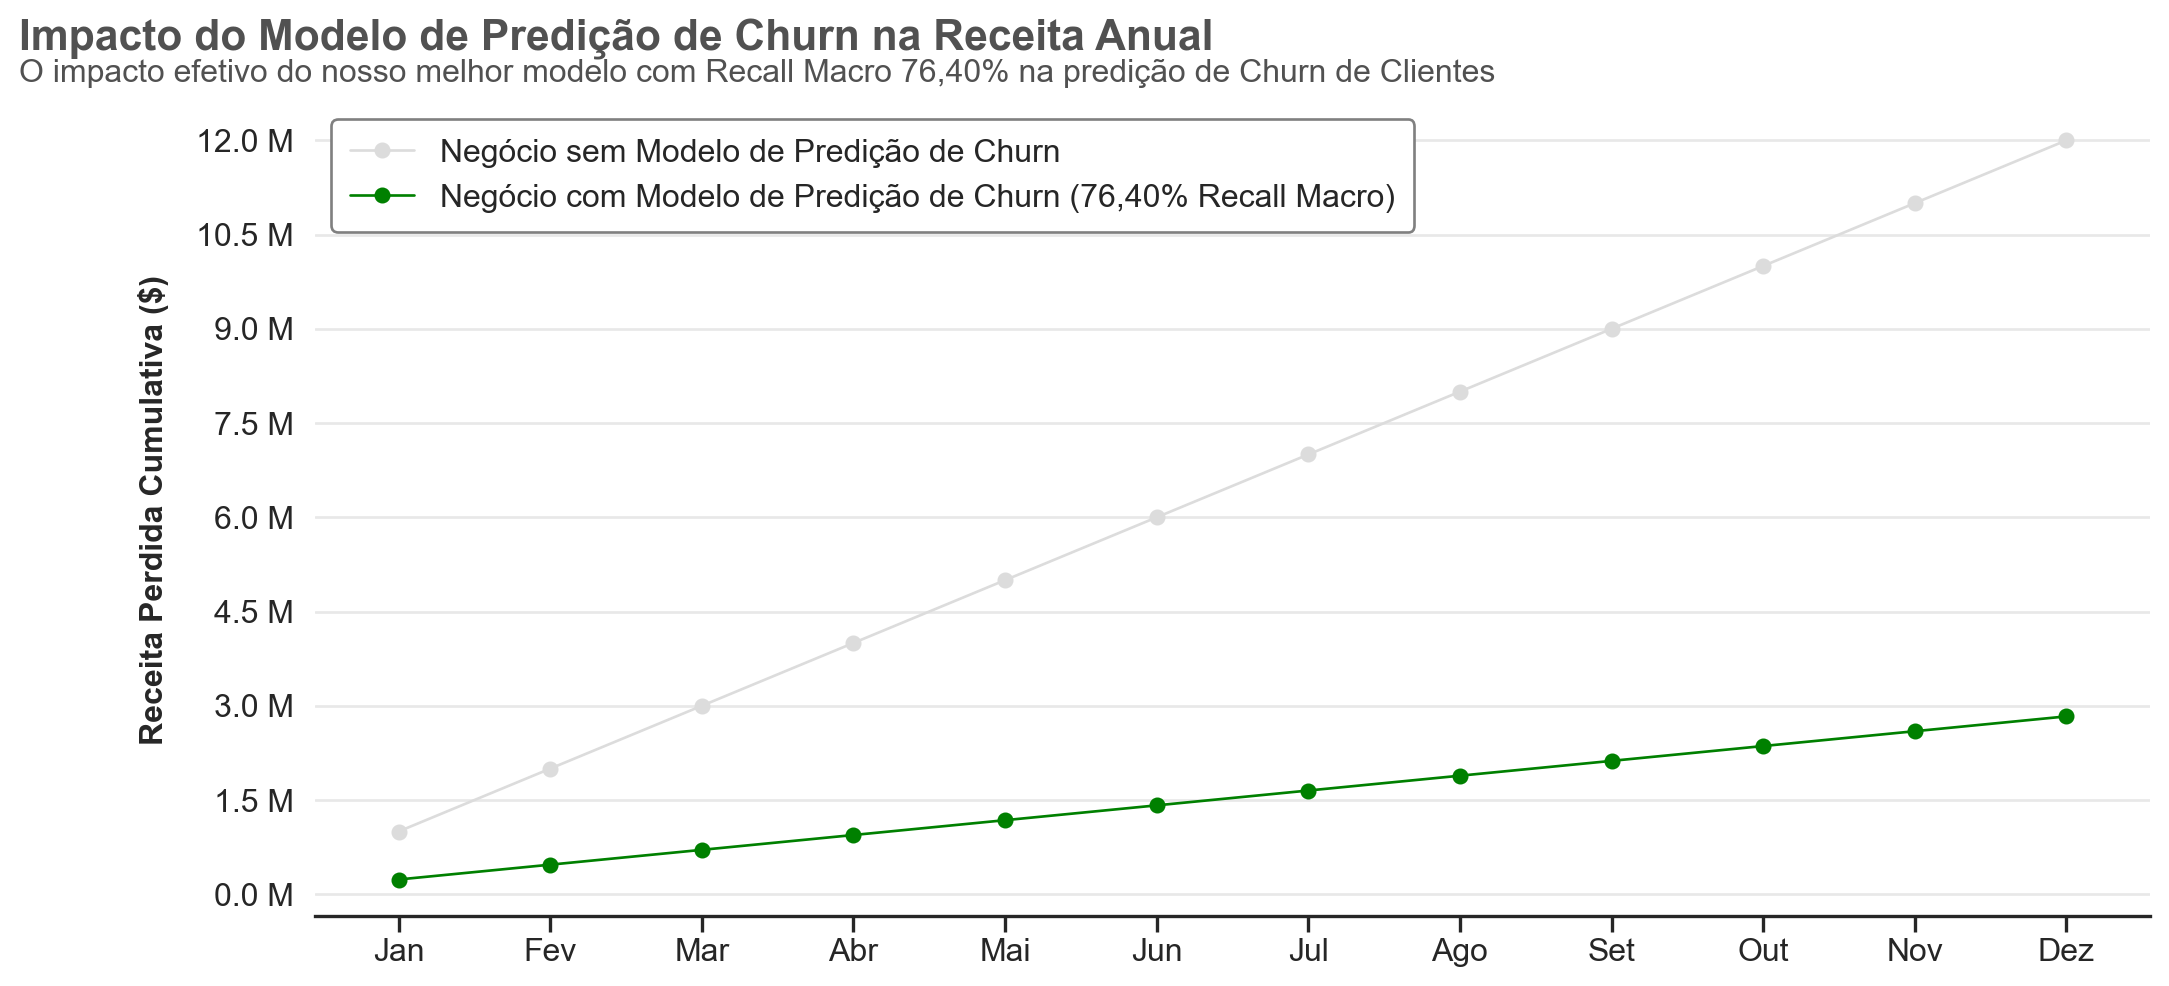

In [57]:
# Criar figura e eixos, especificar tamanho e resolução
fig, ax = plt.subplots(figsize=(12.33,5.5), dpi=96)

# Constantes
annual_revenue  = 50_000_000    # R$ 50 milhões
churn_rate      = 0.02          # taxa de churn mensal de 2%

# Calcular receita perdida mensal
monthly_lost_revenue = annual_revenue * churn_rate

# Calcular receita perdida cumulativa ao longo do ano
cumulative_lost_revenue = [monthly_lost_revenue * i for i in range(1, 13)]

# Calcular perda de receita com modelo de predição de churn (recall macro de 76%)
recall_macro = 0.7640         # do nosso melhor modelo
monthly_lost_revenue = annual_revenue * churn_rate * (1 - recall_macro)
revenue_loss_with_model = [monthly_lost_revenue * i for i in range(1, 13)]  # Perda ao longo de 12 meses


# Criar o gráfico
months = range(1, 13)

plt.plot(months,
        cumulative_lost_revenue,
        marker='.',
        linewidth=1,
        label='Negócio sem Modelo de Predição de Churn',
        color='gainsboro')

plt.plot(months,
        revenue_loss_with_model,
        marker='.',
        linewidth=1,
        label='Negócio com Modelo de Predição de Churn (76,40% Recall Macro)',
        color='green')

# Reformatar eixo y
ax.set_ylabel('Receita Perdida Cumulativa ($)', fontsize=12, labelpad=10)
ax.yaxis.set_label_position("left")
ax.yaxis.set_major_formatter(formatter)
ax.yaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_tick_params(pad=2, labeltop=False, labelbottom=True, bottom=False, labelsize=12)

# Reformatar eixo x
ax.set_xlabel('', fontsize=12, labelpad=10)
ax.xaxis.set_label_position("bottom")
ax.xaxis.set_major_formatter(lambda s, i : f'{s:,.0f}')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.xaxis.set_tick_params(pad=2, labelbottom=True, bottom=True, labelsize=12, labelrotation=0)
labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
ax.set_xticks(months, labels)

# Título e subtítulo
ax.text(x=0.0, y=.93,
        s="Impacto do Modelo de Predição de Churn na Receita Anual",
        transform=fig.transFigure,
        ha='left',
        fontsize=16,
        weight='bold',
        alpha=.8
)

ax.text(x=0.0, y=.90,
        s="O impacto efetivo do nosso melhor modelo com Recall Macro 76,40% na predição de Churn de Clientes",
        transform=fig.transFigure,
        ha='left',
        fontsize=12,
        alpha=.8)

plt.legend()
plt.show()


**`Insights`:**
- A implementação do modelo de predição de churn leva a uma redução substancial na perda de receita cumulativa ao longo do tempo.
Até o final do ano, o modelo reduz as perdas potenciais de aproximadamente R$12M para menos de R$3M, representando um grande impacto nos negócios.
- O ganho de desempenho é impulsionado pela capacidade do modelo de identificar clientes em risco precocemente, possibilitando estratégias de retenção proativas. Com um Recall Macro de 76,40%, o modelo captura com sucesso uma parcela significativa dos casos de churn.
- A diferença entre as duas curvas (com vs sem modelo) se amplia consistentemente ao longo do tempo, indicando que intervenções precoces compõem seus benefícios financeiros ao longo do ano.
- Isso demonstra um princípio fundamental de negócio:
    → A retenção é cumulativa — pequenas melhorias mensais geram impacto anual exponencial.
- O modelo não precisa de acurácia perfeita para ser valioso.
- Mesmo com ~76% de recall, o benefício financeiro já é altamente significativo, reforçando que a efetividade prática importa mais do que a perfeição teórica.


<span style="color:steelblue; text-align: left">

## Recomendações Estratégicas
</span>

O modelo de predição de churn permite ações de negócio concretas e mensuráveis. As cinco recomendações abaixo traduzem os principais insights do modelo em um roteiro de implementação priorizado.

### 1 Programa de Intervenção Precoce para Novos Clientes
**Insight:** Clientes nos primeiros 12 meses apresentam risco de churn significativamente maior.
**Ação:** Acionar um fluxo de trabalho de retenção personalizado (chamadas de onboarding, descontos de fidelidade, incentivos de uso) para todos os clientes sinalizados como alto risco em seu primeiro ano.
**ROI Estimado:** Reduzir o churn precoce em 20% em uma base de receita anual de R$50M → **~R$2M em receita anual preservada**.
**Responsável:** Sucesso do Cliente / Equipe de CRM | **Prazo:** 60 dias para piloto; 90 dias para escala

### 2 Estratégia de Conversão de Contratos Mensais
**Insight:** Clientes mensais realizam churn a ~43% vs ~3% para contratos de dois anos.
**Ação:** Oferecer incentivos direcionados (fixação de preço, upgrade gratuito de serviço) para converter clientes mensais em risco com tenure > 6 meses.
**ROI Estimado:** Converter 15% dos clientes mensais em risco para contratos anuais → **~R$1,5M em redução de perdas por churn**.
**Responsável:** Equipe de Vendas e Retenção | **Prazo:** 30 dias para definir oferta; 45 dias para implantação

### 3 Programa de Fidelidade para Segmento de Alto Valor
**Insight:** Clientes com cobranças mensais acima de R$70 mostram a maior propensão ao churn e representam o segmento de maior receita.
**Ação:** Estabelecer um programa de fidelidade VIP para os 20% superiores por gasto: suporte dedicado, check-ins proativos e ofertas de pacotes personalizados.
**ROI Estimado:** Reter 10% deste segmento de alto valor → **R$3–4M em receita anual preservada**.
**Responsável:** Gerenciamento de Contas / Equipe de Produto | **Prazo:** 45 dias para design; 90 dias para lançamento

### 4 Alertas Automáticos de Score de Churn (Implantação do Modelo)
**Insight:** O pipeline BalancedRandomForestClassifier (Recall Macro ≈ 0,764) está pronto para produção e pode ser implantado como uma API de scoring.
**Ação:** Implantar o modelo para pontuar todos os clientes ativos semanalmente. Encaminhar automaticamente clientes com probabilidade prevista > 0,52 para a fila de retenção.
**ROI Estimado:** A automação reduz o custo de identificação manual; o tempo de resposta cai de semanas para dias → **melhoria de 10–15% na taxa de sucesso de intervenção de retenção**.
**Responsável:** Engenharia de Dados / Equipe de MLOps | **Prazo:** 30 dias para empacotamento da API; 15 dias para integração com CRM

### 5 Melhoria de Pacotes de Serviços para Perfis de Alto Risco
**Insight:** Clientes sem `OnlineSecurity`, `TechSupport` ou `OnlineBackup` têm taxas de churn elevadas.
**Ação:** Oferecer proativamente um "Pacote de Segurança Digital" com preço reduzido para clientes sinalizados pelo modelo que não possuem esses serviços.
**ROI Estimado:** 20% de sucesso em upsell no segmento-alvo → **R$800K em receita anual incremental + redução de churn**.
**Responsável:** Equipe de Marketing de Produto | **Prazo:** 45 dias para definir pacote; 30 dias para lançar campanha

### Roteiro de Implementação

| Prioridade | Recomendação | Responsável | Prazo | Impacto Esperado |
|------------|-------------|-------------|-------|-----------------|
| 1 | Alertas automáticos de churn | MLOps | 45 dias | Rápido, escalável, baixo custo |
| 2 | Conversão de contratos mensais | Vendas | 75 dias | Alto ROI, alta redução de churn |
| 3 | Intervenção precoce (novos clientes) | CRM | 90 dias | Reduz churn no ciclo de vida inicial |
| 4 | Programa VIP de alto valor | Produto | 135 dias | Preserva receita de alta margem |
| 5 | Bundle de serviços digitais | Marketing | 75 dias | Upsell + retenção combinados |


<span style="color:steelblue; text-align: left">

## Conclusão
</span>

O modelo de predição de churn se prova uma ferramenta de suporte à decisão de alto impacto, transformando desempenho preditivo em resultados financeiros mensuráveis.

Do ponto de vista de negócio, o modelo permite uma mudança da retenção reativa para proativa de clientes, reduzindo significativamente a perda de receita a longo prazo.

Os resultados validam que investir em machine learning para predição de churn não é apenas tecnicamente sólido, mas também economicamente justificado, mesmo com desempenho preditivo moderado.

Além disso, a análise destaca que:
→ A otimização do modelo e o ajuste do limiar são suficientes para entregar grande valor de negócio, sem exigir complexidade excessiva do modelo.

Em resumo, o projeto demonstra que:

Um modelo preditivo bem calibrado, alinhado com os objetivos de negócio, pode gerar retornos financeiros substanciais e apoiar a tomada de decisão estratégica.


In [58]:
customer = test_features.sample(1)
display(customer)

# Aplicando previsão
y_pred_1 = best_model.predict(customer)
main_model_result = 'Não' if y_pred_1[0] == 0 else 'Sim'

proba = best_model.predict_proba(customer)[0][1]

if proba > 0.7:
    action = "ALTA PRIORIDADE"
elif proba > 0.4:
    action = "MÉDIA PRIORIDADE"
else:
    action = "BAIXA PRIORIDADE"

print(f'Este cliente merece atenção especial do marketing em alguma campanha? {main_model_result}')
print(f'Probabilidade da previsão: {proba:.4f}')
print(f'Ação a tomar: {action}')


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
6717,Male,1,Yes,No,57,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,100.6,5746.15


Este cliente merece atenção especial do marketing em alguma campanha? Sim
Probabilidade da previsão: 0.6829
Ação a tomar: MÉDIA PRIORIDADE


>O real valor do modelo não está em prever o churn, mas em permitir ações oportunas que preservam a receita.
>O modelo não apenas prevê o churn — ele estrutura a tomada de decisão dizendo ao marketing em quem agir, quando e com qual prioridade. Isso assume que a campanha de retenção é eficaz uma vez que um cliente é corretamente identificado.


<span style="color:steelblue; text-align: left">

## Limitações e Escopo
</span>

Manter o rigor científico requer o reconhecimento explícito do que este modelo **pode** e **não pode** fazer. As limitações abaixo não são falhas da análise — são restrições honestas que qualquer profissional deve entender antes da implantação.


### O que o Modelo PODE Fazer

| Capacidade | Detalhe |
|------------|--------|
| Classificar clientes por risco de churn | Produz um score de probabilidade calibrado permitindo segmentação de risco em camadas |
| Detectar churn impulsionado por contrato | Forte sinal capturado de `Contract`, `tenure` e features de cobrança |
| Apoiar retenção proativa | Identifica clientes em risco antes que eventos de cancelamento ocorram |
| Operar no conjunto atual de features Telco | Funciona de forma confiável nas 19 features disponíveis no dataset de treino |
| Generalizar para populações similares | Recall Macro com CV de 6-fold ≈ 0,75 demonstra desempenho estável fora da amostra |


### O que o Modelo NÃO PODE Fazer

| # | Limitação | Impacto | Mitigação |
|---|------------|--------|-----------|
| 1 | **Dataset único, operadora única** — Treinado em um dataset Kaggle anonimizado de telecomunicações. Os padrões podem não se generalizar entre operadoras, geografias ou condições de mercado. | Alto | Retreinar em dados proprietários de clientes antes do uso em produção |
| 2 | **Modelo estático (concept drift)** — O modelo captura relações no momento do treino. Mudanças de preços ou ações de concorrentes alteram os padrões de churn ao longo do tempo. | Médio | Implementar retreinamento periódico em uma janela móvel de 6–12 meses |
| 3 | **Correlação ≠ causalidade** — O modelo identifica correlações, não mecanismos causais. O `tipo de contrato` prevê churn, mas não é necessariamente sua causa. | Médio | Combinar saídas do modelo com feedback de clientes e pesquisa qualitativa |
| 4 | **Conjunto de features limitado** — O dataset carece de sinais comportamentais (uso de aplicativo, frequência de chamadas de suporte, atrasos de pagamento) que geralmente são os preditores mais fortes de churn em produção. | Alto | Enriquecer o conjunto de features com dados de CRM, cobrança e uso para implantação em produção |
| 5 | **Tratamento de desbalanceamento é estatístico** — SMOTE e `class_weight='balanced'` corrigem o desbalanceamento estatisticamente, mas não eliminam a dificuldade inerente da classe minoritária. | Baixo–Médio | Considerar aprendizado sensível a custo ou ajuste de limiar por unidade de negócio |
| 6 | **Limiar de classificação fixo** — O modelo usa limiar 0,50. O limiar ótimo depende da razão de custo FN vs FP, que varia por contexto de negócio. | Médio | Calibrar o limiar de acordo com a estrutura de custo de retenção específica do negócio |
| 7 | **Sem estrutura temporal** — O churn é modelado como um problema de classificação transversal. O tempo até o churn (modelagem de sobrevivência) não é abordado. | Médio | Considerar análise de sobrevivência (Cox PH, Kaplan-Meier) para casos de uso sensíveis ao tempo |
| 8 | **Interpretabilidade é pós-hoc** — A importância das features é derivada por permutação, não da estrutura intrínseca do modelo. Pode subestimar features correlacionadas. | Baixo | Complementar com valores SHAP para interpretação em nível de instância antes da implantação em produção |


<span style="color:steelblue; text-align: left">

## Trabalhos Relacionados
</span>

A predição de churn de clientes tem sido uma área de pesquisa ativa em telecomunicações, bancos e serviços de assinatura desde o início dos anos 2000. Esta seção posiciona o presente trabalho dentro da literatura existente, destaca as principais diferenças metodológicas e identifica oportunidades para melhorias futuras.


### Levantamento de Estudos Relacionados

| Artigo | Método | Dataset | Melhor Métrica | Contribuição Principal |
|-------|--------|---------|-------------|-----------------|
| Verbeke et al. (2012) | Random Forest, Regressão Logística | Telecom belga (100K+ clientes) | AUC = 0,74 | Avaliação baseada em lift para churn; modelos de árvore superam RL |
| Huang et al. (2012) | SVM, Árvore de Decisão, Rede Neural | Telecom (3.333 obs.) | Acc = 95,2% | Vantagem do SVM para dados de churn desbalanceados |
| Coussement & Van den Poel (2008) | SVM com aprendizado sensível ao custo | Assinaturas de jornal | AUC = 0,846 | SVM sensível ao custo supera classificadores padrão |
| Umayaparvathi & Iyakutti (2016) | Naive Bayes, DT, RF, ANN | KDD Cup 99 Telecom | Acc = 96,5% | Benchmarks de engenharia de features para churn em telecom |
| Lalwani et al. (2022) | XGBoost, RF, LightGBM | Telco Kaggle | F1 = 0,831 | Ensemble de gradient boosting com interpretação SHAP |
| De Caigny et al. (2018) | Logit Leaf Model (híbrido) | Serviços financeiros | AUC = 0,766 | Árvore de decisão + regressão logística para interpretabilidade |
| **Este trabalho** | **BalancedRandomForestClassifier + SumEncoder + SelectFromModel + Optuna** | **Telco Kaggle** | **Recall Macro = 0,764** | **Busca automatizada de pipeline; otimização alinhada ao negócio** |


### Posicionamento Metodológico

| Dimensão | Trabalhos Mais Relacionados | Este Estudo |
|-----------|------------------|------------|
| Objetivo de otimização | Acurácia ou AUC | **Recall Macro** (alinhado ao negócio, penaliza churners perdidos) |
| Busca de hiperparâmetros | Manual ou Grid Search | **Optuna TPE Sampler (100 trials, 6-fold CV)** |
| Tratamento de desbalanceamento | Nenhum ou SMOTE | **SMOTE + class_weight='balanced'** |
| Codificação categórica | One-Hot ou Label Encoding | **SumEncoder (codificação de contraste, preservando dimensionalidade)** |
| Seleção de features | Baseada em filtro (chi2, ANOVA) | **SelectFromModel — baseado em importância, 13 features selecionadas** |
| Automação do pipeline | Um modelo por vez | **Pipeline dinâmico: 7 estimadores × múltiplos pré-processadores** |


### Principais Diferenciais Deste Estudo

1. **Otimização orientada ao negócio:** Ao contrário da maioria dos estudos acadêmicos que maximizam AUC ou acurácia, este trabalho otimiza o recall macro — a métrica que minimiza diretamente churners perdidos e preserva receita.

2. **Seleção automatizada de pipeline end-to-end:** O framework Optuna busca simultaneamente estratégias de pré-processamento, métodos de reamostragem, esquemas de codificação e hiperparâmetros de classificadores — indo além da simples comparação de modelos.

3. **Quantificação de receita:** Este estudo quantifica o impacto financeiro do churn e a justificativa econômica para o investimento em modelagem, conectando métricas técnicas a resultados de negócio mensuráveis.

4. **Análise de erros estruturada:** As análises de falsos positivos e falsos negativos fornecem insights acionáveis sobre falhas do modelo, com potencial direto para melhoria da estratégia de retenção.


<span style="color:steelblue; text-align: left">

## Referências
</span>

### Artigos Fundamentais

1. **LightGBM — Highly Efficient Gradient Boosting Decision Tree**
   Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T.-Y. (2017).
   *LightGBM: A highly efficient gradient boosting decision tree.*
   Advances in Neural Information Processing Systems (NeurIPS), 30.
   [https://papers.nips.cc/paper/2017/hash/6449f44a102fde848669bdd9eb6b76fa-Abstract.html](https://papers.nips.cc/paper/2017/hash/6449f44a102fde848669bdd9eb6b76fa-Abstract.html)

2. **SMOTE — Synthetic Minority Oversampling Technique**
   Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002).
   *SMOTE: Synthetic minority over-sampling technique.*
   Journal of Artificial Intelligence Research, 16, 321–357.
   DOI: [10.1613/jair.953](https://doi.org/10.1613/jair.953)

3. **Optuna — Automated Hyperparameter Optimization Framework**
   Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019).
   *Optuna: A next-generation hyperparameter optimization framework.*
   Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining, 2623–2631.
   DOI: [10.1145/3292500.3330701](https://doi.org/10.1145/3292500.3330701)

4. **PhiK Correlation — Association Across Mixed-Type Variables**
   Baak, M., Koopman, R., Snoek, H., & Klous, S. (2019).
   *A new correlation coefficient between categorical, ordinal and interval variables with Pearson characteristics.*
   arXiv:1811.11440.
   [https://arxiv.org/abs/1811.11440](https://arxiv.org/abs/1811.11440)

5. **Target Encoding for High-Cardinality Categorical Variables**
   Micci-Barreca, D. (2001).
   *A preprocessing scheme for high-cardinality categorical attributes in classification and prediction problems.*
   ACM SIGKDD Explorations Newsletter, 3(1), 27–32.
   DOI: [10.1145/507533.507538](https://doi.org/10.1145/507533.507538)

6. **Recursive Feature Elimination (RFE)**
   Guyon, I., Weston, J., Barnhill, S., & Vapnik, V. (2002).
   *Gene selection for cancer classification using support vector machines.*
   Machine Learning, 46(1–3), 389–422.
   DOI: [10.1023/A:1012487302797](https://doi.org/10.1023/A:1012487302797)

---

### Documentação Técnica e Artigos

- [Scikit-learn: Supervised Learning](https://scikit-learn.org/stable/supervised_learning.html)
- [Scikit-learn: Pipelines and Composite Estimators](https://scikit-learn.org/stable/modules/compose.html)
- [Scikit-learn: Permutation Importance](https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance.html)
- [Category Encoders Library](https://contrib.scikit-learn.org/category_encoders/)
- [Imbalanced-Learn Documentation](https://imbalanced-learn.org/stable/)
- [Stop Using 0.5 as the Threshold for your Binary Classifier](https://towardsdatascience.com/stop-using-0-5-as-the-threshold-for-your-binary-classifier-8d7168290d44) — Eduardo Blancas
- [ROC Curves and Precision-Recall Curves for Classification in Python](https://machinelearningmastery.com/roc-curves-and-precision-recall-curves-for-classification-in-python/) — Jason Brownlee
- [Optuna Documentation](https://optuna.readthedocs.io/en/stable/)
- [PhiK Documentation](https://phik.readthedocs.io/en/latest/)

---

### Dataset

- [Telecom Customer Churn — Kaggle](https://www.kaggle.com/datasets/puja19/telecom-customer-churn)
